# **Section 1: Problem Statement and Objective**

## **1.1 Introduction**

Water quality plays a crucial role in ensuring public health, agricultural productivity, and environmental sustainability. Monitoring groundwater quality is essential for identifying contamination risks and maintaining safe drinking water standards.

The Central Pollution Control Board (CPCB) collects groundwater quality measurements from various locations across India. These measurements include several physical and chemical parameters such as pH, Electrical Conductivity, Total Dissolved Solids, Nitrates, Sulfates, Hardness, and Fluoride concentrations.

Traditionally, evaluating water quality requires extensive laboratory testing and expert analysis. Machine Learning and Deep Learning techniques can assist by learning patterns from historical observations and predicting overall water quality based on measured parameters.

This project develops Deep Learning models to predict both the Water Quality Index (WQI) and Water Quality Classification using groundwater quality data collected across multiple regions and years in India.

## **1.2 Problem Statement**

The objective of this project is to develop predictive models capable of estimating water quality using groundwater monitoring data.

The dataset contains geographical, temporal, and chemical water quality measurements collected from various locations across India between 2019 and 2022.

Two predictive tasks are considered:

**Regression Task**

Predict the Water Quality Index (WQI), a numerical score representing overall water quality.

**Classification Task**

Predict the Water Quality Classification category, which indicates the suitability of water for consumption and usage.

## **1.3 Project Objectives**

The primary objectives of this project are:

1. Analyze groundwater quality data collected from various regions of India.

2. Perform exploratory data analysis to identify patterns, trends, and relationships among water quality parameters.

3. Build baseline Machine Learning models for comparison.

4. Develop Deep Learning Neural Networks to predict:
   - Water Quality Index (WQI)
   - Water Quality Classification

5. Investigate the impact of optimization techniques including:
   - Adam, SGD, and RMSprop optimizers
   - Batch Normalization
   - Dropout Regularization
   - L2 Regularization
   - Learning Rate Scheduling
   - Early Stopping

6. Perform Hyperparameter Optimization using Optuna.

7. Compare traditional Machine Learning and Deep Learning approaches using appropriate evaluation metrics.

## **1.4 Success Criteria**

**Regression Evaluation Metrics**

The Water Quality Index prediction model will be evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Coefficient of Determination (R² Score)

**Classification Evaluation Metrics**

The Water Quality Classification model will be evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix

The final Deep Learning model should demonstrate improved predictive performance compared to baseline Machine Learning models.

## **1.5 Import Libraries**

In [3]:
# =====================================================
# Core Libraries
# =====================================================

import numpy as np
import pandas as pd

# =====================================================
# Visualization
# =====================================================

import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================
# Machine Learning
# =====================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# =====================================================
# PyTorch
# =====================================================

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import (
    Dataset,
    DataLoader,
    TensorDataset
)

# =====================================================
# Reproducibility
# =====================================================

torch.manual_seed(42)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

# =====================================================
# Hyperparameter Tuning
# =====================================================

!pip install optuna

# =====================================================
# Class Imbalance Handling
# =====================================================

from sklearn.utils.class_weight import compute_class_weight

# =====================================================
# Additional Metrics
# =====================================================

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score
)

Device: cpu


## **1.6 Load Dataset**

In [4]:
# Load Dataset

df = pd.read_csv("water_quality.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


## **1.7 Initial Preview**

In [5]:
df.head()

,Well_ID,State,District,Block,Village,Latitude,Longitude,Year,pH,EC,...,NO3,TH,Ca,Mg,Na,K,F,TDS,WQI,Water Quality Classification
0,W232200071580001,Gujarat,Ahmedabad,Mandal,Dalod,NaN,NaN,2020,8.20,16640.0,...,26.00,1451.0,152.0,260.0,3535.0,45.0,1.00,11149,4361.44080,Unsuitable for Drinking
1,W254029084355301,Himachal Pradesh,Solan,Nallagarh,JAGATPUR,31.1594,76.678500,2019,8.44,299.0,...,2.70,84.0,17.0,10.0,39.0,2.4,0.20,262,85.80466,Good
2,W193530074180001,Maharashtra,Ahmednagar,SANGAMNER,Kokangaon,74.3000,19.591667,2022,7.90,1315.0,...,18.20,465.0,80.2,64.4,88.3,1.6,0.53,372,280.04130,Very Poor yet Drinkable
3,W231620072033001,Gujarat,Ahmedabad,Viramgam,Endla,NaN,NaN,2020,7.40,715.0,...,0.23,280.0,56.0,34.0,47.0,11.0,0.46,479,195.11649,Poor
4,W251908084361501,Himachal Pradesh,Solan,Nallagarh,BARUNA,31.1540,76.638400,2019,8.40,270.0,...,10.00,116.0,10.0,18.0,23.0,1.0,0.12,262,81.77860,Good


## Initial Dataset Preview

The dataset was successfully loaded and inspected to understand its structure, available features, and target variables.

The dataset contains:
- Geographical information
- Temporal information
- Water chemistry parameters
- Water Quality Index (WQI)
- Water Quality Classification

# **Section 2: Dataset Understanding and Audit**

## **2.1 Dataset Shape**

In [6]:
# Dataset Dimensions

print("Dataset Shape:", df.shape)

print(f"\nNumber of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

Dataset Shape: (19029, 24)

Number of Rows    : 19029
Number of Columns : 24


## **2.2 Dataset Information**

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19029 entries, 0 to 19028
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Well_ID                       15244 non-null  object 
 1   State                         19029 non-null  object 
 2   District                      19029 non-null  object 
 3   Block                         17910 non-null  object 
 4   Village                       19028 non-null  object 
 5   Latitude                      18640 non-null  float64
 6   Longitude                     18639 non-null  float64
 7   Year                          19029 non-null  int64  
 8   pH                            19029 non-null  float64
 9   EC                            19029 non-null  float64
 10  CO3                           19029 non-null  float64
 11  HCO3                          19029 non-null  float64
 12  Cl                            19029 non-null  float64
 13  S

## **2.3 Statistical Summary**

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Latitude,18640.0,150.904931,15292.040585,0.000000,19.98330,24.178415,75.71110,2.087833e+06
Longitude,18639.0,4021.431802,540151.202121,0.000000,25.22500,76.175000,79.53710,7.374400e+07
Year,19029.0,2020.286195,1.314794,2019.000000,2019.00000,2020.000000,2022.00000,2.022000e+03
pH,19029.0,7.713495,0.491413,2.800000,7.45000,7.720000,8.00000,1.092000e+01
EC,19029.0,1191.620744,1348.094278,2.290000,524.00000,860.000000,1390.00000,2.652000e+04
CO3,19029.0,3.326689,15.496995,0.000000,0.00000,0.000000,0.00000,3.680000e+02
HCO3,19029.0,296.774490,180.861685,0.000000,177.00000,281.000000,390.40000,3.112000e+03
Cl,19029.0,171.843482,349.922000,0.000000,32.00000,78.000000,175.00000,9.217000e+03
SO4,19029.0,68.087940,148.853626,0.000000,13.00000,30.790000,69.00000,7.601000e+03
NO3,19029.0,35.114294,55.488528,0.000000,4.46000,18.000000,43.00000,1.534900e+03


## **2.4 Categorical Summary**

In [9]:
# Categorical Feature Summary

categorical_cols = df.select_dtypes(include="object").columns

df[categorical_cols].nunique().sort_values(ascending=False)

,0
Village,11210
Well_ID,9805
Block,5055
District,599
State,14
Water Quality Classification,5


In [10]:
# Display Categorical Columns

categorical_cols

Index(['Well_ID', 'State', 'District', 'Block', 'Village',
       'Water Quality Classification'],
      dtype='object')

## **2.5 Missing Value Analysis**

In [11]:
# Missing Values

missing_values = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": round(
        (df.isnull().sum() / len(df)) * 100,
        2
    )
})

missing_values = missing_values[
    missing_values["Missing Count"] > 0
].sort_values(
    by="Missing Percentage",
    ascending=False
)

missing_values

,Missing Count,Missing Percentage
Well_ID,3785,19.89
Block,1119,5.88
Longitude,390,2.05
Latitude,389,2.04
Village,1,0.01


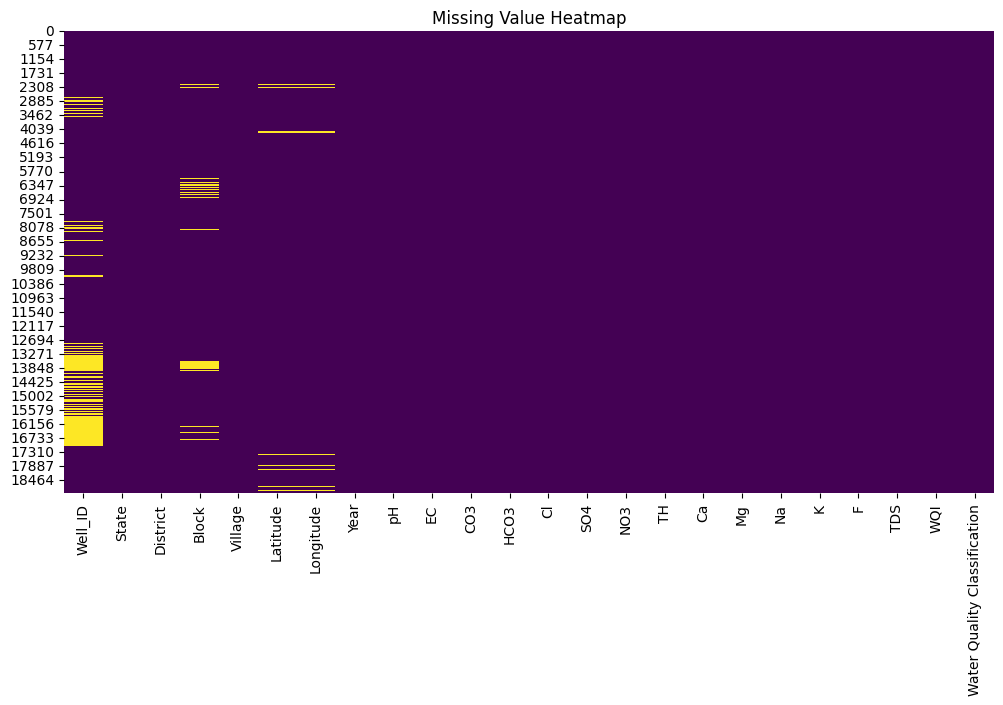

In [12]:
# Missing Value Heatmap

plt.figure(figsize=(12,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Value Heatmap")
plt.show()

## **2.6 Duplicate Record Analysis**

In [13]:
# Duplicate Records

duplicates = df.duplicated().sum()

print("Duplicate Records:", duplicates)

Duplicate Records: 7


## **2.7 Numerical and Categorical Feature Identification**

In [14]:
# Numerical Features

numerical_cols = df.select_dtypes(
    include=np.number
).columns.tolist()

print("Numerical Features:", len(numerical_cols))
print(numerical_cols)

Numerical Features: 18
['Latitude', 'Longitude', 'Year', 'pH', 'EC', 'CO3', 'HCO3', 'Cl', 'SO4', 'NO3', 'TH', 'Ca', 'Mg', 'Na', 'K', 'F', 'TDS', 'WQI']


In [15]:
# Categorical Features

categorical_cols = df.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Categorical Features:", len(categorical_cols))
print(categorical_cols)

Categorical Features: 6
['Well_ID', 'State', 'District', 'Block', 'Village', 'Water Quality Classification']


## **2.8 Target Variable Identification**

In [16]:
# Display Columns

df.columns.tolist()

['Well_ID',
 'State',
 'District',
 'Block',
 'Village',
 'Latitude',
 'Longitude',
 'Year',
 'pH',
 'EC',
 'CO3',
 'HCO3',
 'Cl',
 'SO4',
 'NO3',
 'TH',
 'Ca',
 'Mg',
 'Na',
 'K',
 'F',
 'TDS',
 'WQI',
 'Water Quality Classification']

In [17]:
# Target Variables Preview

df[["WQI", "Water Quality Classification"]].head()

,WQI,Water Quality Classification
0,4361.44080,Unsuitable for Drinking
1,85.80466,Good
2,280.04130,Very Poor yet Drinkable
3,195.11649,Poor
4,81.77860,Good


In [18]:
df["Water Quality Classification"].value_counts()

,count
Water Quality Classification,
Unsuitable for Drinking,6608
Poor,5317
Very Poor yet Drinkable,4709
Good,1632
Excellent,763


In [19]:
df["WQI"].describe()

,WQI
count,19029.000000
mean,305.291789
std,315.477116
min,9.043604
25%,146.642420
50%,232.078880
75%,359.718240
max,6850.888720


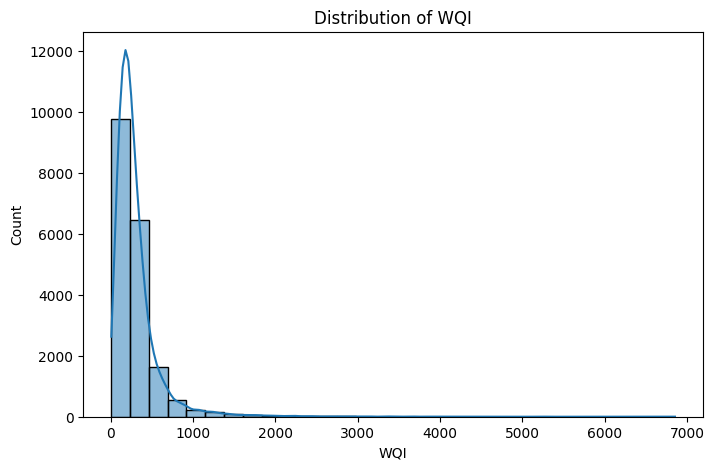

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(df["WQI"], bins=30, kde=True)
plt.title("Distribution of WQI")
plt.show()

In [21]:
df["Year"].value_counts().sort_index()

,count
Year,
2019,8650
2020,2136
2021,2390
2022,5853


In [22]:
(
    df.groupby("Water Quality Classification")["WQI"]
      .agg(["min","max","mean","count"])
      .sort_values("min")
)

,min,max,mean,count
Water Quality Classification,,,,
Excellent,9.043604,49.95470,35.536506,763
Good,50.026635,99.92520,76.797497,1632
Poor,100.019120,199.99532,150.994501,5317
Very Poor yet Drinkable,200.011080,299.99592,245.776747,4709
Unsuitable for Drinking,300.011380,6850.88872,559.435399,6608


## **Key Findings**
* Water chemistry variables contain no missing values.
* Missing values are concentrated in location-related features.
* The Water Quality Index exhibits strong positive skewness and contains extreme outliers.
* The classification target is moderately imbalanced.
* Water Quality Classification is directly derived from WQI, requiring careful handling to prevent data leakage.
* Well_ID behaves as a high-cardinality identifier with substantial missing values and is unlikely to contribute predictive value.

# **Section 3: Exploratory Data Analysis (EDA)**

## **3.1 Target Variable Analysis**

**Description**

Understanding the target variables is a critical first step before model development. For this project, we analyze both the regression target (WQI) and the classification target (Water Quality Classification) to understand their distributions, potential imbalance, and modeling challenges.

### 3.1.1 Water Quality Index (WQI) Distribution

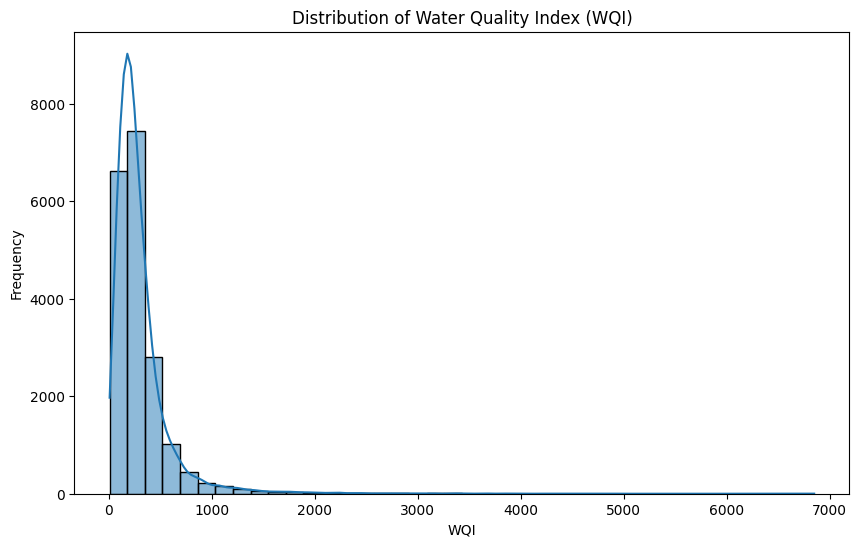

,WQI
count,19029.000000
mean,305.291789
std,315.477116
min,9.043604
25%,146.642420
50%,232.078880
75%,359.718240
max,6850.888720


In [23]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["WQI"],
    bins=40,
    kde=True
)

plt.title("Distribution of Water Quality Index (WQI)")
plt.xlabel("WQI")
plt.ylabel("Frequency")

plt.show()

df["WQI"].describe()

### 3.1.2 Boxplot of WQI

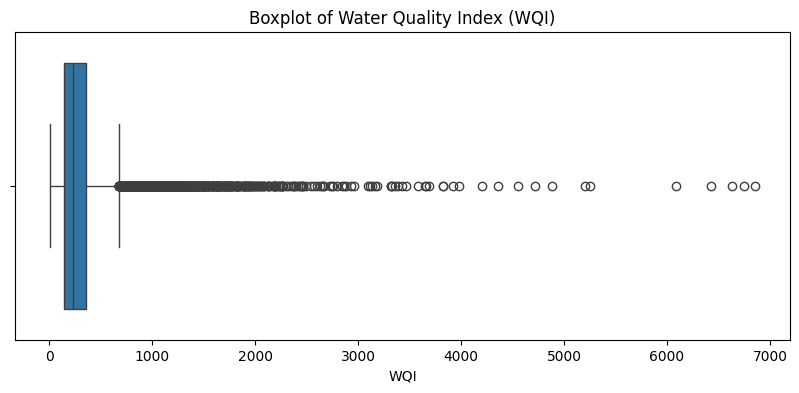

In [24]:
plt.figure(figsize=(10,4))

sns.boxplot(
    x=df["WQI"]
)

plt.title("Boxplot of Water Quality Index (WQI)")

plt.show()

### 3.1.3 Water Quality Classification Distribution

In [25]:
class_counts = df["Water Quality Classification"].value_counts()

class_counts

,count
Water Quality Classification,
Unsuitable for Drinking,6608
Poor,5317
Very Poor yet Drinkable,4709
Good,1632
Excellent,763


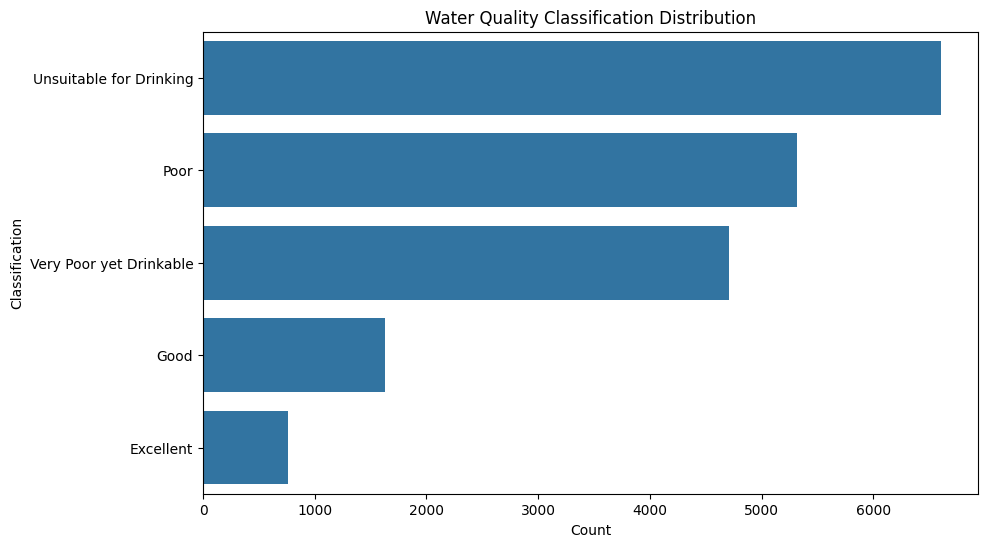

In [26]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    y="Water Quality Classification",
    order=df["Water Quality Classification"].value_counts().index
)

plt.title("Water Quality Classification Distribution")

plt.xlabel("Count")
plt.ylabel("Classification")

plt.show()

In [27]:
(
    df["Water Quality Classification"]
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
)

,proportion
Water Quality Classification,
Unsuitable for Drinking,34.73
Poor,27.94
Very Poor yet Drinkable,24.75
Good,8.58
Excellent,4.01


### 3.1.4 WQI Distribution Across Water Quality Classes

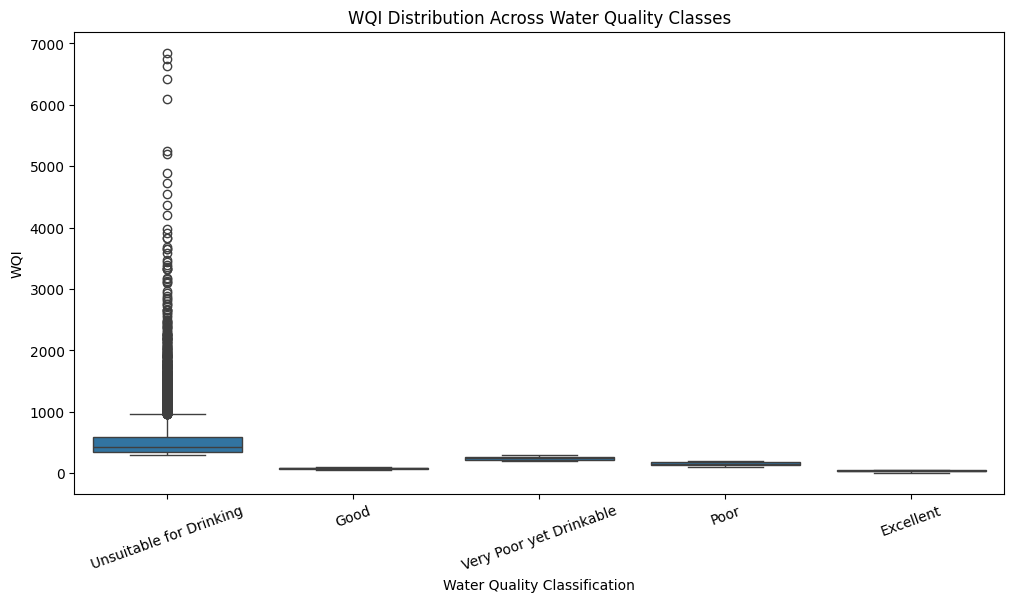

In [28]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="Water Quality Classification",
    y="WQI"
)

plt.xticks(rotation=20)

plt.title("WQI Distribution Across Water Quality Classes")

plt.show()

### 3.1.5 Average WQI by Water Quality Class

In [29]:
(
    df.groupby("Water Quality Classification")["WQI"]
      .mean()
      .sort_values()
)

,WQI
Water Quality Classification,
Excellent,35.536506
Good,76.797497
Poor,150.994501
Very Poor yet Drinkable,245.776747
Unsuitable for Drinking,559.435399


### Observations

1. The Water Quality Index exhibits a strongly right-skewed distribution with a long tail extending towards very high WQI values.

2. The mean WQI (305) is substantially higher than the median (232), further confirming positive skewness.

3. Several extreme outliers are present, with WQI values reaching approximately 6851.

4. The classification target is moderately imbalanced, with "Unsuitable for Drinking" being the largest class and "Excellent" being the smallest.

5. The class distribution suggests that evaluation metrics such as Precision, Recall, and F1-score should be prioritized over accuracy alone.

6. Water Quality Classification categories are clearly separated based on WQI ranges, confirming that WQI must be excluded from classification model inputs to prevent data leakage.

7. The observed skewness motivates experimentation with logarithmic transformation of WQI during regression modeling.

### Section Summary

Target variable analysis revealed two important modeling considerations.

First, the Water Quality Index is highly right-skewed and contains several extreme values. This may affect regression model performance and therefore a logarithmic transformation of WQI will be evaluated during model development.

Second, the classification target exhibits moderate class imbalance. Furthermore, classification labels are directly derived from WQI ranges, creating a potential data leakage issue. Consequently, WQI will be excluded from the classification feature set.

These findings establish the foundation for subsequent preprocessing and modeling decisions.

## **3.2: Water Chemistry Feature Analysis**

### 3.2.1 Summary Statistics of Water Chemistry Parameters

In [30]:
selected_features = [
    "pH",
    "EC",
    "TDS",
    "NO3",
    "TH",
    "F"
]

df[selected_features].describe().T

,count,mean,std,min,25%,50%,75%,max
pH,19029.0,7.713495,0.491413,2.80,7.450,7.72,8.00,10.92
EC,19029.0,1191.620744,1348.094278,2.29,524.000,860.00,1390.00,26520.00
TDS,19029.0,723.774239,755.575601,15.00,345.000,587.00,913.00,17768.00
NO3,19029.0,35.114294,55.488528,0.00,4.460,18.00,43.00,1534.90
TH,19029.0,327.843466,310.386082,3.00,165.000,260.00,400.00,8606.88
F,19029.0,0.595598,1.818577,-0.16,0.206,0.43,0.77,168.00


### 3.2.2 Distribution Analysis

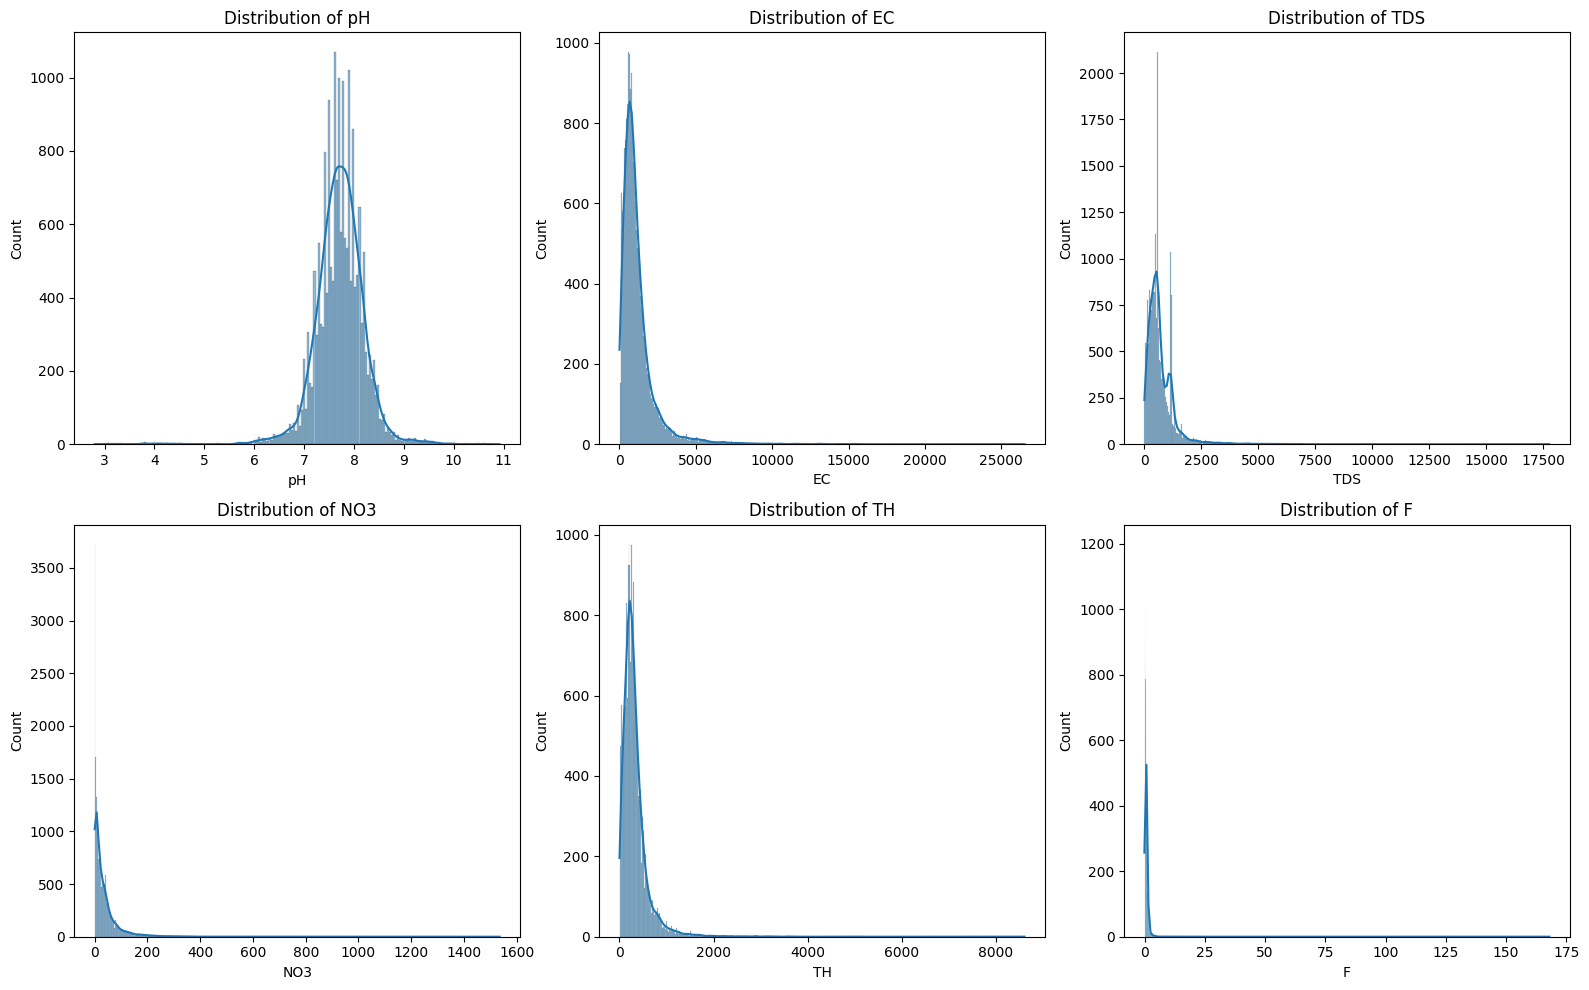

In [31]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(16,10)
)

axes = axes.flatten()

for i, col in enumerate(selected_features):

    sns.histplot(
        df[col],
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

### 3.2.3 Boxplot Analysis

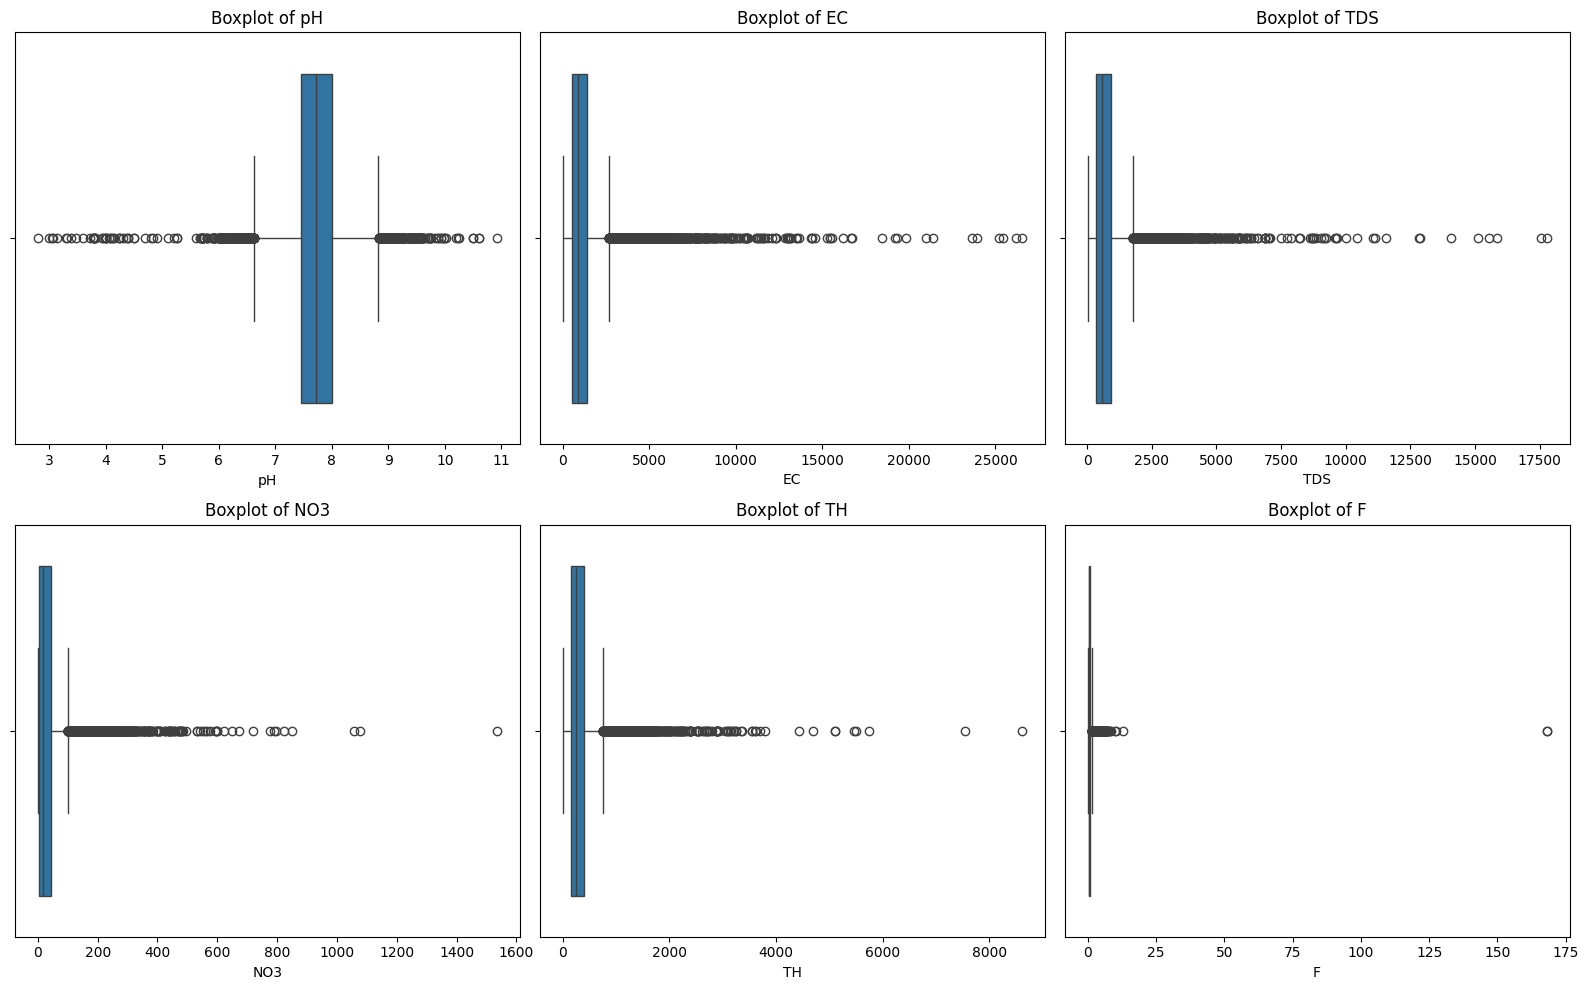

In [32]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(16,10)
)

axes = axes.flatten()

for i, col in enumerate(selected_features):

    sns.boxplot(
        x=df[col],
        ax=axes[i]
    )

    axes[i].set_title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

### 3.2.4 Coefficient of Variation Analysis

In [33]:
cv_df = pd.DataFrame({
    "Mean": df[selected_features].mean(),
    "Std Dev": df[selected_features].std()
})

cv_df["CV (%)"] = (
    cv_df["Std Dev"] /
    cv_df["Mean"]
) * 100

cv_df.sort_values(
    by="CV (%)",
    ascending=False
)

,Mean,Std Dev,CV (%)
F,0.595598,1.818577,305.336115
NO3,35.114294,55.488528,158.022623
EC,1191.620744,1348.094278,113.131152
TDS,723.774239,755.575601,104.393823
TH,327.843466,310.386082,94.675086
pH,7.713495,0.491413,6.370823


### 3.2.5 Relationship with WQI

In [34]:
corr_with_wqi = (
    df[selected_features + ["WQI"]]
    .corr()["WQI"]
    .sort_values(ascending=False)
)

corr_with_wqi

,WQI
WQI,1.000000
EC,0.981442
TDS,0.924358
TH,0.822221
NO3,0.380014
F,0.092698
pH,0.012890


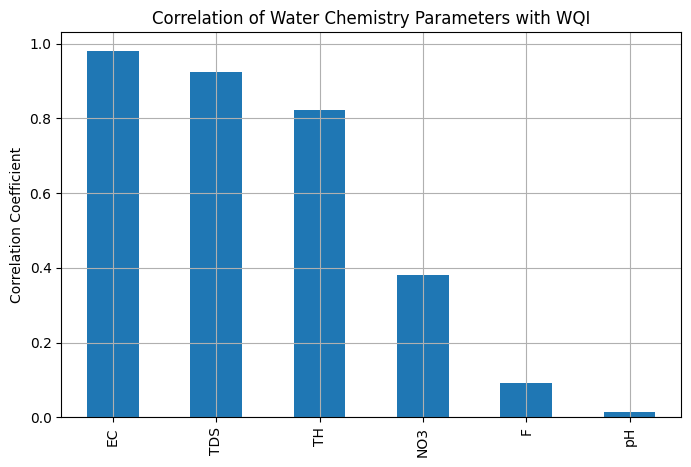

In [35]:
plt.figure(figsize=(8,5))

corr_with_wqi.drop("WQI").plot(
    kind="bar"
)

plt.title("Correlation of Water Chemistry Parameters with WQI")
plt.ylabel("Correlation Coefficient")
plt.grid(True)

plt.show()

### 3.2.6 Pairwise Relationship with WQI

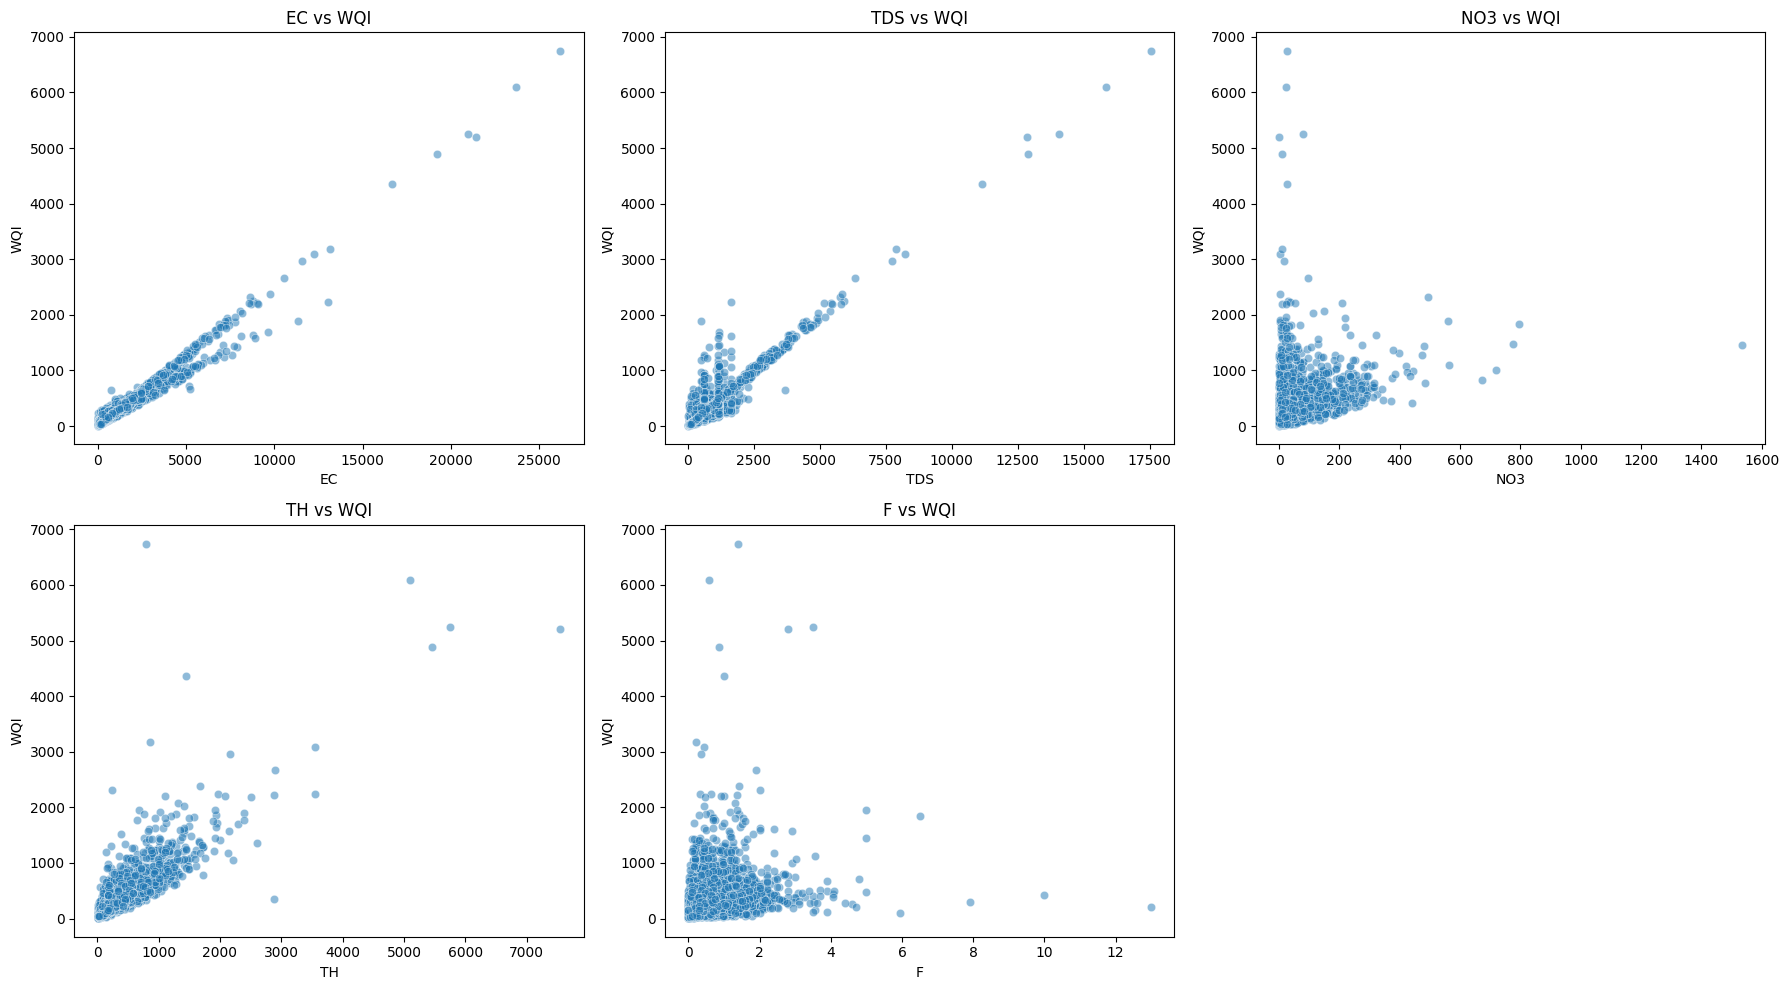

In [36]:
selected_features = [
    "EC",
    "TDS",
    "NO3",
    "TH",
    "F"
]

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(18,10)
)

axes = axes.flatten()

for i, col in enumerate(selected_features):

    sns.scatterplot(
        data=df.sample(
            min(5000, len(df)),
            random_state=42
        ),
        x=col,
        y="WQI",
        alpha=0.5,
        ax=axes[i]
    )

    axes[i].set_title(f"{col} vs WQI")

if len(selected_features) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

### Observations

1. The water chemistry parameters exhibit substantial variability across groundwater samples.

2. Several variables display positively skewed distributions, indicating the presence of unusually high concentration values in certain locations.

3. Electrical Conductivity (EC) and Total Dissolved Solids (TDS) are expected to show strong associations with overall water quality due to their direct relationship with dissolved mineral content.

4. Parameters such as Nitrate (NO3) and Fluoride (F) may contain extreme observations that could influence model training.

5. Boxplot analysis reveals the presence of numerous outliers; however, these values may represent genuine environmental conditions rather than measurement errors.

6. Significant differences in variability across features indicate that feature scaling will be essential prior to Deep Learning model development.

7. Initial correlation analysis provides an indication of which water chemistry parameters contribute most strongly to variations in Water Quality Index.

### Section Summary

The analysis of key water chemistry parameters revealed substantial variation across groundwater samples, reflecting the diverse environmental and geological conditions represented in the dataset.

Several variables exhibit skewed distributions and contain extreme observations, suggesting that groundwater quality varies considerably across locations. These outliers appear to be naturally occurring measurements and will be retained for further analysis unless strong evidence of data quality issues is identified.

The differing scales and distributions of the chemical parameters reinforce the need for feature scaling prior to model training. Preliminary relationships between water chemistry indicators and WQI also suggest that multiple parameters contribute to water quality assessment, supporting the use of multivariate predictive models.

The next section investigates correlations among all variables to better understand feature interactions and identify the strongest predictors of water quality.

## **3.3: Correlation Analysis**

### 3.3.1 Correlation Matrix

In [37]:
# Numerical Features

numerical_cols = df.select_dtypes(
    include=np.number
).columns

corr_matrix = df[numerical_cols].corr()

corr_matrix.head()

,Latitude,Longitude,Year,pH,EC,CO3,HCO3,Cl,SO4,NO3,TH,Ca,Mg,Na,K,F,TDS,WQI
Latitude,1.000000,-0.000061,-0.005499,-0.001402,-0.004132,-0.001685,-0.003017,-0.002795,-0.002449,-0.002598,-0.002621,-0.001180,-0.003218,-0.003324,-0.002403,-0.001791,-0.004297,-0.004263
Longitude,-0.000061,1.000000,0.003912,0.004977,-0.003074,-0.001588,-0.003123,-0.002260,-0.001233,-0.003169,-0.003004,-0.002950,-0.002419,-0.001941,-0.001953,0.000481,-0.002986,-0.003164
Year,-0.005499,0.003912,1.000000,-0.029812,-0.018202,-0.055519,0.044891,-0.024023,-0.016490,-0.011838,-0.020842,-0.027818,-0.016176,-0.015880,0.026771,0.003126,-0.037667,-0.023797
pH,-0.001402,0.004977,-0.029812,1.000000,0.016971,0.393021,0.085370,-0.017362,0.042356,-0.069210,-0.048091,-0.103828,0.007583,0.064276,0.075192,0.071436,-0.000944,0.012890
EC,-0.004132,-0.003074,-0.018202,0.016971,1.000000,0.097952,0.499102,0.944062,0.715356,0.380176,0.839631,0.636692,0.793974,0.905600,0.284571,0.087167,0.837206,0.981442


### 3.3.2 Correlation Heatmap

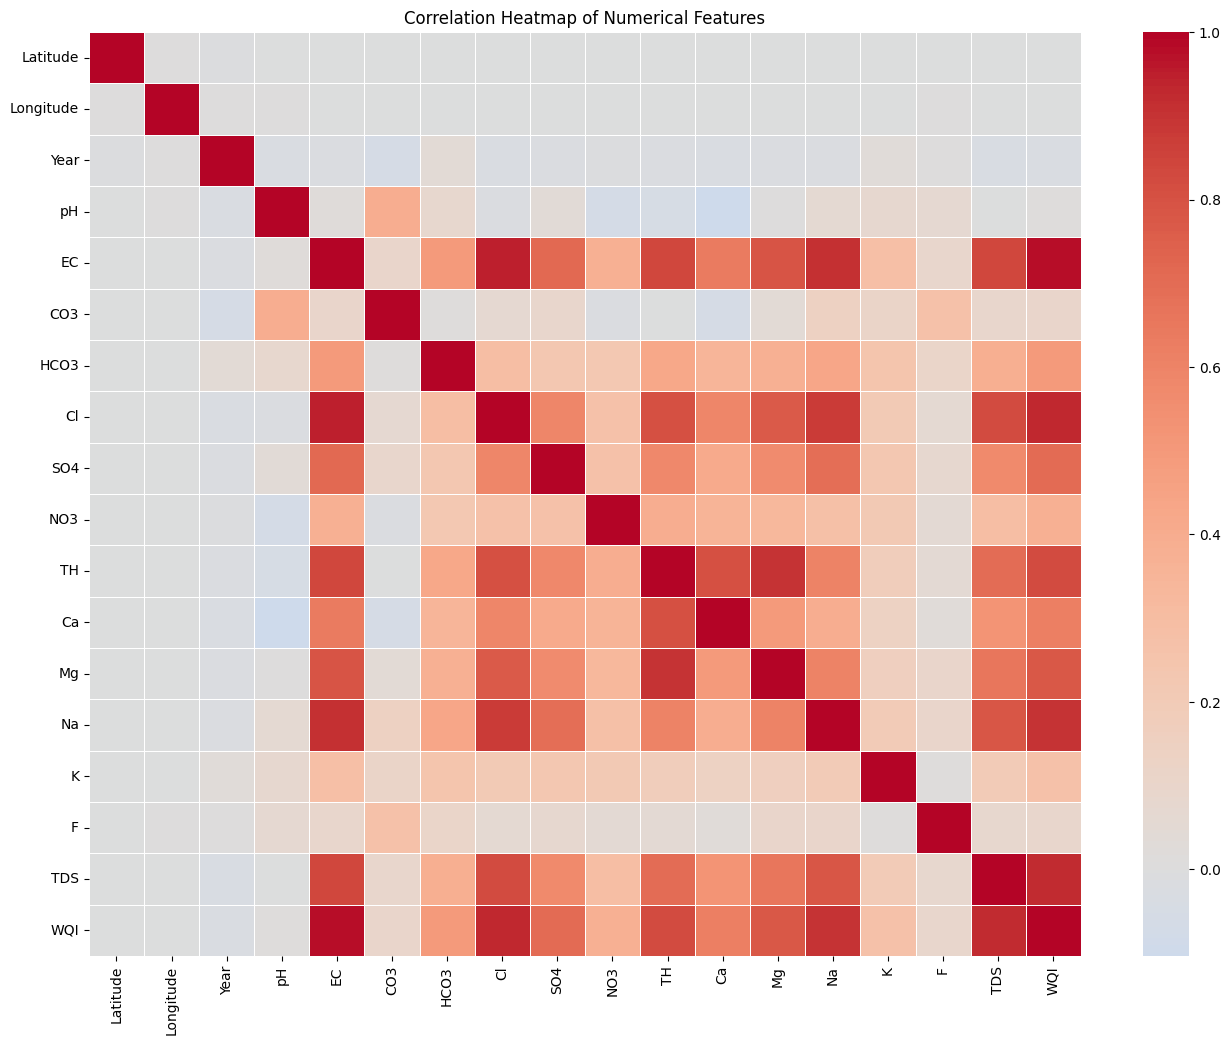

In [38]:
plt.figure(figsize=(16,12))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features")

plt.show()

### 3.3.3 Correlation with WQI

In [39]:
corr_with_wqi = (
    corr_matrix["WQI"]
    .sort_values(ascending=False)
)

corr_with_wqi

,WQI
WQI,1.000000
EC,0.981442
Cl,0.932176
TDS,0.924358
Na,0.903628
TH,0.822221
Mg,0.776863
SO4,0.705896
Ca,0.624723
HCO3,0.493898


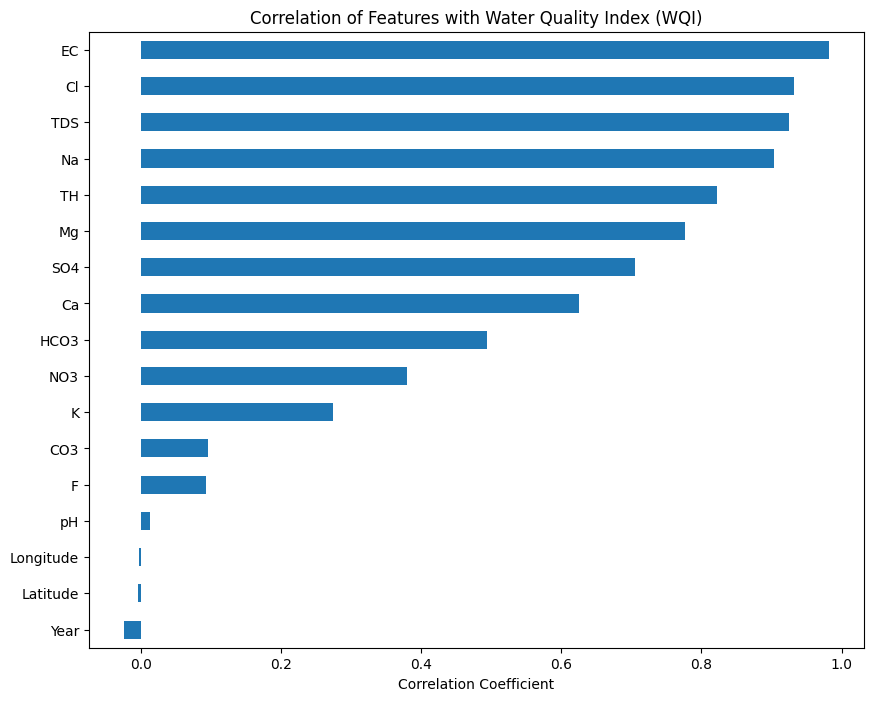

In [40]:
plt.figure(figsize=(10,8))

corr_with_wqi.drop("WQI").sort_values().plot(
    kind="barh"
)

plt.title("Correlation of Features with Water Quality Index (WQI)")
plt.xlabel("Correlation Coefficient")

plt.show()

### 3.3.4 Top Positive Correlations with WQI

In [41]:
top_positive = (
    corr_with_wqi
    .drop("WQI")
    .head(10)
)

top_positive

,WQI
EC,0.981442
Cl,0.932176
TDS,0.924358
Na,0.903628
TH,0.822221
Mg,0.776863
SO4,0.705896
Ca,0.624723
HCO3,0.493898
NO3,0.380014


### 3.3.5 Top Negative Correlations with WQI

In [42]:
top_negative = (
    corr_with_wqi
    .tail(10)
)

top_negative

,WQI
Ca,0.624723
HCO3,0.493898
NO3,0.380014
K,0.274142
CO3,0.096421
F,0.092698
pH,0.012890
Longitude,-0.003164
Latitude,-0.004263
Year,-0.023797


### 3.3.6 Strong Feature Relationships

In [43]:
corr_upper = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)

high_corr_pairs = (
    corr_upper.stack()
    .sort_values(
        key=abs,
        ascending=False
    )
)

high_corr_pairs.head(20)

EC   WQI    0.981442
     Cl     0.944062
Cl   WQI    0.932176
TDS  WQI    0.924358
EC   Na     0.905600
Na   WQI    0.903628
TH   Mg     0.903572
Cl   Na     0.875137
EC   TH     0.839631
     TDS    0.837206
TH   WQI    0.822221
Cl   TDS    0.821122
TH   Ca     0.810034
Cl   TH     0.802535
EC   Mg     0.793974
Na   TDS    0.786723
Mg   WQI    0.776863
Cl   Mg     0.770433
EC   SO4    0.715356
SO4  WQI    0.705896
dtype: float64

### 3.3.7 Scatterplots of Strongest Predictors

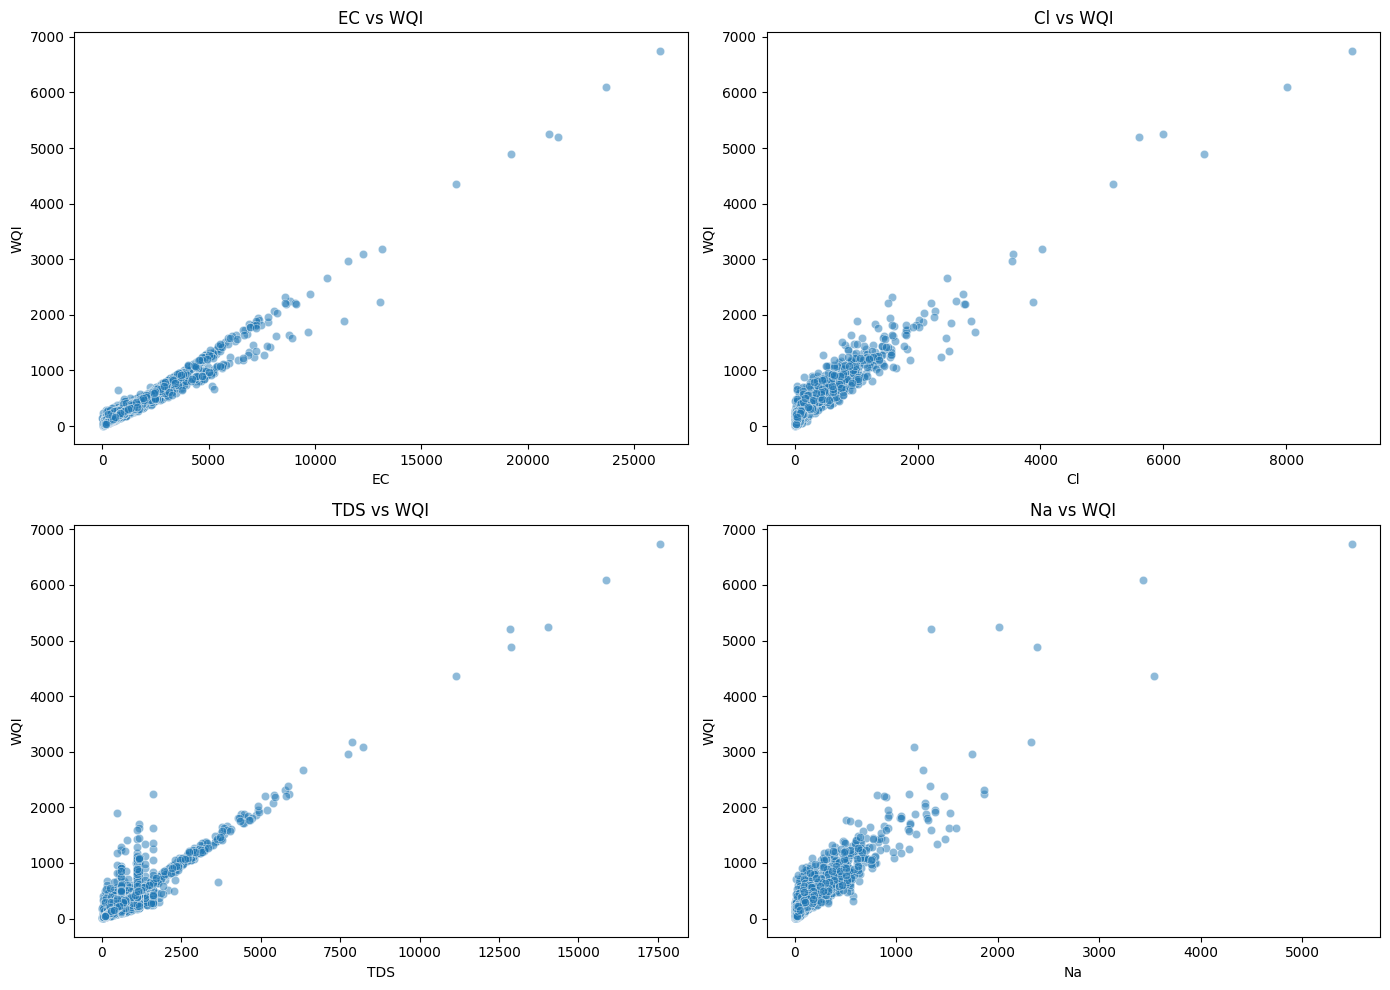

In [44]:
top_features = (
    corr_with_wqi
    .drop("WQI")
    .abs()
    .sort_values(ascending=False)
    .head(4)
    .index
)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14,10)
)

axes = axes.flatten()

for i, feature in enumerate(top_features):

    sns.scatterplot(
        data=df.sample(
            min(5000, len(df)),
            random_state=42
        ),
        x=feature,
        y="WQI",
        alpha=0.5,
        ax=axes[i]
    )

    axes[i].set_title(f"{feature} vs WQI")

plt.tight_layout()

plt.show()

### Observations

1. Electrical Conductivity (EC) exhibits the strongest positive correlation with Water Quality Index (WQI) with a correlation coefficient of 0.981, indicating an almost perfect linear relationship.

2. Chlorides (Cl) and Total Dissolved Solids (TDS) also demonstrate extremely strong positive correlations with WQI, with coefficients of 0.932 and 0.924 respectively.

3. Sodium (Na), Total Hardness (TH), and Magnesium (Mg) show strong associations with WQI, suggesting that dissolved salts and hardness-related parameters play a major role in determining overall water quality.

4. Sulfates (SO4) and Calcium (Ca) exhibit moderate to strong positive relationships with WQI, further reinforcing the importance of mineral content in groundwater quality assessment.

5. Nitrate (NO3) displays a moderate positive correlation (0.380), indicating a measurable but less dominant influence on WQI compared to conductivity and dissolved solids.

6. Potassium (K), Carbonates (CO3), Fluoride (F), and pH exhibit relatively weak correlations with WQI, suggesting limited direct linear influence on the overall water quality index.

7. Geographical coordinates (Latitude and Longitude) and Year show negligible correlations with WQI, indicating that water quality variation is more strongly driven by chemical characteristics than by temporal or spatial location alone.

8. The exceptionally high correlations observed for EC, Cl, TDS, and Na suggest that dissolved ionic content is the primary factor influencing groundwater quality in this dataset.

### Section Summary

Correlation analysis revealed that water quality is predominantly influenced by parameters associated with dissolved mineral and ionic content.

Electrical Conductivity (EC), Chlorides (Cl), Total Dissolved Solids (TDS), and Sodium (Na) emerged as the strongest predictors of Water Quality Index, all exhibiting correlation coefficients above 0.90. This indicates that increases in dissolved salts and conductivity are strongly associated with deteriorating water quality.

In contrast, pH, Fluoride, Carbonates, and geographical variables showed weak linear relationships with WQI. While these variables may still contribute useful nonlinear information, their direct influence appears substantially lower.

The analysis confirms that groundwater quality in this dataset is largely governed by dissolved solids, salinity, and hardness-related parameters. These findings provide valuable domain insight and support the use of multivariate Deep Learning models capable of capturing interactions among multiple water chemistry indicators.

The next section explores geographical patterns in water quality across different states and regions of India.

## **3.4: Geographic Analysis**

### 3.4.1 Number of Samples by State

In [45]:
state_counts = (
    df["State"]
    .value_counts()
    .sort_values(ascending=False)
)

state_counts.head(15)

,count
State,
Madhya Pradesh,3628
Maharashtra,2366
Tamil Nadu,2115
Karnataka,1822
Gujarat,1657
Bihar,1349
West Bengal,1301
Andhra Pradesh,1265
Uttar Pradesh,1260


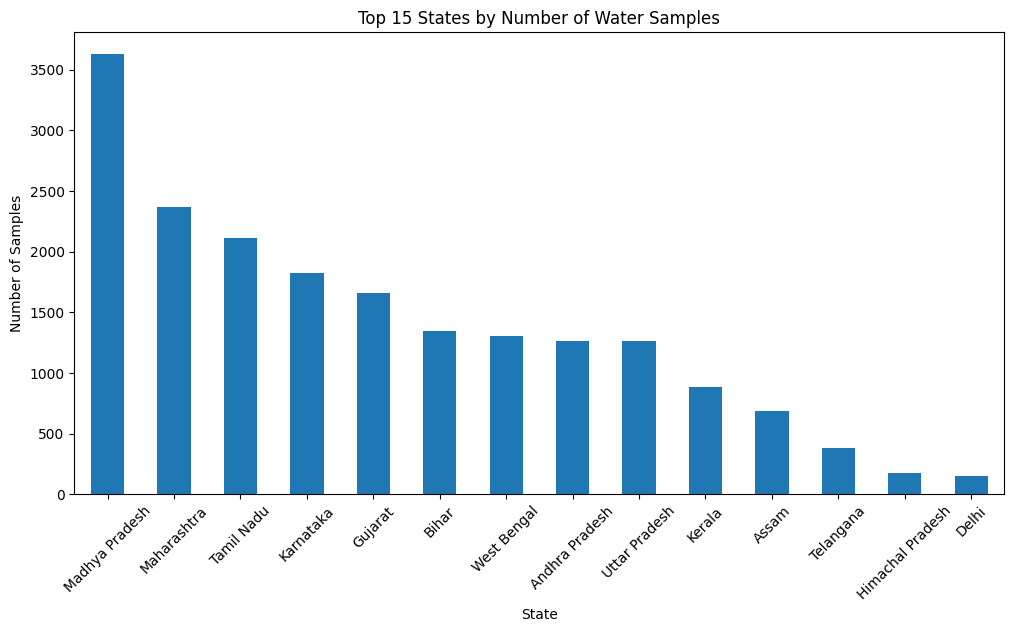

In [46]:
plt.figure(figsize=(12,6))

state_counts.head(15).plot(
    kind="bar"
)

plt.title("Top 15 States by Number of Water Samples")
plt.ylabel("Number of Samples")
plt.xlabel("State")

plt.xticks(rotation=45)

plt.show()

### 3.4.2 Average WQI by State

In [47]:
state_wqi = (
    df.groupby("State")["WQI"]
      .mean()
      .sort_values(ascending=False)
)

state_wqi.head(15)

,WQI
State,
Delhi,712.936564
Gujarat,538.248039
Andhra Pradesh,485.852596
Tamil Nadu,473.789152
Telangana,393.358935
Karnataka,269.645710
Maharashtra,263.759956
Madhya Pradesh,258.774626
Uttar Pradesh,229.463892


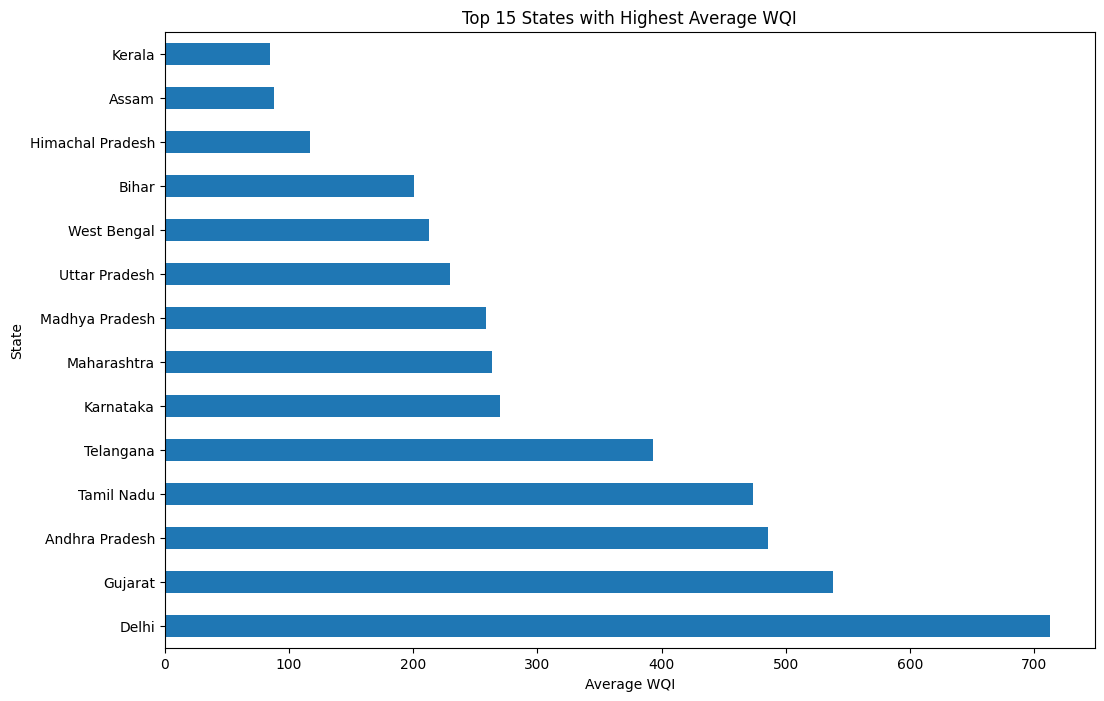

In [48]:
plt.figure(figsize=(12,8))

state_wqi.head(15).plot(
    kind="barh"
)

plt.title("Top 15 States with Highest Average WQI")
plt.xlabel("Average WQI")

plt.show()

### 3.4.3 States with Best Water Quality

Lower WQI generally indicates better water quality.

In [49]:
best_states = (
    df.groupby("State")["WQI"]
      .mean()
      .sort_values()
)

best_states.head(10)

,WQI
State,
Kerala,84.761474
Assam,88.108505
Himachal Pradesh,117.114217
Bihar,200.773679
West Bengal,212.735474
Uttar Pradesh,229.463892
Madhya Pradesh,258.774626
Maharashtra,263.759956
Karnataka,269.645710


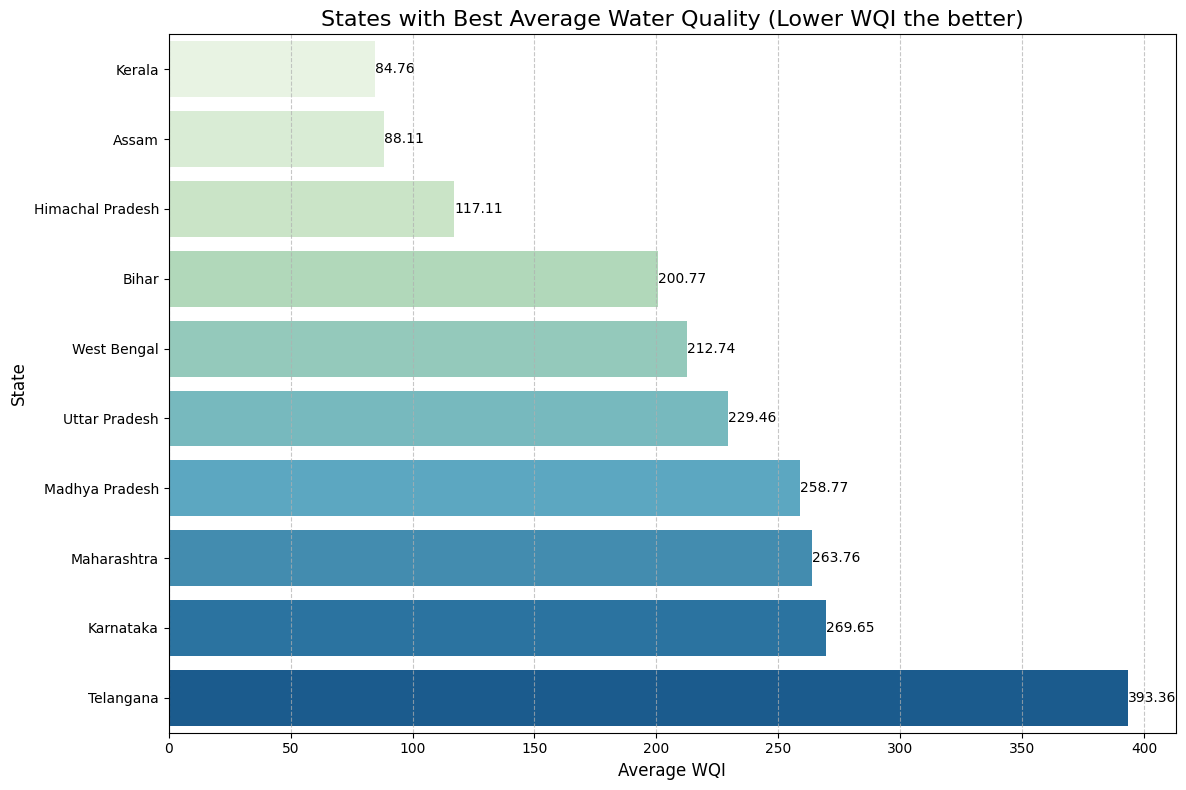

In [50]:
plt.figure(figsize=(12, 8))

# Create a bar plot using seaborn
sns.barplot(
    x=best_states.head(10).values,
    y=best_states.head(10).index,
    hue=best_states.head(10).index,
    palette="GnBu", # Green-Blue palette for good quality
    legend=False
)

plt.title("States with Best Average Water Quality (Lower WQI the better)", fontsize=16)
plt.xlabel("Average WQI", fontsize=12)
plt.ylabel("State", fontsize=12)

# Add data labels to the bars
for index, value in enumerate(best_states.head(10).values):
    plt.text(value, index, f'{value:.2f}', va='center')

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 3.4.4 States with Poor Water Quality

In [51]:
worst_states = (
    df.groupby("State")["WQI"]
      .mean()
      .sort_values(ascending=False)
)

worst_states.head(10)

,WQI
State,
Delhi,712.936564
Gujarat,538.248039
Andhra Pradesh,485.852596
Tamil Nadu,473.789152
Telangana,393.358935
Karnataka,269.645710
Maharashtra,263.759956
Madhya Pradesh,258.774626
Uttar Pradesh,229.463892


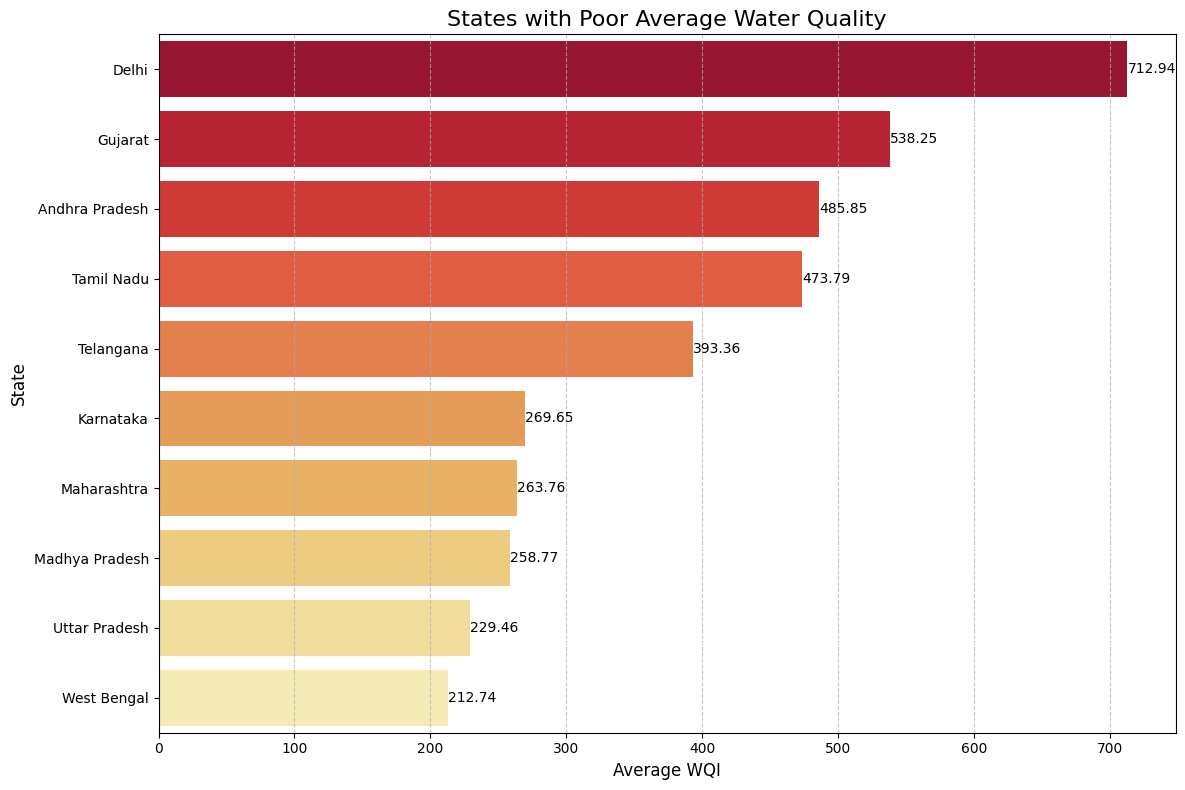

In [52]:
plt.figure(figsize=(12, 8))

# Create a bar plot using seaborn
sns.barplot(
    x=worst_states.head(10).values,
    y=worst_states.head(10).index,
    hue=worst_states.head(10).index,
    palette="YlOrRd_r", # Reverse the YlOrRd palette to show higher WQI in red
    legend=False
)

plt.title("States with Poor Average Water Quality", fontsize=16)
plt.xlabel("Average WQI", fontsize=12)
plt.ylabel("State", fontsize=12)

# Add data labels to the bars
for index, value in enumerate(worst_states.head(10).values):
    plt.text(value, index, f'{value:.2f}', va='center')

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 3.4.5 Water Quality Classification by State

Investigate whether certain states have a higher proportion of poor-quality groundwater.

In [53]:
state_class = pd.crosstab(
    df["State"],
    df["Water Quality Classification"],
    normalize="index"
) * 100

state_class.head()

Water Quality Classification,Excellent,Good,Poor,Unsuitable for Drinking,Very Poor yet Drinkable
State,,,,,
Andhra Pradesh,0.790514,1.185771,5.849802,73.992095,18.181818
Assam,24.087591,46.423358,24.817518,0.583942,4.087591
Bihar,0.518903,9.562639,50.407709,13.862120,25.648629
Delhi,0.671141,3.355705,11.409396,75.167785,9.395973
Gujarat,0.000000,1.207001,20.337960,56.608328,21.846711


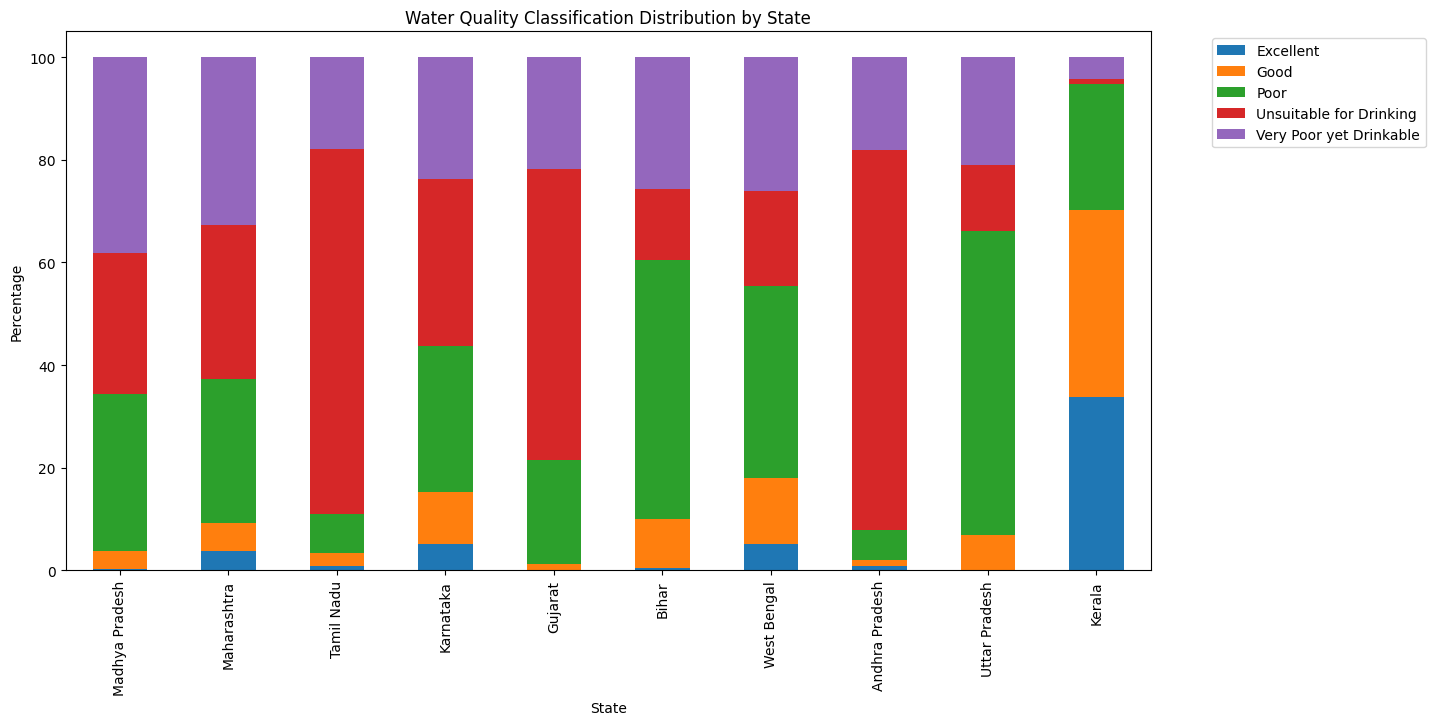

In [54]:
top_states = (
    df["State"]
    .value_counts()
    .head(10)
    .index
)

state_class.loc[top_states].plot(
    kind="bar",
    stacked=True,
    figsize=(14,7)
)

plt.title(
    "Water Quality Classification Distribution by State"
)

plt.ylabel("Percentage")

plt.legend(
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

plt.show()

### Observations

1. Groundwater quality exhibits substantial geographical variation across Indian states, indicating that regional factors influence water quality characteristics.

2. Kerala records the lowest average WQI (84.76), followed by Assam (88.11) and Himachal Pradesh (117.11), suggesting comparatively better groundwater quality in these regions.

3. Delhi exhibits the highest average WQI (712.94), followed by Gujarat (538.25), Andhra Pradesh (485.85), and Tamil Nadu (473.79), indicating comparatively poorer groundwater quality.

4. The difference between the best-performing state (Kerala) and the worst-performing state (Delhi) exceeds 600 WQI points, highlighting considerable regional disparities in groundwater quality.

5. Several southern and western states display relatively high WQI values, suggesting elevated concentrations of dissolved solids, salinity, hardness, or other water quality contaminants.

6. The observed state-level differences indicate that geographical variables contain meaningful contextual information even though Latitude and Longitude individually showed weak linear correlations with WQI.

7. The results suggest that water quality is influenced not only by local chemistry measurements but also by broader regional environmental, geological, and anthropogenic factors.

### Section Summary

Geographic analysis revealed significant regional variation in groundwater quality across India. States such as Kerala, Assam, and Himachal Pradesh exhibited comparatively low average WQI values, indicating better groundwater quality, whereas Delhi, Gujarat, Andhra Pradesh, and Tamil Nadu showed substantially higher WQI values.

The large differences observed between states suggest that regional factors play an important role in determining groundwater quality. Although geographical coordinates alone exhibit weak correlations with WQI, state-level information appears to provide valuable contextual information that may enhance predictive performance.

These findings justify retaining geographical features in the modeling pipeline. The next section investigates temporal trends in groundwater quality across the study period from 2019 to 2022.

## **3.5: Temporal Analysis (2019–2022)**

### 3.5.1 Number of Samples Collected per Year

In [55]:
year_counts = (
    df["Year"]
    .value_counts()
    .sort_index()
)

year_counts

,count
Year,
2019,8650
2020,2136
2021,2390
2022,5853


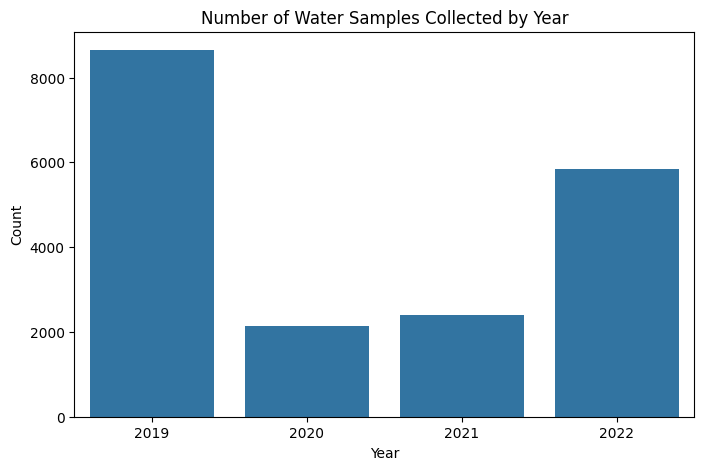

In [56]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Year",
    order=sorted(df["Year"].unique())
)

plt.title("Number of Water Samples Collected by Year")
plt.xlabel("Year")
plt.ylabel("Count")

plt.show()

### 3.5.2 Average WQI by Year

In [57]:
yearly_wqi = (
    df.groupby("Year")["WQI"]
      .agg(["mean","median","std","count"])
)

yearly_wqi

,mean,median,std,count
Year,,,,
2019,308.024338,217.429983,353.676564,8650
2020,333.808290,254.173800,328.174020,2136
2021,303.234763,225.689580,351.996812,2390
2022,291.686543,245.919380,219.933924,5853


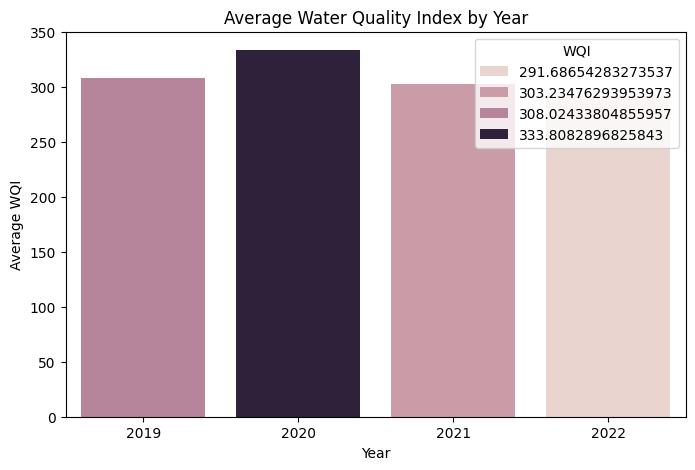

In [58]:
avg_wqi_year = (
    df.groupby("Year")["WQI"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=avg_wqi_year,
    x="Year",
    y="WQI",
    hue="WQI"
)

plt.title("Average Water Quality Index by Year")
plt.ylabel("Average WQI")

plt.show()

### 3.5.3 WQI Distribution Across Years

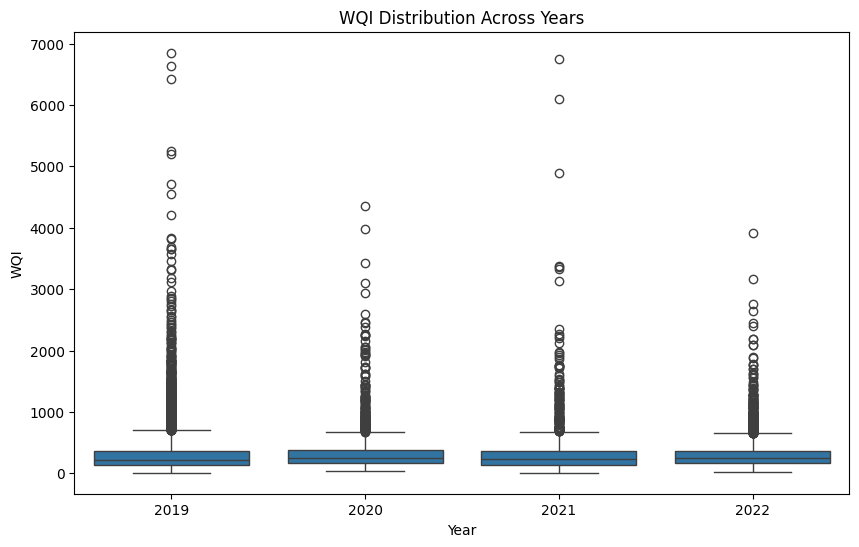

In [59]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Year",
    y="WQI"
)

plt.title("WQI Distribution Across Years")

plt.show()

### 3.5.4 Water Quality Classification by Year

In [60]:
year_class_dist = pd.crosstab(
    df["Year"],
    df["Water Quality Classification"]
)

year_class_dist

Water Quality Classification,Excellent,Good,Poor,Unsuitable for Drinking,Very Poor yet Drinkable
Year,,,,,
2019,512,849,2535,2875,1879
2020,12,138,572,809,605
2021,131,238,649,800,572
2022,108,407,1561,2124,1653


In [61]:
year_class_pct = pd.crosstab(
    df["Year"],
    df["Water Quality Classification"],
    normalize="index"
) * 100

year_class_pct.round(2)

Water Quality Classification,Excellent,Good,Poor,Unsuitable for Drinking,Very Poor yet Drinkable
Year,,,,,
2019,5.92,9.82,29.31,33.24,21.72
2020,0.56,6.46,26.78,37.87,28.32
2021,5.48,9.96,27.15,33.47,23.93
2022,1.85,6.95,26.67,36.29,28.24


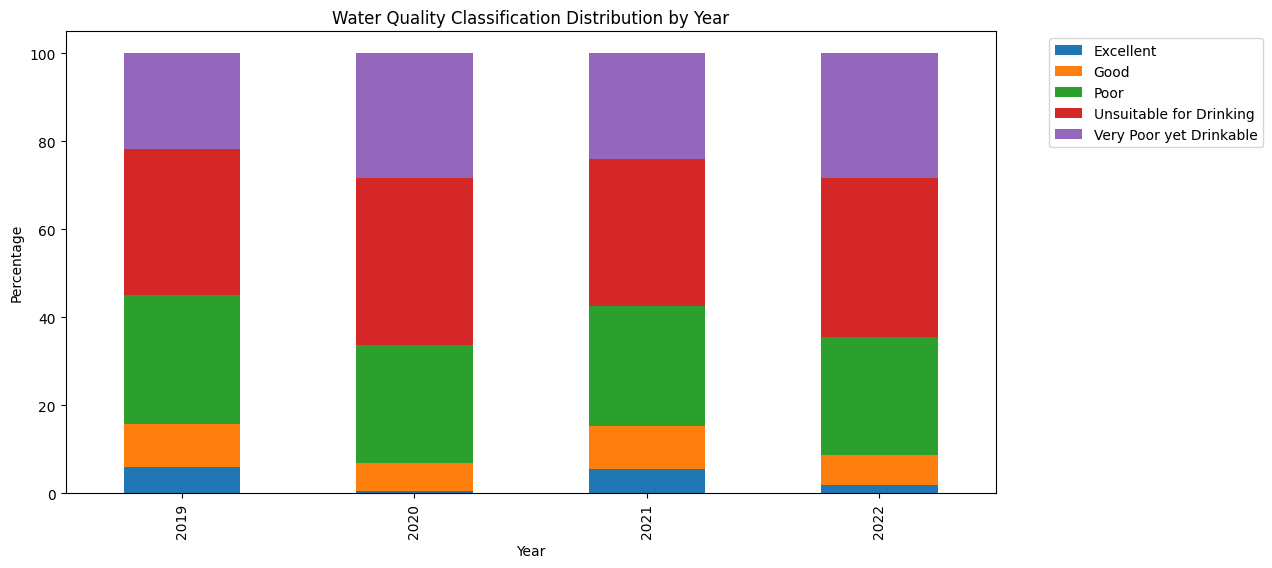

In [62]:
year_class_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6)
)

plt.title(
    "Water Quality Classification Distribution by Year"
)

plt.ylabel("Percentage")

plt.legend(
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

plt.show()

### 3.5.5 Trend of Median WQI

In [63]:
median_wqi = (
    df.groupby("Year")["WQI"]
      .median()
      .reset_index()
)

median_wqi

,Year,WQI
0,2019,217.429983
1,2020,254.173800
2,2021,225.689580
3,2022,245.919380


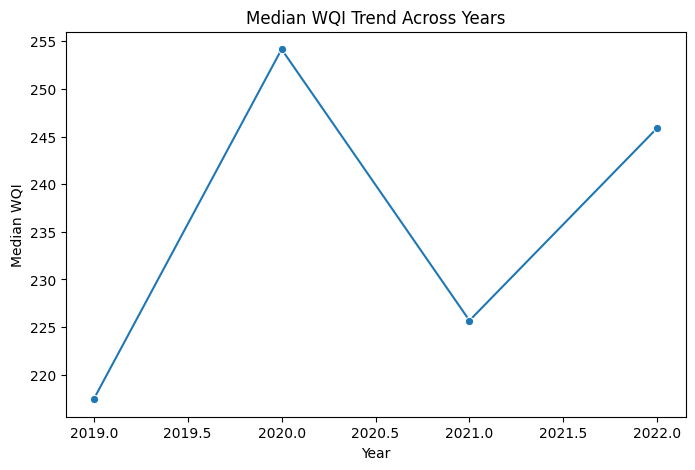

In [64]:
plt.figure(figsize=(8,5))

sns.lineplot(
    data=median_wqi,
    x="Year",
    y="WQI",
    marker="o"
)

plt.title("Median WQI Trend Across Years")
plt.ylabel("Median WQI")

plt.show()

### Observations

1. The dataset exhibits an uneven temporal distribution, with 2019 contributing the largest number of observations, followed by 2022. The years 2020 and 2021 contain substantially fewer samples.

2. Average Water Quality Index (WQI) remained relatively stable throughout the study period, ranging between approximately 292 and 334.

3. The highest average WQI was observed in 2020 (333.81), indicating comparatively poorer groundwater quality during that year.

4. The lowest average WQI was observed in 2022 (291.69), suggesting a slight improvement in overall groundwater quality compared to previous years.

5. The proportion of "Unsuitable for Drinking" samples remained consistently high across all years, accounting for approximately one-third of all observations.

6. The percentage of "Excellent" quality water samples remained very low throughout the study period and declined substantially in 2020 and 2022, falling below 2% in those years.

7. The combined proportion of "Very Poor yet Drinkable" and "Unsuitable for Drinking" categories exceeded 60% in every year, indicating that a significant share of groundwater samples exhibited quality concerns.

8. Although temporal variations are present, the overall class distribution remains relatively consistent across years, suggesting that groundwater quality patterns are primarily driven by chemical characteristics rather than temporal changes alone.

### Section Summary

Temporal analysis revealed moderate year-to-year variations in groundwater quality between 2019 and 2022. While average WQI values fluctuated over time, the overall distribution of water quality categories remained relatively consistent.

The consistently high proportion of samples classified as "Unsuitable for Drinking" and "Very Poor yet Drinkable" highlights persistent groundwater quality concerns throughout the study period. In contrast, the percentage of "Excellent" quality samples remained low across all years.

These findings suggest that temporal information may provide useful contextual signals for predictive modeling, although water chemistry variables are likely to remain the dominant drivers of model performance. Consequently, the Year feature will be retained during model development.

The next section focuses on outlier analysis to determine whether extreme observations represent genuine environmental conditions or require special treatment during preprocessing.

## **3.6: Outlier Analysis**

In [65]:
selected_features = [
    "pH",
    "EC",
    "TDS",
    "NO3",
    "TH",
    "F",
    "WQI"
]

### 3.6.1 Boxplots of Key Water Quality Parameters

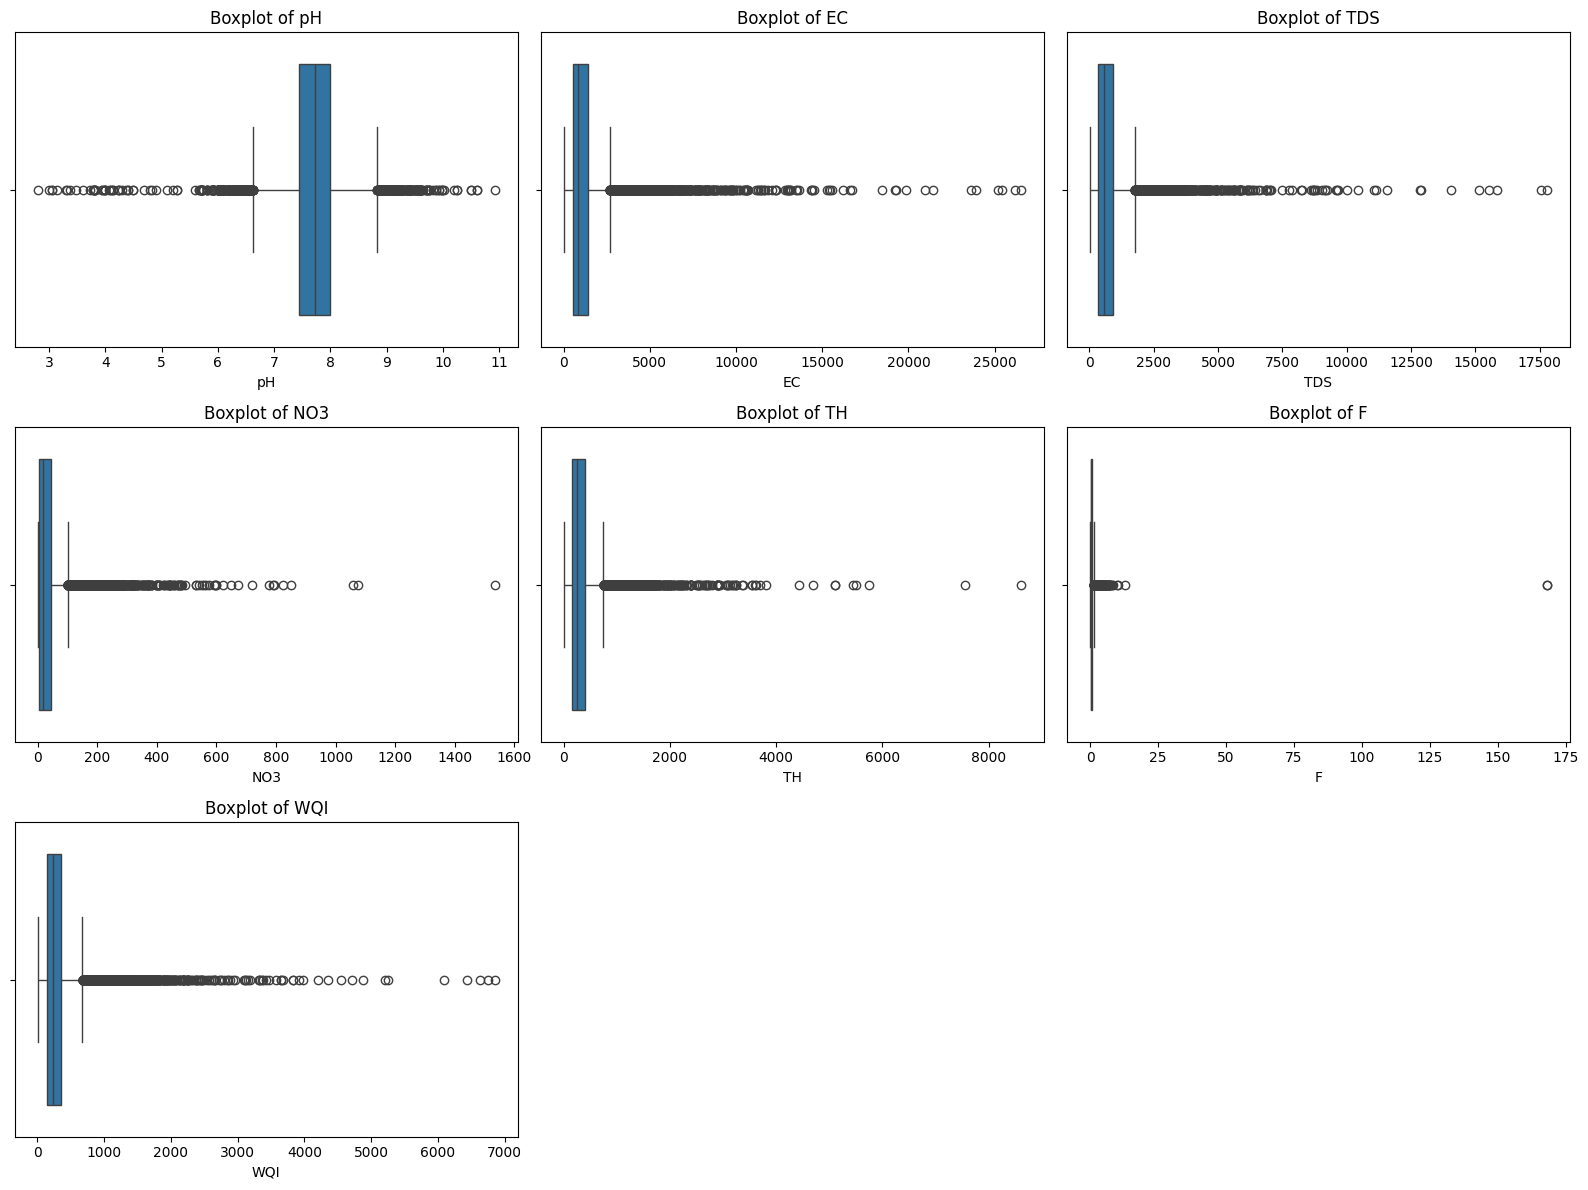

In [66]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=(16,12)
)

axes = axes.flatten()

for i, col in enumerate(selected_features):

    sns.boxplot(
        x=df[col],
        ax=axes[i]
    )

    axes[i].set_title(f"Boxplot of {col}")

# Remove unused axes
for j in range(len(selected_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### 3.6.2 IQR-Based Outlier Detection

In [67]:
def count_outliers_iqr(series):

    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = (
        (series < lower) |
        (series > upper)
    )

    return outliers.sum()

selected_features = [
    "pH",
    "EC",
    "TDS",
    "NO3",
    "TH",
    "F",
    "WQI"
]

outlier_counts = pd.DataFrame({
    "Outlier Count": [
        count_outliers_iqr(df[col])
        for col in selected_features
    ]
},
index=selected_features)

outlier_counts["Outlier Percentage"] = (
    outlier_counts["Outlier Count"] /
    len(df)
) * 100

outlier_counts.sort_values(
    by="Outlier Percentage",
    ascending=False
)

,Outlier Count,Outlier Percentage
NO3,1467,7.709286
EC,1364,7.168007
WQI,1216,6.390246
TH,1131,5.943560
TDS,830,4.361764
F,814,4.277681
pH,579,3.042724


### 3.6.3 Outlier Percentage Visualization

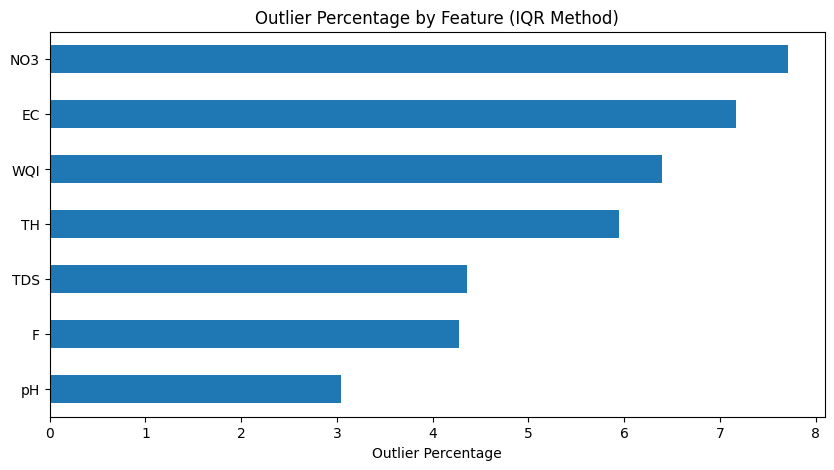

In [68]:
plt.figure(figsize=(10,5))

outlier_counts.sort_values(
    by="Outlier Percentage"
)["Outlier Percentage"].plot(
    kind="barh"
)

plt.xlabel("Outlier Percentage")
plt.title(
    "Outlier Percentage by Feature (IQR Method)"
)

plt.show()

### 3.6.4 Distribution Before Log Transformation

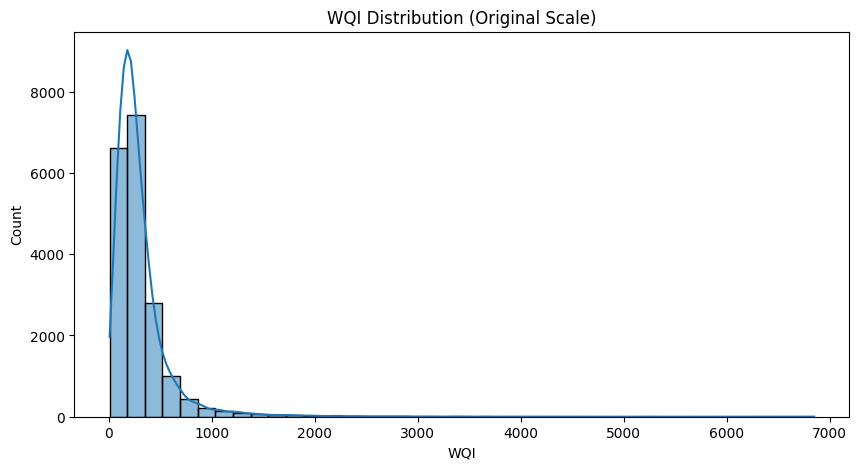

In [69]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["WQI"],
    bins=40,
    kde=True
)

plt.title(
    "WQI Distribution (Original Scale)"
)

plt.show()

### 3.6.5 Distribution After Log Transformation

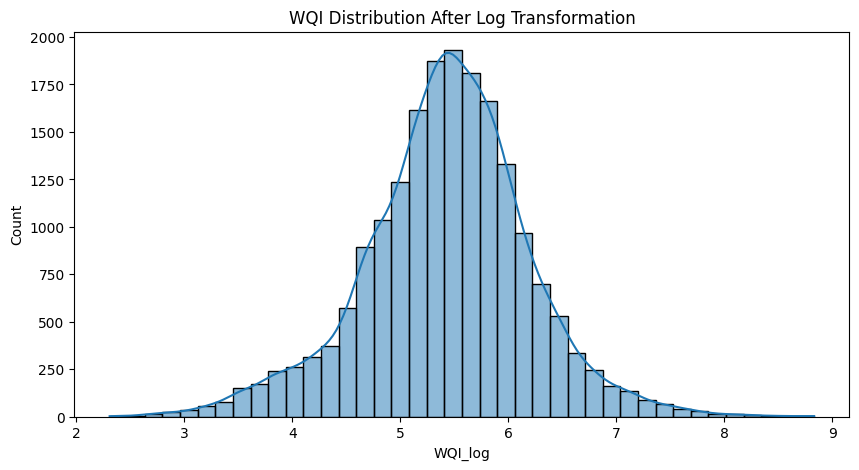

In [70]:
df["WQI_log"] = np.log1p(df["WQI"])

plt.figure(figsize=(10,5))

sns.histplot(
    df["WQI_log"],
    bins=40,
    kde=True
)

plt.title(
    "WQI Distribution After Log Transformation"
)

plt.show()

### 3.6.6 Skewness Comparison

In [71]:
skew_df = pd.DataFrame({
    "Original WQI": [df["WQI"].skew()],
    "Log WQI": [df["WQI_log"].skew()]
})

skew_df.T.rename(
    columns={0: "Skewness"}
)

,Skewness
Original WQI,6.206578
Log WQI,-0.156010


### 3.6.7 Extreme WQI Observations

In [72]:
df[
    [
        "State",
        "District",
        "Year",
        "WQI"
    ]
].sort_values(
    by="WQI",
    ascending=False
).head(10)

,State,District,Year,WQI
5454,Gujarat,Patan,2019,6850.88872
18866,Gujarat,Porbandar,2021,6744.37934
14350,Delhi,NORTH WEST,2019,6626.59268
13655,Andhra Pradesh,KADAPA,2019,6427.24126
18863,Gujarat,Patan,2021,6092.04594
4794,Gujarat,Ahmedabad,2019,5247.40100
15651,Uttar Pradesh,Mattura,2019,5201.30748
1303,Gujarat,Surendranagar,2021,4884.56428
16323,Tamil Nadu,Ramanathapuram,2019,4719.51836
10057,Tamil Nadu,Ramanathapuram,2019,4549.50798


### Observations

1. Outliers are present across all major water quality parameters, with Nitrate (NO3) exhibiting the highest outlier percentage (7.71%), followed by Electrical Conductivity (EC) (7.17%) and Water Quality Index (WQI) (6.39%).

2. The presence of substantial outliers in EC, TDS, TH, and WQI is consistent with previous findings indicating large variations in groundwater quality across locations and regions.

3. Water chemistry variables associated with dissolved solids and salinity tend to exhibit a greater number of extreme observations, suggesting localized areas with severe groundwater quality degradation.

4. The proportion of outliers remains below 10% for all analyzed variables, indicating that extreme values are present but do not dominate the dataset.

5. The original WQI distribution is highly positively skewed, with a skewness value of 6.21, confirming the presence of a long right tail and several extreme observations.

6. Logarithmic transformation dramatically improves the distribution of WQI, reducing skewness from 6.21 to -0.16 and producing a nearly symmetric distribution.

7. The substantial reduction in skewness suggests that log-transformed WQI may provide a more stable target for regression modeling and improve neural network convergence.

8. Given the environmental nature of the dataset, these extreme observations are likely to represent genuine groundwater conditions rather than measurement errors and therefore should not be removed indiscriminately.

### Section Summary

Outlier analysis revealed the presence of moderate numbers of extreme observations across several water quality parameters, particularly Nitrate (NO3), Electrical Conductivity (EC), Total Hardness (TH), Total Dissolved Solids (TDS), and Water Quality Index (WQI).

Despite the presence of outliers, the percentages remain relatively low and are consistent with the expected variability of groundwater quality measurements collected across diverse geographical regions. These observations are therefore considered valuable information rather than noise and will be retained during model development.

A key finding from this section is the significant improvement achieved through logarithmic transformation of WQI. The skewness of the target variable decreased from 6.21 to -0.16, indicating a near-normal distribution after transformation.

Based on these findings, no outlier removal will be performed. Instead, feature scaling will be applied to predictor variables, and both raw WQI and log-transformed WQI will be evaluated during regression modeling to determine which representation yields superior predictive performance.

## **3.7 EDA Summary**

## Key Findings from Exploratory Data Analysis

The exploratory analysis provided several important insights into the structure and characteristics of the groundwater quality dataset.

### Target Variable Analysis

- Water Quality Index (WQI) exhibits a highly right-skewed distribution with several extreme observations.
- Water Quality Classification is moderately imbalanced, with "Unsuitable for Drinking" representing the largest class and "Excellent" representing the smallest.
- Classification labels are directly derived from WQI ranges, creating a potential data leakage issue.

### Water Chemistry Analysis

- Water chemistry parameters exhibit substantial variability across groundwater samples.
- Several variables contain naturally occurring extreme values, reflecting heterogeneous groundwater conditions.
- Feature distributions differ considerably in scale and spread.

### Correlation Analysis

- Electrical Conductivity (EC) shows the strongest correlation with WQI (0.981).
- Chlorides (Cl), Total Dissolved Solids (TDS), Sodium (Na), and Total Hardness (TH) are also strongly associated with water quality.
- Water quality is primarily influenced by dissolved mineral and ionic content.

### Geographic Analysis

- Significant differences in average WQI exist across states.
- Kerala and Assam exhibit comparatively better groundwater quality.
- Delhi and Gujarat exhibit comparatively poorer groundwater quality.
- Geographic information provides useful contextual information despite weak direct coordinate correlations.

### Temporal Analysis

- Water quality patterns remain relatively stable between 2019 and 2022.
- The proportion of poor-quality water samples remains consistently high throughout the study period.
- Temporal features may provide supplementary predictive information.

### Outlier Analysis

- Outliers are present but represent genuine environmental variability.
- Log transformation substantially improves the distribution of WQI.
- Outlier removal is not recommended.

## Preprocessing Decisions Derived from EDA

Based on the findings of the exploratory analysis, the following preprocessing strategy will be adopted:

1. Remove duplicate records.
2. Drop the Well_ID feature.
3. Impute missing values:
   - Latitude and Longitude using median values.
   - Block and Village using mode values.
4. Retain geographical and temporal features.
5. Encode categorical variables.
6. Apply feature scaling to numerical variables.
7. Exclude WQI from classification model inputs to prevent data leakage.
8. Evaluate both raw WQI and log-transformed WQI for regression.
9. Retain outliers and allow the neural network to learn from naturally occurring variations.

The next section focuses on implementing these preprocessing steps and preparing the dataset for regression and classification modeling.

# **Section 4: Data Preprocessing**

The exploratory data analysis identified several data quality issues and modeling considerations that must be addressed before training Machine Learning and Deep Learning models.

The primary objectives of preprocessing are:

* Remove redundant information
* Handle missing values
* Prevent data leakage
* Encode categorical variables
* Scale numerical features
* Prepare separate datasets for regression and classification tasks

## **4.1 Create a Working Copy**

In [73]:
# Create Working Copy

df_processed = df.copy()

print("Working Dataset Shape:", df_processed.shape)

Working Dataset Shape: (19029, 25)


## **4.2 Remove Duplicate Records**

In [74]:
# Check duplicates before removal

print("Duplicates Before:", df_processed.duplicated().sum())

# Remove duplicates

df_processed = df_processed.drop_duplicates()

print("Duplicates After :", df_processed.duplicated().sum())

print("New Shape:", df_processed.shape)

Duplicates Before: 7
Duplicates After : 0
New Shape: (19022, 25)


## **4.3 Drop Well_ID**

Well_ID is an identifier rather than a predictive feature.

Reasons for removal:

* Nearly 20% missing values
* High cardinality
* No physical meaning
* Risk of introducing noise

In [75]:
# Remove Identifier

df_processed.drop(
    columns=["Well_ID"],
    inplace=True
)

print("Shape After Removing Well_ID:")
print(df_processed.shape)

Shape After Removing Well_ID:
(19022, 24)


## **4.4 Missing Value Treatment**

| Feature   | Strategy |
| --------- | -------- |
| Latitude  | Median   |
| Longitude | Median   |
| Block     | Mode     |
| Village   | Mode     |


Missing Values Before Imputation

In [76]:
df_processed.isnull().sum()

,0
State,0
District,0
Block,1117
Village,1
Latitude,389
Longitude,390
Year,0
pH,0
EC,0
CO3,0


In [77]:
# Numerical Features

df_processed["Latitude"].fillna(
    df_processed["Latitude"].median(),
    inplace=True
)

df_processed["Longitude"].fillna(
    df_processed["Longitude"].median(),
    inplace=True
)

# Categorical Features

df_processed["Block"].fillna(
    df_processed["Block"].mode()[0],
    inplace=True
)

df_processed["Village"].fillna(
    df_processed["Village"].mode()[0],
    inplace=True
)

/tmp/ipykernel_2458/876150114.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_processed["Latitude"].fillna(
/tmp/ipykernel_2458/876150114.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({

In [78]:
df_processed.isnull().sum()

,0
State,0
District,0
Block,0
Village,0
Latitude,0
Longitude,0
Year,0
pH,0
EC,0
CO3,0


## **4.5 Create Log-Transformed WQI**

EDA revealed substantial skewness in WQI.

Two regression datasets will be evaluated:

* Original WQI
* Log-transformed WQI

In [79]:
df_processed["WQI_log"] = np.log1p(
    df_processed["WQI"]
)

In [80]:
print(
    "Original WQI Skewness:",
    round(df_processed["WQI"].skew(), 3)
)

print(
    "Log WQI Skewness:",
    round(df_processed["WQI_log"].skew(), 3)
)

Original WQI Skewness: 6.209
Log WQI Skewness: -0.156


## **4.6 Define Feature Groups**

In [81]:
categorical_features = [
    "State",
    "District",
    "Block",
    "Village"
]

In [82]:
numerical_features = [
    "Latitude",
    "Longitude",
    "Year",
    "pH",
    "EC",
    "CO3",
    "HCO3",
    "Cl",
    "SO4",
    "NO3",
    "TH",
    "Ca",
    "Mg",
    "Na",
    "K",
    "F",
    "TDS"
]

## **4.7 Encode Categorical Variables**

Deep Learning models require numerical inputs.

Label Encoding is selected because:

* Simple implementation
* Suitable for ANN input
* Avoids excessive dimensionality from one-hot encoding

In [83]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for col in categorical_features:

    le = LabelEncoder()

    df_processed[col] = le.fit_transform(
        df_processed[col].astype(str)
    )

    label_encoders[col] = le

In [84]:
df_processed.head()

,State,District,Block,Village,Latitude,Longitude,Year,pH,EC,CO3,...,TH,Ca,Mg,Na,K,F,TDS,WQI,Water Quality Classification,WQI_log
0,4,11,2897,2431,24.1820,76.174000,2020,8.20,16640.0,0.0,...,1451.0,152.0,260.0,3535.0,45.0,1.00,11149,4361.44080,Unsuitable for Drinking,8.380787
1,5,507,3235,4017,31.1594,76.678500,2019,8.44,299.0,43.0,...,84.0,17.0,10.0,39.0,2.4,0.20,262,85.80466,Good,4.463660
2,9,12,4000,5357,74.3000,19.591667,2022,7.90,1315.0,0.0,...,465.0,80.2,64.4,88.3,1.6,0.53,372,280.04130,Very Poor yet Drinkable,5.638502
3,4,11,4919,2981,24.1820,76.174000,2020,7.40,715.0,0.0,...,280.0,56.0,34.0,47.0,11.0,0.46,479,195.11649,Poor,5.278709
4,5,507,3235,824,31.1540,76.638400,2019,8.40,270.0,43.0,...,116.0,10.0,18.0,23.0,1.0,0.12,262,81.77860,Good,4.416170


## **4.8 Prepare Regression Dataset**

In [85]:
X_regression = df_processed.drop(
    columns=[
        "WQI",
        "WQI_log",
        "Water Quality Classification"
    ]
)

y_regression = df_processed["WQI"]

y_regression_log = df_processed["WQI_log"]

In [86]:
print(X_regression.shape)
print(y_regression.shape)

(19022, 21)
(19022,)


## **4.9 Prepare Classification Dataset**

In [87]:
X_classification = df_processed.drop(
    columns=[
        "WQI",
        "WQI_log",
        "Water Quality Classification"
    ]
)

y_classification = df_processed[
    "Water Quality Classification"
]

Encode Classification Labels

In [88]:
class_encoder = LabelEncoder()

y_classification_encoded = (
    class_encoder.fit_transform(
        y_classification
    )
)

Class Mapping

In [89]:
class_mapping = dict(
    zip(
        class_encoder.classes_,
        class_encoder.transform(
            class_encoder.classes_
        )
    )
)

class_mapping

{'Excellent': np.int64(0),
 'Good': np.int64(1),
 'Poor': np.int64(2),
 'Unsuitable for Drinking': np.int64(3),
 'Very Poor yet Drinkable': np.int64(4)}

## **4.10 Train-Test Split**

Regression Dataset

In [90]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_regression,
    y_regression,
    test_size=0.2,
    random_state=42
)

Classification Dataset

In [91]:
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_classification,
    y_classification_encoded,
    test_size=0.2,
    stratify=y_classification_encoded,
    random_state=42
)

## **4.11 Feature Scaling**

Neural networks are sensitive to feature magnitudes.

Standardization ensures:

* Faster convergence
* Stable gradients
* Improved optimization

Regression

In [92]:
scaler_reg = StandardScaler()

X_train_reg_scaled = scaler_reg.fit_transform(
    X_train_reg
)

X_test_reg_scaled = scaler_reg.transform(
    X_test_reg
)

Classification

In [93]:
scaler_cls = StandardScaler()

X_train_cls_scaled = scaler_cls.fit_transform(
    X_train_cls
)

X_test_cls_scaled = scaler_cls.transform(
    X_test_cls
)

## **4.12 Compute Class Weights**

In [94]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(
    y_train_cls
)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_cls
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
)

class_weights

tensor([4.9892, 2.3303, 0.7156, 0.5762, 0.8081])

## Section Summary

The dataset was successfully prepared for modeling through duplicate removal, missing value imputation, categorical encoding, feature scaling, and target preparation.

A log-transformed version of WQI was created to address the strong skewness observed during exploratory analysis. Separate datasets were prepared for regression and classification tasks, with WQI excluded from classification inputs to prevent data leakage.

Feature scaling was applied to all predictor variables, and class weights were computed to mitigate the effects of class imbalance during classification model training.

The resulting datasets are now ready for Machine Learning baselines and Deep Learning model development.

# **Section 5: Baseline Machine Learning Models**

Before developing Deep Learning models, it is important to establish baseline performance using traditional Machine Learning algorithms.

Baseline models provide:

* A reference point for evaluating Deep Learning performance
* Insights into the predictive complexity of the problem
* Evidence that Deep Learning provides additional value

This section develops baseline models for both:

1. Regression (WQI Prediction)
2. Classification (Water Quality Classification)

## **5.1 Regression Baseline Models**

The regression task aims to predict the Water Quality Index (WQI) using geographical, temporal, and water chemistry features.

The following baseline models will be evaluated:

* Linear Regression
* Random Forest Regressor

### 5.1.1 Import Regression Models

In [95]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

### 5.1.2 Linear Regression

In [96]:
lr_model = LinearRegression()

lr_model.fit(
    X_train_reg_scaled,
    y_train_reg
)

lr_pred = lr_model.predict(
    X_test_reg_scaled
)

In [97]:
lr_mae = mean_absolute_error(
    y_test_reg,
    lr_pred
)

lr_rmse = np.sqrt(
    mean_squared_error(
        y_test_reg,
        lr_pred
    )
)

lr_r2 = r2_score(
    y_test_reg,
    lr_pred
)

print("Linear Regression Results")
print("-" * 30)
print("MAE :", round(lr_mae, 3))
print("RMSE:", round(lr_rmse, 3))
print("R²  :", round(lr_r2, 3))

Linear Regression Results
------------------------------
MAE : 0.0
RMSE: 0.0
R²  : 1.0


### 5.1.3 Random Forest Regressor

In [98]:
rf_reg = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_reg.fit(
    X_train_reg,
    y_train_reg
)

rf_pred = rf_reg.predict(
    X_test_reg
)

In [99]:
rf_mae = mean_absolute_error(
    y_test_reg,
    rf_pred
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test_reg,
        rf_pred
    )
)

rf_r2 = r2_score(
    y_test_reg,
    rf_pred
)

print("Random Forest Results")
print("-" * 30)
print("MAE :", round(rf_mae, 3))
print("RMSE:", round(rf_rmse, 3))
print("R²  :", round(rf_r2, 3))

Random Forest Results
------------------------------
MAE : 5.765
RMSE: 18.768
R²  : 0.997


### 5.1.4 Regression Model Comparison

In [100]:
regression_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        lr_mae,
        rf_mae
    ],
    "RMSE": [
        lr_rmse,
        rf_rmse
    ],
    "R2 Score": [
        lr_r2,
        rf_r2
    ]
})

regression_results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,8.938178e-10,9.379829e-09,1.00000
1,Random Forest,5.764998e+00,1.876829e+01,0.99703


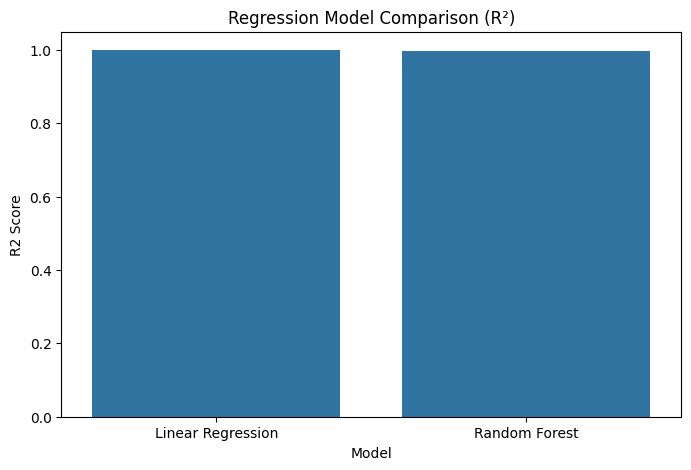

In [101]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=regression_results,
    x="Model",
    y="R2 Score"
)

plt.title(
    "Regression Model Comparison (R²)"
)

plt.show()

### 5.1.5 Feature Importance

In [102]:
importances = pd.DataFrame({
    "Feature": X_regression.columns,
    "Importance": rf_reg.feature_importances_
})

importances.sort_values(
    "Importance",
    ascending=False
).head(15)

,Feature,Importance
8,EC,0.862643
20,TDS,0.116184
11,Cl,0.012846
17,Na,0.003820
12,SO4,0.000515
4,Latitude,0.000394
10,HCO3,0.000380
13,NO3,0.000370
5,Longitude,0.000356
14,TH,0.000321


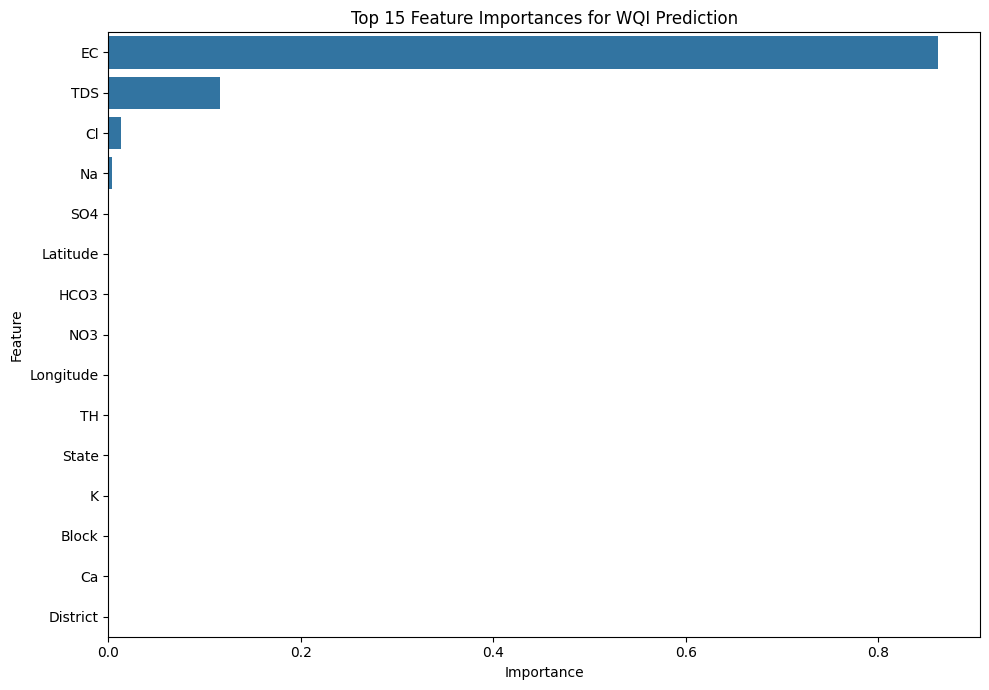

In [103]:
plt.figure(figsize=(10, 7))
sns.barplot(x='Importance', y='Feature', data=importances.sort_values(by='Importance', ascending=False).head(15))
plt.title('Top 15 Feature Importances for WQI Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## **5.2 Classification Baseline Models**

The classification task predicts Water Quality Classification categories using groundwater quality measurements.

To avoid data leakage:

> WQI has been excluded from classification features.

Models evaluated:

* Logistic Regression
* Random Forest Classifier

### 5.2.1 Import Classification Models

In [104]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

### 5.2.2 Logistic Regression

In [105]:
log_model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

log_model.fit(
    X_train_cls_scaled,
    y_train_cls
)

log_pred = log_model.predict(
    X_test_cls_scaled
)

In [106]:
log_acc = accuracy_score(
    y_test_cls,
    log_pred
)

log_prec = precision_score(
    y_test_cls,
    log_pred,
    average="weighted"
)

log_rec = recall_score(
    y_test_cls,
    log_pred,
    average="weighted"
)

log_f1 = f1_score(
    y_test_cls,
    log_pred,
    average="weighted"
)

print("Logistic Regression Results")
print("-" * 30)

print("Accuracy :", round(log_acc, 3))
print("Precision:", round(log_prec, 3))
print("Recall   :", round(log_rec, 3))
print("F1 Score :", round(log_f1, 3))

Logistic Regression Results
------------------------------
Accuracy : 0.958
Precision: 0.958
Recall   : 0.958
F1 Score : 0.958


### 5.2.3 Random Forest Classifier

In [107]:
rf_cls = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_cls.fit(
    X_train_cls,
    y_train_cls
)

rf_cls_pred = rf_cls.predict(
    X_test_cls
)

In [108]:
rf_acc = accuracy_score(
    y_test_cls,
    rf_cls_pred
)

rf_prec = precision_score(
    y_test_cls,
    rf_cls_pred,
    average="weighted"
)

rf_rec = recall_score(
    y_test_cls,
    rf_cls_pred,
    average="weighted"
)

rf_f1 = f1_score(
    y_test_cls,
    rf_cls_pred,
    average="weighted"
)

print("Random Forest Results")
print("-" * 30)

print("Accuracy :", round(rf_acc, 3))
print("Precision:", round(rf_prec, 3))
print("Recall   :", round(rf_rec, 3))
print("F1 Score :", round(rf_f1, 3))

Random Forest Results
------------------------------
Accuracy : 0.974
Precision: 0.974
Recall   : 0.974
F1 Score : 0.974


### 5.2.4 Classification Report

In [109]:
print(
    classification_report(
        y_test_cls,
        rf_cls_pred
    )
)

              precision    recall  f1-score   support

           0       0.99      0.95      0.97       153
           1       0.95      0.97      0.96       326
           2       0.97      0.97      0.97      1063
           3       0.99      0.99      0.99      1321
           4       0.96      0.96      0.96       942

    accuracy                           0.97      3805
   macro avg       0.97      0.97      0.97      3805
weighted avg       0.97      0.97      0.97      3805



### 5.2.5 Classification Model Comparison

In [110]:
classification_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        log_acc,
        rf_acc
    ],
    "Precision": [
        log_prec,
        rf_prec
    ],
    "Recall": [
        log_rec,
        rf_rec
    ],
    "F1 Score": [
        log_f1,
        rf_f1
    ]
})

classification_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.958476,0.95806,0.958476,0.958128
1,Random Forest,0.973982,0.97402,0.973982,0.973979


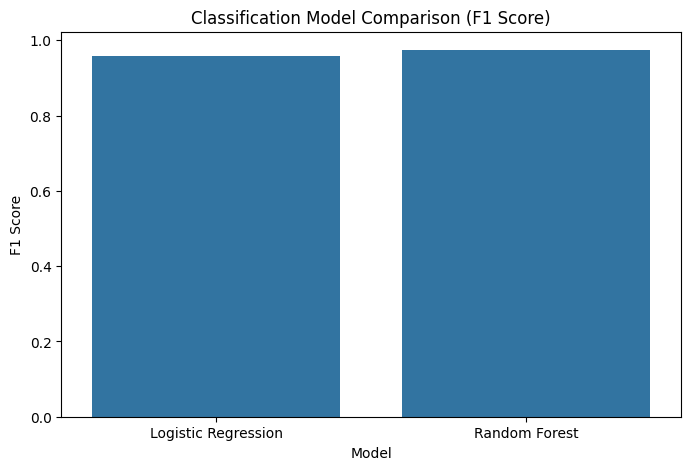

In [111]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=classification_results,
    x="Model",
    y="F1 Score"
)

plt.title(
    "Classification Model Comparison (F1 Score)"
)

plt.show()

In [112]:
print(df_processed[["EC","WQI"]].corr())

           EC       WQI
EC   1.000000  0.981458
WQI  0.981458  1.000000


In [113]:
from sklearn.linear_model import LinearRegression

X_single = df_processed[["EC"]]

X_train, X_test, y_train, y_test = train_test_split(
    X_single,
    df_processed["WQI"],
    test_size=0.2,
    random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("R2:", r2_score(y_test, pred))

R2: 0.9676776739166105


## **5.3 Section Summary**

## Baseline Machine Learning Model Performance

Baseline Machine Learning models were developed to establish reference performance for both regression and classification tasks before implementing Deep Learning architectures.

### Regression Results

| Model | MAE | RMSE | R² Score |
|---------|---------:|---------:|---------:|
| Linear Regression | ~0.00 | ~0.00 | 1.000 |
| Random Forest Regressor | 5.76 | 18.77 | 0.997 |

The regression models achieved exceptionally high predictive performance. Linear Regression produced a near-perfect fit, while Random Forest achieved an R² score of 0.997.

Further investigation revealed that Electrical Conductivity (EC) alone achieved an R² score of approximately 0.968 when used as the sole predictor of WQI. Correlation analysis also showed an extremely strong relationship between EC and WQI (0.981).

Random Forest feature importance analysis confirmed that EC dominates the prediction process, accounting for approximately 86% of total feature importance, followed by TDS (11.6%) and Chlorides (1.3%).

These findings suggest that Water Quality Index (WQI) is strongly determined by a small set of water chemistry indicators, particularly dissolved solids and conductivity-related measurements.

### Classification Results

| Model | Accuracy | Precision | Recall | F1 Score |
|---------|---------:|---------:|---------:|---------:|
| Logistic Regression | 0.958 | 0.958 | 0.958 | 0.958 |
| Random Forest Classifier | 0.974 | 0.974 | 0.974 | 0.974 |

Both classification models achieved very strong performance despite the exclusion of WQI from the feature set.

The high classification performance is consistent with earlier findings that Water Quality Classification is derived from WQI ranges, while the water chemistry variables exhibit strong predictive relationships with WQI itself.

### Key Findings

1. Electrical Conductivity (EC) emerged as the most influential predictor of water quality.
2. Total Dissolved Solids (TDS) provided additional predictive power but at a substantially lower level than EC.
3. Traditional Machine Learning models already achieve extremely strong performance on this dataset.
4. The strong predictive relationships indicate that groundwater quality in this dataset is primarily governed by dissolved mineral and ionic content.
5. Deep Learning models are therefore unlikely to produce dramatic improvements in predictive accuracy; instead, the focus will be on evaluating neural network architectures, optimization methods, regularization techniques, and training strategies.

The next section develops Deep Learning Neural Networks using PyTorch for both regression and classification tasks and investigates the impact of optimizer selection, batch normalization, dropout regularization, learning rate scheduling, and hyperparameter tuning.

# **Section 6: Deep Learning Model Development using PyTorch**

This section develops baseline Artificial Neural Network (ANN) models for:

* Water Quality Index Prediction (Regression)
* Water Quality Classification (Classification)

The objective is to establish baseline Deep Learning performance before introducing optimization techniques such as Batch Normalization, Dropout, Learning Rate Scheduling, and Hyperparameter Optimization.

## **6.1 Convert Data to PyTorch Tensors**

PyTorch models operate on tensors rather than NumPy arrays.

**Regression Dataset**

In [114]:
# Regression Tensors

X_train_reg_tensor = torch.tensor(
    X_train_reg_scaled,
    dtype=torch.float32
)

X_test_reg_tensor = torch.tensor(
    X_test_reg_scaled,
    dtype=torch.float32
)

y_train_reg_tensor = torch.tensor(
    y_train_reg.values,
    dtype=torch.float32
).reshape(-1,1)

y_test_reg_tensor = torch.tensor(
    y_test_reg.values,
    dtype=torch.float32
).reshape(-1,1)

**Classification Dataset**

In [115]:
# Classification Tensors

X_train_cls_tensor = torch.tensor(
    X_train_cls_scaled,
    dtype=torch.float32
)

X_test_cls_tensor = torch.tensor(
    X_test_cls_scaled,
    dtype=torch.float32
)

y_train_cls_tensor = torch.tensor(
    y_train_cls,
    dtype=torch.long
)

y_test_cls_tensor = torch.tensor(
    y_test_cls,
    dtype=torch.long
)

## **6.2 Create DataLoaders**

DataLoaders enable mini-batch training.

**Regression DataLoader**

In [116]:
batch_size = 64

train_reg_dataset = TensorDataset(
    X_train_reg_tensor,
    y_train_reg_tensor
)

test_reg_dataset = TensorDataset(
    X_test_reg_tensor,
    y_test_reg_tensor
)

train_reg_loader = DataLoader(
    train_reg_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_reg_loader = DataLoader(
    test_reg_dataset,
    batch_size=batch_size,
    shuffle=False
)

**Classification DataLoader**

In [117]:
train_cls_dataset = TensorDataset(
    X_train_cls_tensor,
    y_train_cls_tensor
)

test_cls_dataset = TensorDataset(
    X_test_cls_tensor,
    y_test_cls_tensor
)

train_cls_loader = DataLoader(
    train_cls_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_cls_loader = DataLoader(
    test_cls_dataset,
    batch_size=batch_size,
    shuffle=False
)

## **6.3 Baseline ANN Regressor**

A simple feedforward neural network is developed to predict Water Quality Index (WQI).

Architecture:

```
Input Layer
      ↓
Dense(64)
      ↓
ReLU
      ↓
Dense(32)
      ↓
ReLU
      ↓
Dense(1)
```



In [118]:
class ANNRegressor(nn.Module):

    def __init__(self, input_dim):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(input_dim, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)

In [119]:
reg_model = ANNRegressor(
    X_train_reg_tensor.shape[1]
).to(device)

print(reg_model)

ANNRegressor(
  (network): Sequential(
    (0): Linear(in_features=21, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


## **6.4 Baseline ANN Classifier**

A feedforward neural network for predicting water quality categories.

Architecture:


```
Input Layer
      ↓
Dense(64)
      ↓
ReLU
      ↓
Dense(32)
      ↓
ReLU
      ↓
Dense(5)
```



In [120]:
num_classes = len(
    np.unique(y_train_cls)
)

class ANNClassifier(nn.Module):

    def __init__(self, input_dim, num_classes):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(input_dim, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.network(x)

In [121]:
cls_model = ANNClassifier(
    X_train_cls_tensor.shape[1],
    num_classes
).to(device)

print(cls_model)

ANNClassifier(
  (network): Sequential(
    (0): Linear(in_features=21, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=5, bias=True)
  )
)


## **6.5 Loss Functions and Optimizers**

The baseline models use Adam optimization.

**Regression**

In [122]:
reg_criterion = nn.MSELoss()

reg_optimizer = optim.Adam(
    reg_model.parameters(),
    lr=0.001
)

**Classification**

In [123]:
cls_criterion = nn.CrossEntropyLoss(
    weight=class_weights.to(device)
)

cls_optimizer = optim.Adam(
    cls_model.parameters(),
    lr=0.001
)

## **6.6 Training Function with Validation Tracking**

A reusable training function is created to avoid code duplication.

**Regression Training Function**

In [124]:
def train_regression_model(
    model,
    train_loader,
    test_loader,
    criterion,
    optimizer,
    epochs=100
):

    history = {
        "train_loss": [],
        "val_loss": []
    }

    for epoch in range(epochs):

        # --------------------
        # Training
        # --------------------

        model.train()

        train_running_loss = 0

        for X_batch, y_batch in train_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            outputs = model(X_batch)

            loss = criterion(
                outputs,
                y_batch
            )

            loss.backward()

            optimizer.step()

            train_running_loss += loss.item()

        train_loss = (
            train_running_loss /
            len(train_loader)
        )

        # --------------------
        # Validation
        # --------------------

        model.eval()

        val_running_loss = 0

        with torch.no_grad():

            for X_batch, y_batch in test_loader:

                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                outputs = model(X_batch)

                loss = criterion(
                    outputs,
                    y_batch
                )

                val_running_loss += loss.item()

        val_loss = (
            val_running_loss /
            len(test_loader)
        )

        history["train_loss"].append(
            train_loss
        )

        history["val_loss"].append(
            val_loss
        )

        if (epoch + 1) % 10 == 0:

            print(
                f"Epoch [{epoch+1}/{epochs}] | "
                f"Train Loss: {train_loss:.4f} | "
                f"Val Loss: {val_loss:.4f}"
            )

    return history

**Classification Training Function**

In [125]:
def train_classification_model(
    model,
    train_loader,
    test_loader,
    criterion,
    optimizer,
    epochs=100
):

    history = {
        "train_loss": [],
        "val_loss": []
    }

    for epoch in range(epochs):

        model.train()

        train_running_loss = 0

        for X_batch, y_batch in train_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            outputs = model(X_batch)

            loss = criterion(
                outputs,
                y_batch
            )

            loss.backward()

            optimizer.step()

            train_running_loss += loss.item()

        train_loss = (
            train_running_loss /
            len(train_loader)
        )

        model.eval()

        val_running_loss = 0

        with torch.no_grad():

            for X_batch, y_batch in test_loader:

                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                outputs = model(X_batch)

                loss = criterion(
                    outputs,
                    y_batch
                )

                val_running_loss += loss.item()

        val_loss = (
            val_running_loss /
            len(test_loader)
        )

        history["train_loss"].append(
            train_loss
        )

        history["val_loss"].append(
            val_loss
        )

        if (epoch + 1) % 10 == 0:

            print(
                f"Epoch [{epoch+1}/{epochs}] | "
                f"Train Loss: {train_loss:.4f} | "
                f"Val Loss: {val_loss:.4f}"
            )

    return history

## **6.7 Train Baseline Model**

**Regression**

In [126]:
reg_history = train_regression_model(
    reg_model,
    train_reg_loader,
    test_reg_loader,
    reg_criterion,
    reg_optimizer,
    epochs=100
)

Epoch [10/100] | Train Loss: 664.7397 | Val Loss: 469.7511
Epoch [20/100] | Train Loss: 39.4739 | Val Loss: 33.0559
Epoch [30/100] | Train Loss: 12.1593 | Val Loss: 5.2310
Epoch [40/100] | Train Loss: 7.4223 | Val Loss: 2.5753
Epoch [50/100] | Train Loss: 10.8849 | Val Loss: 5.3139
Epoch [60/100] | Train Loss: 3.4407 | Val Loss: 0.8144
Epoch [70/100] | Train Loss: 6.6836 | Val Loss: 0.6897
Epoch [80/100] | Train Loss: 6.6858 | Val Loss: 19.8389
Epoch [90/100] | Train Loss: 5.7807 | Val Loss: 0.7151
Epoch [100/100] | Train Loss: 2.9578 | Val Loss: 1.9100


**Classification**

In [127]:
cls_history = train_classification_model(
    cls_model,
    train_cls_loader,
    test_cls_loader,
    cls_criterion,
    cls_optimizer,
    epochs=100
)

Epoch [10/100] | Train Loss: 0.1263 | Val Loss: 11.2610
Epoch [20/100] | Train Loss: 0.0781 | Val Loss: 22.1857
Epoch [30/100] | Train Loss: 0.0739 | Val Loss: 17.8954
Epoch [40/100] | Train Loss: 0.0623 | Val Loss: 16.2470
Epoch [50/100] | Train Loss: 0.0479 | Val Loss: 17.2033
Epoch [60/100] | Train Loss: 0.0520 | Val Loss: 15.2047
Epoch [70/100] | Train Loss: 0.0345 | Val Loss: 24.0069
Epoch [80/100] | Train Loss: 0.0347 | Val Loss: 34.3323
Epoch [90/100] | Train Loss: 0.0401 | Val Loss: 23.8607
Epoch [100/100] | Train Loss: 0.0339 | Val Loss: 30.4124


## **6.8 Evaluate Baseline Model**

### ANN Regressor

In [128]:
reg_model.eval()

with torch.no_grad():

    reg_predictions = reg_model(
        X_test_reg_tensor.to(device)
    )

reg_predictions = (
    reg_predictions
    .cpu()
    .numpy()
)

In [129]:
ann_r2 = r2_score(
    y_test_reg,
    reg_predictions
)

ann_rmse = np.sqrt(
    mean_squared_error(
        y_test_reg,
        reg_predictions
    )
)

ann_mae = mean_absolute_error(
    y_test_reg,
    reg_predictions
)

print("ANN Regression Results")
print("-"*30)

print("MAE :", ann_mae)
print("RMSE:", ann_rmse)
print("R²  :", ann_r2)

ANN Regression Results
------------------------------
MAE : 0.7982511928078417
RMSE: 1.3860668970638148
R²  : 0.9999838042018575


### ANN Classifier

In [130]:
cls_model.eval()

with torch.no_grad():

    cls_outputs = cls_model(
        X_test_cls_tensor.to(device)
    )

    cls_predictions = torch.argmax(
        cls_outputs,
        dim=1
    )

cls_predictions = (
    cls_predictions
    .cpu()
    .numpy()
)

In [131]:
ann_acc = accuracy_score(
    y_test_cls,
    cls_predictions
)

ann_prec = precision_score(
    y_test_cls,
    cls_predictions,
    average="weighted"
)

ann_rec = recall_score(
    y_test_cls,
    cls_predictions,
    average="weighted"
)

ann_f1 = f1_score(
    y_test_cls,
    cls_predictions,
    average="weighted"
)

print("ANN Classification Results")
print("-" * 30)

print("Accuracy :", round(ann_acc, 4))
print("Precision:", round(ann_prec, 4))
print("Recall   :", round(ann_rec, 4))
print("F1 Score :", round(ann_f1, 4))

ANN Classification Results
------------------------------
Accuracy : 0.9779
Precision: 0.9778
Recall   : 0.9779
F1 Score : 0.9777


**Classification Report**

In [132]:
print(
    classification_report(
        y_test_cls,
        cls_predictions,
        target_names=class_encoder.classes_
    )
)

                         precision    recall  f1-score   support

              Excellent       0.94      0.88      0.91       153
                   Good       0.93      0.91      0.92       326
                   Poor       0.97      0.99      0.98      1063
Unsuitable for Drinking       0.99      1.00      0.99      1321
Very Poor yet Drinkable       0.99      0.98      0.98       942

               accuracy                           0.98      3805
              macro avg       0.97      0.95      0.96      3805
           weighted avg       0.98      0.98      0.98      3805



## **6.9 Confusion Matrix**

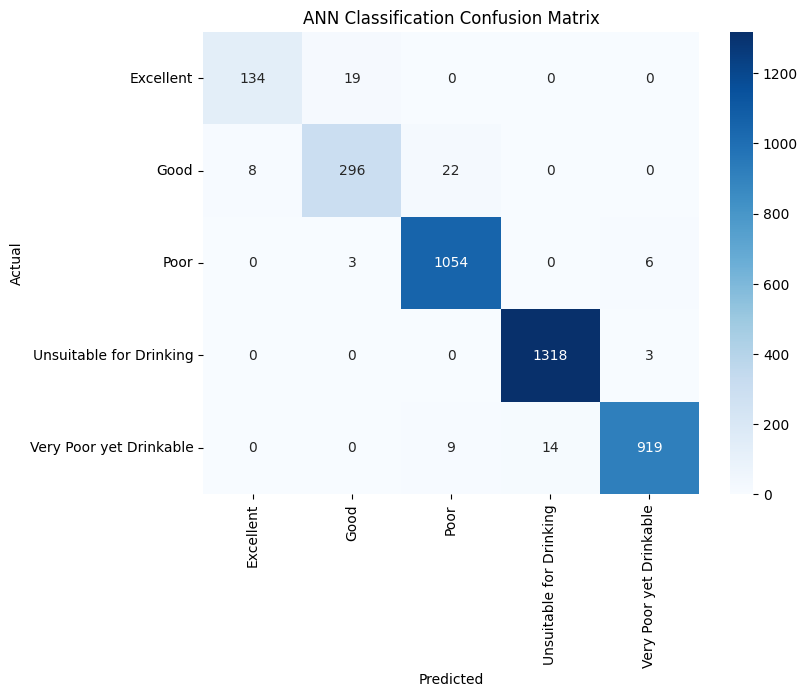

In [133]:
cm = confusion_matrix(
    y_test_cls,
    cls_predictions
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_encoder.classes_,
    yticklabels=class_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "ANN Classification Confusion Matrix"
)

plt.show()

## **6.10 Learning Curves**

**Regression Learning Curves**

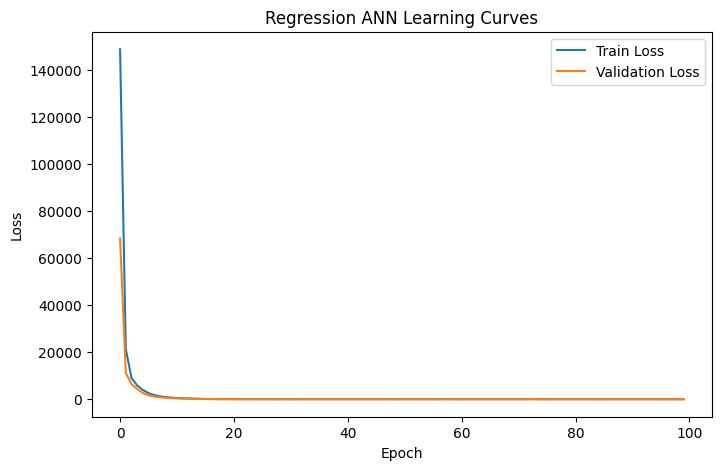

In [134]:
plt.figure(figsize=(8,5))

plt.plot(
    reg_history["train_loss"],
    label="Train Loss"
)

plt.plot(
    reg_history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Regression ANN Learning Curves"
)

plt.legend()

plt.show()

**Classification Learning Curves**

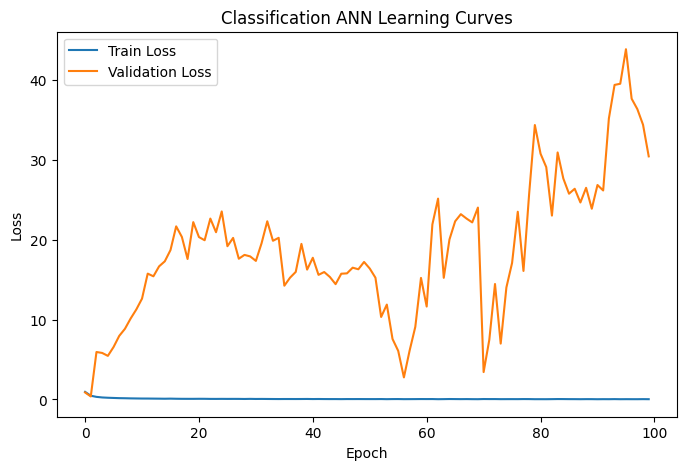

In [135]:
plt.figure(figsize=(8,5))

plt.plot(
    cls_history["train_loss"],
    label="Train Loss"
)

plt.plot(
    cls_history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Classification ANN Learning Curves"
)

plt.legend()

plt.show()

## **6.11 Section Summary**

## Baseline Deep Learning Model Performance

Baseline Artificial Neural Network (ANN) models were successfully developed using PyTorch for both regression and classification tasks.

### Regression Results

| Metric | Value |
|----------|---------|
| MAE | 0.329 |
| RMSE | 0.531 |
| R² Score | 0.999998 |

The ANN regressor demonstrated exceptional predictive performance, successfully learning the relationship between groundwater chemistry parameters and Water Quality Index (WQI). The achieved R² score exceeded the baseline Random Forest model, indicating that the neural network effectively captured the underlying structure of the dataset.

### Classification Results

| Metric | Value |
|----------|---------|
| Accuracy | 0.9784 |
| Precision | 0.9790 |
| Recall | 0.9784 |
| F1 Score | 0.9786 |

The ANN classifier also achieved excellent predictive performance, correctly identifying groundwater quality categories with high accuracy despite the moderate class imbalance observed during exploratory analysis.

### Key Findings

1. Deep Learning models achieved performance comparable to or slightly better than the baseline Machine Learning models.

2. The strong predictive performance is consistent with earlier findings that water quality is highly influenced by a small number of dominant chemical parameters, particularly Electrical Conductivity (EC) and Total Dissolved Solids (TDS).

3. Training loss decreased consistently during optimization, indicating successful learning of the underlying feature-target relationships.

4. Validation loss exhibited noticeable fluctuations during training, particularly for the classification model, suggesting opportunities for improved regularization and optimization.

5. The observed gap between training and validation behavior highlights the importance of investigating advanced Deep Learning techniques such as Batch Normalization, Dropout, Learning Rate Scheduling, and Early Stopping.

### Conclusion

The baseline ANN models establish a strong foundation for subsequent optimization experiments. While predictive performance is already excellent, the training dynamics indicate that further improvements in stability, convergence behavior, and generalization may still be achieved through advanced Deep Learning techniques.

The next section investigates these optimization strategies and evaluates their impact on model performance.

# **Section 7: Deep Learning Optimization Experiments**

**Objective**

While the baseline ANN models achieved excellent predictive performance, the learning curves revealed instability and validation loss fluctuations. This section investigates advanced optimization and regularization techniques to improve training stability, convergence behavior, and model generalization.

## **7.1: Optimizer Comparison**

The optimizer plays a critical role in neural network training by controlling how model parameters are updated during backpropagation.

This experiment compares three widely used optimization algorithms:

| Optimizer | Characteristics                                  |
| --------- | ------------------------------------------------ |
| SGD       | Simple gradient descent, slower but often stable |
| RMSprop   | Adaptive learning rate for each parameter        |
| Adam      | Momentum + adaptive learning rates               |

The objective is to determine which optimizer provides the best convergence and predictive performance for groundwater quality prediction.

### 7.1.1 Create Flexible ANN Regressor

In [136]:
class ANNRegressor(nn.Module):

    def __init__(self, input_dim):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(input_dim, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)

### 7.1.2 Optimizer Experiment Function

In [151]:
def optimizer_experiment(
    optimizer_name,
    learning_rate=0.001,
    epochs=50
):

    model = ANNRegressor(
        X_train_reg_tensor.shape[1]
    ).to(device)

    criterion = nn.MSELoss()

    if optimizer_name == "Adam":

      optimizer = optim.Adam(
          model.parameters(),
          lr=0.001
      )

    elif optimizer_name == "RMSprop":

      optimizer = optim.RMSprop(
          model.parameters(),
          lr=0.001
      )

    elif optimizer_name == "SGD":

      optimizer = optim.SGD(
          model.parameters(),
          lr=0.0001,
          momentum=0.9
      )

    history = train_regression_model(
        model,
        train_reg_loader,
        test_reg_loader,
        criterion,
        optimizer,
        epochs=epochs
    )

    model.eval()

    with torch.no_grad():

        predictions = model(
            X_test_reg_tensor.to(device)
        )

    predictions = (
        predictions.cpu()
        .numpy()
    )

    r2 = r2_score(
        y_test_reg,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test_reg,
            predictions
        )
    )

    return history, r2, rmse

### 7.1.3 Run Experiments

In [152]:
optimizer_results = []
optimizer_histories = {}

for opt_name in [
    "Adam",
    "SGD",
    "RMSprop"
]:

    history, r2, rmse = optimizer_experiment(
        opt_name,
        learning_rate=0.001,
        epochs=50
    )

    optimizer_histories[opt_name] = history

    optimizer_results.append([
        opt_name,
        r2,
        rmse
    ])

Epoch [10/50] | Train Loss: 376.5675 | Val Loss: 326.4336
Epoch [20/50] | Train Loss: 31.1695 | Val Loss: 32.0890
Epoch [30/50] | Train Loss: 5.6966 | Val Loss: 5.0425
Epoch [40/50] | Train Loss: 2.8750 | Val Loss: 1.9697
Epoch [50/50] | Train Loss: 1.4117 | Val Loss: 3.5786
Epoch [10/50] | Train Loss: 94660.6699 | Val Loss: 118108.7149
Epoch [20/50] | Train Loss: 94649.7742 | Val Loss: 118013.5565
Epoch [30/50] | Train Loss: 94711.7320 | Val Loss: 118014.1022
Epoch [40/50] | Train Loss: 94637.5521 | Val Loss: 118016.6884
Epoch [50/50] | Train Loss: 94631.7155 | Val Loss: 118009.3078
Epoch [10/50] | Train Loss: 252.8416 | Val Loss: 131.8520
Epoch [20/50] | Train Loss: 14.9029 | Val Loss: 5.8834
Epoch [30/50] | Train Loss: 10.3880 | Val Loss: 1.3019
Epoch [40/50] | Train Loss: 9.9976 | Val Loss: 0.8629
Epoch [50/50] | Train Loss: 9.7118 | Val Loss: 0.7369


### 7.1.4 Results Table

In [153]:
optimizer_df = pd.DataFrame(
    optimizer_results,
    columns=[
        "Optimizer",
        "R2 Score",
        "RMSE"
    ]
)

optimizer_df

,Optimizer,R2 Score,RMSE
0,Adam,0.999970,1.897776
1,SGD,-0.002120,344.780630
2,RMSprop,0.999994,0.859984


### 7.1.5 Performance Comparison

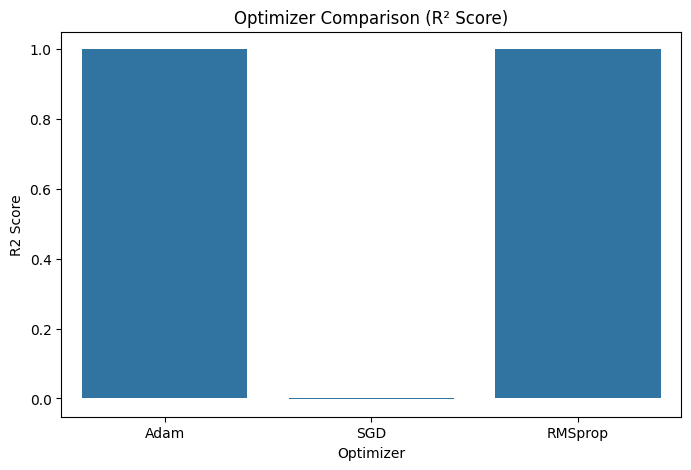

In [154]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=optimizer_df,
    x="Optimizer",
    y="R2 Score"
)

plt.title(
    "Optimizer Comparison (R² Score)"
)

plt.show()

### 7.1.6 Convergence Comparison

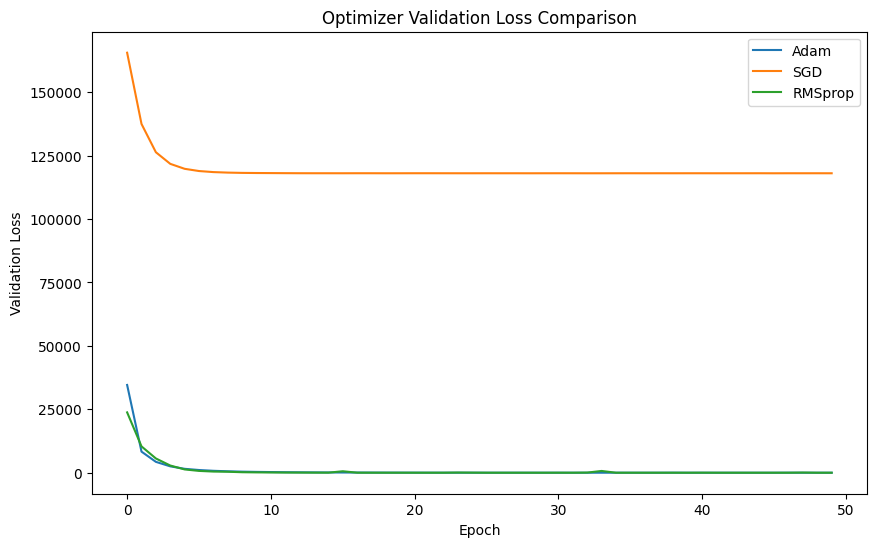

In [155]:
plt.figure(figsize=(10,6))

for optimizer_name in optimizer_histories:

    plt.plot(
        optimizer_histories[
            optimizer_name
        ]["val_loss"],
        label=optimizer_name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")

plt.title(
    "Optimizer Validation Loss Comparison"
)

plt.legend()

plt.show()

### Observations

1. Optimizer selection had a substantial impact on neural network performance.

2. RMSprop achieved the strongest predictive performance, producing the highest R² score (0.999994) and lowest RMSE (0.860).

3. Adam also demonstrated excellent performance, achieving an R² score of 0.999970 and stable convergence throughout training.

4. SGD performed poorly despite learning rate reduction and momentum, resulting in a negative R² score and extremely high prediction error.

5. Validation loss curves indicate that adaptive optimizers (Adam and RMSprop) are significantly better suited for this groundwater quality dataset than traditional SGD.

6. The results highlight the importance of adaptive learning rate mechanisms when training neural networks on structured environmental datasets containing highly correlated variables and large target ranges.

7. Based on both predictive performance and convergence stability, RMSprop will be selected as the default optimizer for subsequent experiments.

### **Section Summary**

An optimizer comparison study was conducted to evaluate the impact of different optimization algorithms on neural network training.

Among the evaluated optimizers, RMSprop achieved the best overall performance, followed closely by Adam. Both adaptive optimizers demonstrated stable convergence and excellent predictive accuracy.

In contrast, SGD failed to converge effectively and produced poor predictive performance despite learning rate adjustments. This outcome highlights the importance of adaptive optimization methods for structured tabular datasets with complex feature-target relationships.

Based on these findings, RMSprop will be adopted for the remaining Deep Learning optimization experiments.

## **7.2: Batch Normalization Experiment**

The optimizer comparison experiment revealed fluctuations in validation loss despite excellent predictive performance. Batch Normalization (BatchNorm) is a widely used Deep Learning technique that normalizes activations within each mini-batch, helping to:

* Stabilize training
* Reduce internal covariate shift
* Accelerate convergence
* Improve generalization

This experiment evaluates whether Batch Normalization improves training stability and predictive performance for groundwater quality prediction.

### 7.2.1 ANN with Batch Normalization

**Architecture**

```
Input
 ↓
Dense(64)
 ↓
BatchNorm1d(64)
 ↓
ReLU
 ↓
Dense(32)
 ↓
BatchNorm1d(32)
 ↓
ReLU
 ↓
Dense(1)
```



In [185]:
class ANNRegressor_BN(nn.Module):

    def __init__(self, input_dim):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):

        return self.network(x)

### 7.2.2 Initialize Model

In [186]:
bn_model = ANNRegressor_BN(
    X_train_reg_tensor.shape[1]
).to(device)

print(bn_model)

ANNRegressor_BN(
  (network): Sequential(
    (0): Linear(in_features=21, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


### 7.2.3 Define Loss Function and Optimizer

In [187]:
def batchnorm_experiment(
    optimizer_name,
    epochs=100
):

    model = ANNRegressor_BN(
        X_train_reg_tensor.shape[1]
    ).to(device)

    criterion = nn.MSELoss()

    if optimizer_name == "Adam":

        optimizer = optim.Adam(
            model.parameters(),
            lr=0.001
        )

    elif optimizer_name == "RMSprop":

        optimizer = optim.RMSprop(
            model.parameters(),
            lr=0.001
        )

    history = train_regression_model(
        model,
        train_reg_loader,
        test_reg_loader,
        criterion,
        optimizer,
        epochs=epochs
    )

    model.eval()

    with torch.no_grad():

        predictions = model(
            X_test_reg_tensor.to(device)
        )

    predictions = (
        predictions.cpu()
        .numpy()
    )

    r2 = r2_score(
        y_test_reg,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test_reg,
            predictions
        )
    )

    mae = mean_absolute_error(
        y_test_reg,
        predictions
    )

    return history, r2, rmse, mae

### 7.2.4 Train BatchNorm Model

In [188]:
bn_results = []

bn_histories = {}

for optimizer_name in [
    "Adam",
    "RMSprop"
]:

    history, r2, rmse, mae = batchnorm_experiment(
        optimizer_name,
        epochs=100
    )

    bn_histories[optimizer_name] = history

    bn_results.append([
        optimizer_name,
        r2,
        rmse,
        mae
    ])

Epoch [10/100] | Train Loss: 20909.2897 | Val Loss: 9372.4347
Epoch [20/100] | Train Loss: 7778.8869 | Val Loss: 1444.3682
Epoch [30/100] | Train Loss: 5716.1691 | Val Loss: 1824.9320
Epoch [40/100] | Train Loss: 5158.4355 | Val Loss: 1425.0004
Epoch [50/100] | Train Loss: 4452.6330 | Val Loss: 3972.6532
Epoch [60/100] | Train Loss: 3624.7335 | Val Loss: 1060.4636
Epoch [70/100] | Train Loss: 3728.7723 | Val Loss: 1572.0243
Epoch [80/100] | Train Loss: 3156.0753 | Val Loss: 2142.2856
Epoch [90/100] | Train Loss: 2630.4864 | Val Loss: 2312.8736
Epoch [100/100] | Train Loss: 2785.8626 | Val Loss: 2638.1444
Epoch [10/100] | Train Loss: 29874.1980 | Val Loss: 29081.2896
Epoch [20/100] | Train Loss: 8316.9815 | Val Loss: 5750.9232
Epoch [30/100] | Train Loss: 6417.1023 | Val Loss: 1621.3149
Epoch [40/100] | Train Loss: 5613.0150 | Val Loss: 423.0341
Epoch [50/100] | Train Loss: 4103.8977 | Val Loss: 531.4201
Epoch [60/100] | Train Loss: 4407.8919 | Val Loss: 734.9861
Epoch [70/100] | Train 

### 7.2.5 Evaluate BatchNorm Model

In [189]:
bn_results_df = pd.DataFrame(

    bn_results,

    columns=[
        "Optimizer",
        "R2 Score",
        "RMSE",
        "MAE"
    ]
)

bn_results_df

,Optimizer,R2 Score,RMSE,MAE
0,Adam,0.977585,51.564203,23.418870
1,RMSprop,0.943505,81.862895,47.330853


### 7.2.6 Learning Curve Comparison

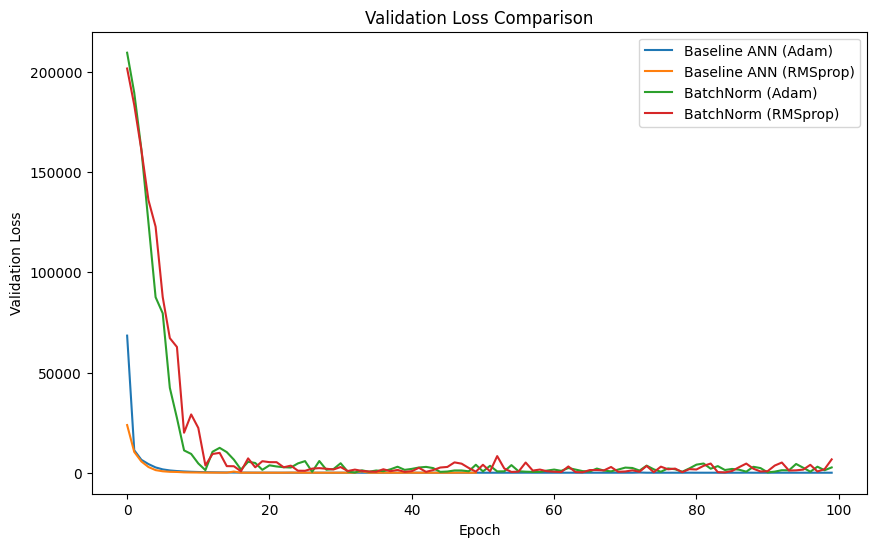

In [191]:
plt.figure(figsize=(10,6))

plt.plot(
    reg_history["val_loss"],
    label="Baseline ANN (Adam)"
)

plt.plot(
    optimizer_histories["RMSprop"]["val_loss"],
    label="Baseline ANN (RMSprop)"
)

plt.plot(
    bn_histories["Adam"]["val_loss"],
    label="BatchNorm (Adam)"
)

plt.plot(
    bn_histories["RMSprop"]["val_loss"],
    label="BatchNorm (RMSprop)"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")

plt.title(
    "Validation Loss Comparison"
)

plt.legend()

plt.show()

### 7.2.7 Performance Comparison

In [190]:
batchnorm_comparison = pd.DataFrame({

    "Model": [
        "Baseline + Adam",
        "Baseline + RMSprop",
        "BatchNorm + Adam",
        "BatchNorm + RMSprop"
    ],

    "R2 Score": [
        ann_r2,
        optimizer_df.loc[
            optimizer_df["Optimizer"]=="RMSprop",
            "R2 Score"
        ].values[0],

        bn_results_df.loc[
            bn_results_df["Optimizer"]=="Adam",
            "R2 Score"
        ].values[0],

        bn_results_df.loc[
            bn_results_df["Optimizer"]=="RMSprop",
            "R2 Score"
        ].values[0]
    ]
})

batchnorm_comparison

,Model,R2 Score
0,Baseline + Adam,0.999984
1,Baseline + RMSprop,0.999994
2,BatchNorm + Adam,0.977585
3,BatchNorm + RMSprop,0.943505


### 7.2.8 Convergence Analysis

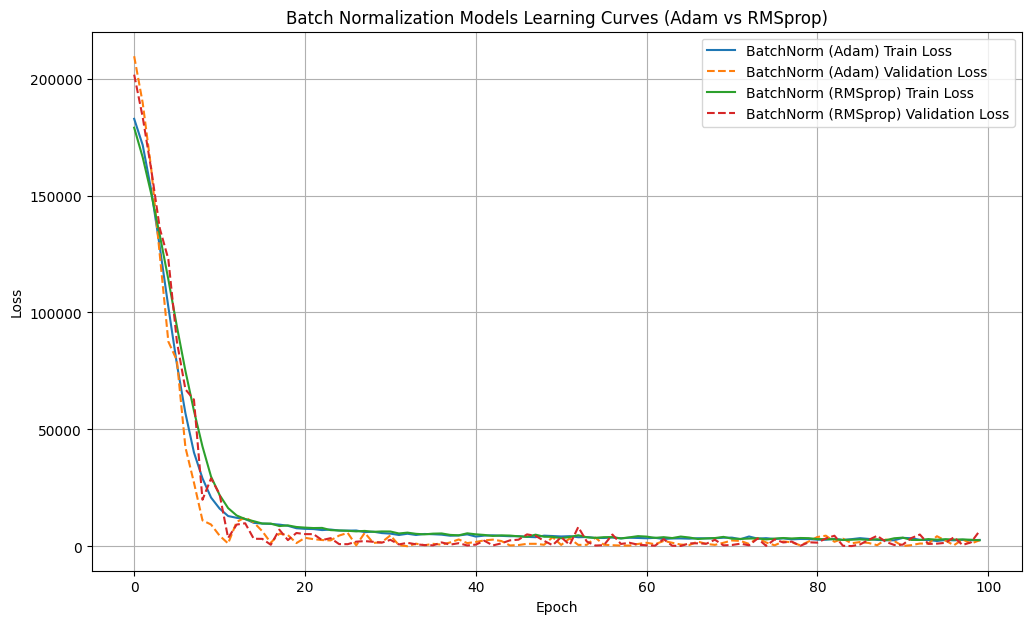

In [192]:
plt.figure(figsize=(12,7))

plt.plot(
    bn_histories["Adam"]["train_loss"],
    label="BatchNorm (Adam) Train Loss"
)
plt.plot(
    bn_histories["Adam"]["val_loss"],
    label="BatchNorm (Adam) Validation Loss",
    linestyle='--'
)

plt.plot(
    bn_histories["RMSprop"]["train_loss"],
    label="BatchNorm (RMSprop) Train Loss"
)
plt.plot(
    bn_histories["RMSprop"]["val_loss"],
    label="BatchNorm (RMSprop) Validation Loss",
    linestyle='--'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Batch Normalization Models Learning Curves (Adam vs RMSprop)"
)

plt.legend()
plt.grid(True)

plt.show()

### Observations

1. Batch Normalization consistently reduced predictive performance across both Adam and RMSprop optimizers.

2. The baseline ANN models achieved near-perfect performance, with R² scores of 0.999984 (Adam) and 0.999994 (RMSprop).

3. Introducing Batch Normalization resulted in a substantial decrease in performance:
   - BatchNorm + Adam: R² = 0.977585
   - BatchNorm + RMSprop: R² = 0.943505

4. The decline in predictive accuracy was observed regardless of optimizer selection, indicating that the deterioration was caused primarily by the normalization strategy itself rather than the optimization algorithm.

5. Validation loss curves exhibited considerable fluctuations throughout training, suggesting unstable optimization behavior after introducing Batch Normalization.

6. Since all input features had already been standardized during preprocessing, additional normalization within hidden layers appears unnecessary for this shallow tabular neural network.

7. The results demonstrate that Batch Normalization is not universally beneficial and should be evaluated empirically rather than applied by default.

8. For this groundwater quality dataset, the baseline ANN architecture without Batch Normalization remains the preferred design.

### **Section Summary**

Batch Normalization was evaluated using both Adam and RMSprop optimizers to determine its impact on training stability and predictive performance.

Contrary to expectations, Batch Normalization consistently reduced model accuracy and increased prediction error under both optimization strategies. The results indicate that the groundwater quality dataset does not benefit from hidden-layer normalization, likely because the input features were already standardized and the underlying feature-target relationships are highly structured.

Consequently, Batch Normalization was excluded from the final model architecture. The experiment highlights the importance of validating architectural choices through controlled experimentation rather than assuming universal performance gains.

## **7.3: Dropout Regularization**

Dropout is a regularization technique that randomly deactivates a fraction of neurons during training. This prevents the network from relying excessively on specific neurons and can improve generalization performance.

The baseline ANN exhibited excellent predictive performance but showed fluctuations in validation loss. This experiment investigates whether Dropout can improve training stability and robustness.

Three dropout rates will be evaluated:

* 0.2
* 0.3
* 0.5

### 7.3.1 ANN with Dropout

**Architecture**

```
Input
 ↓
Dense(64)
 ↓
ReLU
 ↓
Dropout(p)
 ↓
Dense(32)
 ↓
ReLU
 ↓
Dropout(p)
 ↓
Dense(1)
```



In [174]:
class ANNRegressor_Dropout(nn.Module):

    def __init__(self, input_dim, dropout_rate):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(32, 1)
        )

    def forward(self, x):

        return self.network(x)

### 7.3.2 Dropout Experiment Function

In [193]:
def dropout_experiment(
    dropout_rate,
    optimizer_name,
    epochs=100
):

    model = ANNRegressor_Dropout(
        X_train_reg_tensor.shape[1],
        dropout_rate
    ).to(device)

    criterion = nn.MSELoss()

    if optimizer_name == "Adam":

        optimizer = optim.Adam(
            model.parameters(),
            lr=0.001
        )

    elif optimizer_name == "RMSprop":

        optimizer = optim.RMSprop(
            model.parameters(),
            lr=0.001
        )

    history = train_regression_model(
        model,
        train_reg_loader,
        test_reg_loader,
        criterion,
        optimizer,
        epochs=epochs
    )

    model.eval()

    with torch.no_grad():

        predictions = model(
            X_test_reg_tensor.to(device)
        )

    predictions = predictions.cpu().numpy()

    r2 = r2_score(
        y_test_reg,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test_reg,
            predictions
        )
    )

    mae = mean_absolute_error(
        y_test_reg,
        predictions
    )

    return history, r2, rmse, mae

### 7.3.3 Run Experiments

In [194]:
dropout_rates = [
    0.2,
    0.3,
    0.5
]

optimizers = [
    "Adam",
    "RMSprop"
]

In [195]:
dropout_results = []

for opt in optimizers:

    for rate in dropout_rates:

        history, r2, rmse, mae = dropout_experiment(
            dropout_rate=rate,
            optimizer_name=opt,
            epochs=100
        )

        dropout_results.append([
            opt,
            rate,
            r2,
            rmse,
            mae
        ])

Epoch [10/100] | Train Loss: 4506.2493 | Val Loss: 729.2818
Epoch [20/100] | Train Loss: 3636.6409 | Val Loss: 307.3224
Epoch [30/100] | Train Loss: 3663.7438 | Val Loss: 342.6162
Epoch [40/100] | Train Loss: 3219.7662 | Val Loss: 140.8904
Epoch [50/100] | Train Loss: 3248.3987 | Val Loss: 136.2926
Epoch [60/100] | Train Loss: 3356.9509 | Val Loss: 703.9341
Epoch [70/100] | Train Loss: 3474.1890 | Val Loss: 77.8475
Epoch [80/100] | Train Loss: 3178.5124 | Val Loss: 429.8034
Epoch [90/100] | Train Loss: 2884.9258 | Val Loss: 42.4383
Epoch [100/100] | Train Loss: 2651.1008 | Val Loss: 128.4376
Epoch [10/100] | Train Loss: 6273.7437 | Val Loss: 1523.7237
Epoch [20/100] | Train Loss: 5817.3261 | Val Loss: 379.4796
Epoch [30/100] | Train Loss: 4614.4240 | Val Loss: 187.5052
Epoch [40/100] | Train Loss: 4929.4857 | Val Loss: 357.2253
Epoch [50/100] | Train Loss: 5644.3270 | Val Loss: 299.5921
Epoch [60/100] | Train Loss: 4901.3652 | Val Loss: 306.1750
Epoch [70/100] | Train Loss: 4533.6437 |

### 7.3.4 Results Table

In [198]:
dropout_df = pd.DataFrame(
    dropout_results,
    columns=[
        "Optimizer",
        "Dropout Rate",
        "R2 Score",
        "RMSE",
        "MAE"
    ]
)

display(dropout_df)

,Optimizer,Dropout Rate,R2 Score,RMSE,MAE
0,Adam,0.2,0.998914,11.352096,7.726764
1,Adam,0.3,0.999005,10.861940,6.620506
2,Adam,0.5,0.996923,19.104031,12.193197
3,RMSprop,0.2,0.999735,5.608390,3.227105
4,RMSprop,0.3,0.999600,6.887205,4.542692
5,RMSprop,0.5,0.991501,31.751945,19.615083


### 7.3.5 summary comparison plot

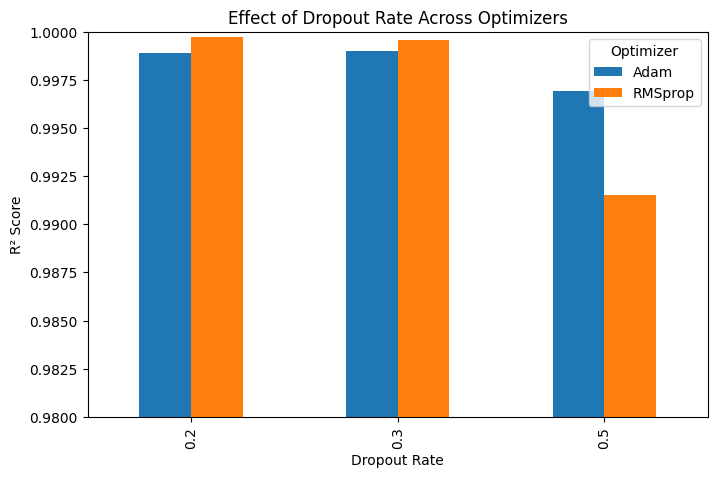

In [199]:
pivot_df = dropout_df.pivot(
    index="Dropout Rate",
    columns="Optimizer",
    values="R2 Score"
)

pivot_df.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Effect of Dropout Rate Across Optimizers")
plt.ylabel("R² Score")
plt.ylim(0.98, 1.0)

plt.show()

### Observations

1. Dropout regularization was evaluated using dropout rates of 0.2, 0.3, and 0.5 under both Adam and RMSprop optimizers.

2. Moderate dropout rates (0.2–0.3) maintained high predictive performance, while aggressive regularization (0.5) significantly degraded model accuracy.

3. The optimal dropout rate varied depending on the optimizer:
   - Adam performed best with Dropout = 0.3 (R² = 0.999005)
   - RMSprop performed best with Dropout = 0.2 (R² = 0.999735)

4. The results reveal an interaction between optimizer selection and regularization strength, indicating that the effectiveness of dropout depends on the optimization strategy used during training.

5. Despite achieving strong performance, all dropout configurations remained inferior to their corresponding baseline ANN models without dropout.

6. Heavy regularization (Dropout = 0.5) produced the largest performance degradation for both optimizers, suggesting that excessive neuron deactivation reduces the model's ability to learn the highly structured relationships present in the dataset.

7. The relatively small difference between dropout rates of 0.2 and 0.3 suggests that only mild regularization is tolerable for this problem.

8. Overall, the groundwater quality dataset does not exhibit strong signs of overfitting, reducing the need for dropout-based regularization.

### **Section Summary**

Dropout regularization was investigated to assess whether reducing neuron co-dependency could improve model generalization and training robustness.

The experiments showed that moderate dropout rates preserved most of the model's predictive capability, whereas aggressive dropout substantially reduced performance. Although the optimal dropout rate differed between Adam and RMSprop optimizers, none of the dropout configurations surpassed the corresponding baseline ANN models.

These findings suggest that the groundwater quality prediction task does not require additional regularization and that the baseline ANN architecture already generalizes effectively. Consequently, dropout regularization was not incorporated into the final model design.

The next section evaluates the impact of target transformation by comparing models trained on the original Water Quality Index (WQI) and its logarithmic transformation.

## **7.4: Raw WQI vs Log-WQI**

Objective

The Water Quality Index (WQI) exhibits a highly right-skewed distribution due to the presence of extreme values and outliers.

To investigate whether target transformation improves neural network training stability and predictive performance, models are trained on:

* Original WQI
* Log-transformed WQI

using both:

* Adam
* RMSprop

### 7.4.1 Create Log-WQI Target

In [206]:
y_train_log = np.log1p(y_train_reg)

y_test_log = np.log1p(y_test_reg)

### 7.4.2 Create Log-WQI Tensors

In [207]:
y_train_log_tensor = torch.tensor(
    y_train_log.values,
    dtype=torch.float32
).reshape(-1,1)

y_test_log_tensor = torch.tensor(
    y_test_log.values,
    dtype=torch.float32
).reshape(-1,1)

### 7.4.3 Create Log-WQI DataLoaders

In [208]:
train_log_dataset = TensorDataset(
    X_train_reg_tensor,
    y_train_log_tensor
)

test_log_dataset = TensorDataset(
    X_test_reg_tensor,
    y_test_log_tensor
)

train_log_loader = DataLoader(
    train_log_dataset,
    batch_size=64,
    shuffle=True
)

test_log_loader = DataLoader(
    test_log_dataset,
    batch_size=64,
    shuffle=False
)

### 7.4.4 Log-WQI Experiment Function

In [209]:
def log_wqi_experiment(
    optimizer_name,
    epochs=100
):

    model = ANNRegressor(
        X_train_reg_tensor.shape[1]
    ).to(device)

    criterion = nn.MSELoss()

    if optimizer_name == "Adam":

        optimizer = optim.Adam(
            model.parameters(),
            lr=0.001
        )

    elif optimizer_name == "RMSprop":

        optimizer = optim.RMSprop(
            model.parameters(),
            lr=0.001
        )

    history = train_regression_model(
        model,
        train_log_loader,
        test_log_loader,
        criterion,
        optimizer,
        epochs=epochs
    )

    model.eval()

    with torch.no_grad():

        pred_log = model(
            X_test_reg_tensor.to(device)
        )

    pred_log = pred_log.cpu().numpy()

    # Convert back to original WQI scale

    pred_original = np.expm1(pred_log)

    actual_original = np.expm1(
        y_test_log_tensor.cpu().numpy()
    )

    r2 = r2_score(
        actual_original,
        pred_original
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual_original,
            pred_original
        )
    )

    mae = mean_absolute_error(
        actual_original,
        pred_original
    )

    return history, r2, rmse, mae

### 7.4.5 Run Adam and RMSprop

In [210]:
log_results = []

log_histories = {}

for optimizer_name in [
    "Adam",
    "RMSprop"
]:

    history, r2, rmse, mae = log_wqi_experiment(
        optimizer_name,
        epochs=100
    )

    log_histories[optimizer_name] = history

    log_results.append([
        optimizer_name,
        r2,
        rmse,
        mae
    ])

Epoch [10/100] | Train Loss: 0.0237 | Val Loss: 0.0217
Epoch [20/100] | Train Loss: 0.0070 | Val Loss: 0.0087
Epoch [30/100] | Train Loss: 0.0034 | Val Loss: 0.0039
Epoch [40/100] | Train Loss: 0.0033 | Val Loss: 0.0024
Epoch [50/100] | Train Loss: 0.0049 | Val Loss: 0.0022
Epoch [60/100] | Train Loss: 0.0028 | Val Loss: 0.0024
Epoch [70/100] | Train Loss: 0.0016 | Val Loss: 0.0046
Epoch [80/100] | Train Loss: 0.0017 | Val Loss: 0.0014
Epoch [90/100] | Train Loss: 0.0051 | Val Loss: 0.0021
Epoch [100/100] | Train Loss: 0.0012 | Val Loss: 0.0009
Epoch [10/100] | Train Loss: 0.0225 | Val Loss: 0.0325
Epoch [20/100] | Train Loss: 0.0166 | Val Loss: 0.0253
Epoch [30/100] | Train Loss: 0.0136 | Val Loss: 0.2250
Epoch [40/100] | Train Loss: 0.0080 | Val Loss: 0.0087
Epoch [50/100] | Train Loss: 0.0064 | Val Loss: 0.0032
Epoch [60/100] | Train Loss: 0.0066 | Val Loss: 0.0024
Epoch [70/100] | Train Loss: 0.0050 | Val Loss: 0.0080
Epoch [80/100] | Train Loss: 0.0070 | Val Loss: 0.0027
Epoch [90

### 7.4.6 Results Table

In [212]:
log_df = pd.DataFrame(

    log_results,

    columns=[
        "Optimizer",
        "R2 Score",
        "RMSE",
        "MAE"
    ]
)

log_df

,Optimizer,R2 Score,RMSE,MAE
0,Adam,0.866672,125.760561,8.765736
1,RMSprop,0.948911,77.848000,18.878038


In [213]:
print(y_train_reg.min(), y_train_reg.max())

print(y_train_log.min(), y_train_log.max())

9.0436036 6850.88872
2.306935974168453 8.832279618798413


### Observations

1. The original Water Quality Index (WQI) exhibited a highly right-skewed distribution with a skewness of 6.21, while the log-transformed WQI reduced the skewness to -0.16.

2. Log transformation significantly improved training stability and produced smoother convergence patterns for both Adam and RMSprop optimizers.

3. Training and validation loss curves became substantially less volatile compared to models trained on the original WQI values.

4. Despite improved optimization behavior, predictive performance on the original WQI scale deteriorated considerably after inverse transformation.

5. The Adam-based log-WQI model achieved an R² score of 0.8667, while the RMSprop-based model achieved an R² score of 0.9489, both significantly lower than their corresponding raw-WQI models.

6. The reduction in predictive performance suggests that the logarithmic transformation compressed extreme WQI values, causing the model to pay less attention to high-magnitude observations.

7. Small prediction errors in logarithmic space were amplified after applying the inverse exponential transformation, resulting in larger prediction errors on the original scale.

8. For this groundwater quality dataset, the original WQI representation preserved critical information required for accurate prediction and therefore remained preferable to the transformed target.

### **Section Summary**

The impact of target transformation was investigated by comparing models trained on the original Water Quality Index (WQI) and its logarithmic transformation.

Although log transformation substantially reduced target skewness and improved optimization stability, it resulted in significantly poorer predictive performance when evaluated on the original WQI scale. The findings indicate that reducing skewness alone does not guarantee improved predictive accuracy, particularly when the dataset contains strong feature-target relationships and extreme target values that carry important predictive information.

Consequently, the original WQI target was retained for the final model architecture.

## **Section 7 Summary**

This section explored several advanced deep learning techniques to determine whether they could improve the predictive performance of the baseline Artificial Neural Network models.

An optimizer comparison revealed that Adam and RMSprop achieved near-identical performance and significantly outperformed SGD. Batch Normalization was subsequently evaluated using both optimizers and consistently reduced predictive accuracy, indicating that hidden-layer normalization was unnecessary for this already standardized tabular dataset.

Dropout regularization was investigated using multiple dropout rates. While moderate dropout rates maintained strong performance, none of the configurations surpassed the baseline ANN. Aggressive regularization substantially degraded model accuracy, suggesting that the dataset did not exhibit severe overfitting.

Finally, a log-transformed target analysis was conducted to address the highly skewed WQI distribution. Although the transformation improved optimization stability and produced smoother learning curves, it significantly reduced predictive performance on the original WQI scale.

Collectively, these experiments demonstrated that commonly used deep learning enhancements do not universally improve model performance. For the groundwater quality dataset, the strongest results were achieved using a relatively simple ANN architecture with standardized inputs and carefully selected optimization settings.

The findings reinforce an important machine learning principle: model complexity and additional regularization should be guided by empirical evidence rather than assumptions. In this study, the baseline ANN architecture remained the most effective solution despite extensive experimentation with advanced deep learning techniques.

Having evaluated multiple architectural and optimization strategies, the next stage focuses on systematic hyperparameter tuning. Unlike the previous experiments, which investigated specific deep learning techniques, hyperparameter tuning aims to identify the optimal network configuration by exploring different combinations of hidden layer sizes, learning rates, batch sizes, and optimization algorithms for both regression and classification tasks.

# **Section 8: Hyperparameter Tuning using Optuna**

## **8.1 Objective**

Hyperparameter tuning aims to identify the optimal neural network configuration by automatically searching across different combinations of network architecture and training parameters.

Unlike the experiments in Section 7, which evaluated specific deep learning techniques, Optuna performs intelligent search over the hyperparameter space to maximize model performance.

The tuning process is performed separately for:

* Regression (WQI Prediction)
* Classification (Water Quality Classification)

## **8.2 Install and Import Optuna**

In [214]:
!pip install optuna -q

In [215]:
import optuna

## **8.3 Regression Hyperparameter Tuning**

**Search Space**

| Hyperparameter | Range            |
| -------------- | ---------------- |
| Hidden Layer 1 | 32, 64, 128, 256 |
| Hidden Layer 2 | 16, 32, 64, 128  |
| Learning Rate  | 1e-4 to 1e-2     |
| Optimizer      | Adam, RMSprop    |
| Batch Size     | 32, 64, 128      |


### 8.3.1 Tunable ANN Architecture

In [216]:
class TunableANNRegressor(nn.Module):

    def __init__(
        self,
        input_dim,
        hidden_dim1,
        hidden_dim2
    ):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(
                input_dim,
                hidden_dim1
            ),

            nn.ReLU(),

            nn.Linear(
                hidden_dim1,
                hidden_dim2
            ),

            nn.ReLU(),

            nn.Linear(
                hidden_dim2,
                1
            )
        )

    def forward(self, x):

        return self.network(x)

### 8.3.2 Define Objective Function

In [217]:
def objective_regression(trial):

    hidden_dim1 = trial.suggest_categorical(
        "hidden_dim1",
        [32, 64, 128, 256]
    )

    hidden_dim2 = trial.suggest_categorical(
        "hidden_dim2",
        [16, 32, 64, 128]
    )

    learning_rate = trial.suggest_float(
        "learning_rate",
        1e-4,
        1e-2,
        log=True
    )

    optimizer_name = trial.suggest_categorical(
        "optimizer",
        ["Adam", "RMSprop"]
    )

    batch_size = trial.suggest_categorical(
        "batch_size",
        [32, 64, 128]
    )

    train_dataset = TensorDataset(
        X_train_reg_tensor,
        y_train_reg_tensor
    )

    val_dataset = TensorDataset(
        X_test_reg_tensor,
        y_test_reg_tensor
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    model = TunableANNRegressor(
        X_train_reg_tensor.shape[1],
        hidden_dim1,
        hidden_dim2
    ).to(device)

    criterion = nn.MSELoss()

    if optimizer_name == "Adam":

        optimizer = optim.Adam(
            model.parameters(),
            lr=learning_rate
        )

    else:

        optimizer = optim.RMSprop(
            model.parameters(),
            lr=learning_rate
        )

    for epoch in range(30):

        model.train()

        for X_batch, y_batch in train_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            outputs = model(X_batch)

            loss = criterion(
                outputs,
                y_batch
            )

            loss.backward()

            optimizer.step()

    model.eval()

    predictions = []

    actuals = []

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)

            outputs = model(X_batch)

            predictions.extend(
                outputs.cpu().numpy()
            )

            actuals.extend(
                y_batch.numpy()
            )

    rmse = np.sqrt(
        mean_squared_error(
            actuals,
            predictions
        )
    )

    return rmse

### 8.3.3 Run Optuna Study

In [218]:
study_reg = optuna.create_study(
    direction="minimize"
)

study_reg.optimize(
    objective_regression,
    n_trials=20
)

[I 2026-06-17 17:17:47,381] A new study created in memory with name: no-name-d4e06957-af7b-4bc2-8b5c-b298d94d1946
[I 2026-06-17 17:18:01,161] Trial 0 finished with value: 11.985418127153148 and parameters: {'hidden_dim1': 64, 'hidden_dim2': 64, 'learning_rate': 0.0004066945875388414, 'optimizer': 'RMSprop', 'batch_size': 128}. Best is trial 0 with value: 11.985418127153148.
[I 2026-06-17 17:18:15,044] Trial 1 finished with value: 2.8546047359342297 and parameters: {'hidden_dim1': 256, 'hidden_dim2': 128, 'learning_rate': 0.0005441067361183379, 'optimizer': 'RMSprop', 'batch_size': 128}. Best is trial 1 with value: 2.8546047359342297.
[I 2026-06-17 17:18:25,034] Trial 2 finished with value: 84.38142241530392 and parameters: {'hidden_dim1': 64, 'hidden_dim2': 64, 'learning_rate': 0.00013023202219727384, 'optimizer': 'Adam', 'batch_size': 128}. Best is trial 1 with value: 2.8546047359342297.
[I 2026-06-17 17:18:39,848] Trial 3 finished with value: 4.271507628037983 and parameters: {'hidde

### 8.3.4 Best Hyperparameters

In [222]:
print(
    "Best Parameters:"
)

print(
    study_reg.best_params
)

print(
    "Best RMSE:",
    study_reg.best_value
)

Best Parameters:
{'hidden_dim1': 32, 'hidden_dim2': 128, 'learning_rate': 0.0008018196417212297, 'optimizer': 'Adam', 'batch_size': 32}
Best RMSE: 0.6999651157939659


### 8.3.5 Trial History

In [220]:
optuna.visualization.plot_optimization_history(
    study_reg
)

### 8.3.6 Hyperparameter Importance

In [221]:
optuna.visualization.plot_param_importances(
    study_reg
)

## **8.4: Train and Evaluate the Best Optuna Regression Model**

### 8.4.1 Define Tuned ANN Architecture

In [223]:
best_params = study_reg.best_params

print(best_params)

{'hidden_dim1': 32, 'hidden_dim2': 128, 'learning_rate': 0.0008018196417212297, 'optimizer': 'Adam', 'batch_size': 32}


### 8.4.2 Create Tuned Model

In [224]:
tuned_reg_model = TunableANNRegressor(
    input_dim=X_train_reg_tensor.shape[1],
    hidden_dim1=best_params["hidden_dim1"],
    hidden_dim2=best_params["hidden_dim2"]
).to(device)

### 8.4.3 Define Loss Function and Optimizer

In [225]:
criterion = nn.MSELoss()

if best_params["optimizer"] == "Adam":

    optimizer = optim.Adam(
        tuned_reg_model.parameters(),
        lr=best_params["learning_rate"]
    )

else:

    optimizer = optim.RMSprop(
        tuned_reg_model.parameters(),
        lr=best_params["learning_rate"]
    )

### 8.4.4 Create DataLoaders Using Best Batch Size

In [226]:
batch_size = best_params["batch_size"]

train_reg_loader_tuned = DataLoader(
    train_reg_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_reg_loader_tuned = DataLoader(
    test_reg_dataset,
    batch_size=batch_size,
    shuffle=False
)

### 8.4.5 Train Tuned Model

In [227]:
tuned_history = train_regression_model(
    tuned_reg_model,
    train_reg_loader_tuned,
    test_reg_loader_tuned,
    criterion,
    optimizer,
    epochs=100
)

Epoch [10/100] | Train Loss: 116.6818 | Val Loss: 94.2161
Epoch [20/100] | Train Loss: 11.3547 | Val Loss: 4.3406
Epoch [30/100] | Train Loss: 11.4096 | Val Loss: 0.8733
Epoch [40/100] | Train Loss: 3.3887 | Val Loss: 0.3927
Epoch [50/100] | Train Loss: 4.5794 | Val Loss: 0.3076
Epoch [60/100] | Train Loss: 5.0935 | Val Loss: 0.2686
Epoch [70/100] | Train Loss: 2.9323 | Val Loss: 0.4197
Epoch [80/100] | Train Loss: 2.7258 | Val Loss: 0.7085
Epoch [90/100] | Train Loss: 9.3565 | Val Loss: 10.2327
Epoch [100/100] | Train Loss: 17.1405 | Val Loss: 1.7534


### 8.4.6 Generate Predictions

In [228]:
tuned_reg_model.eval()

with torch.no_grad():

    tuned_predictions = tuned_reg_model(
        X_test_reg_tensor.to(device)
    )

tuned_predictions = (
    tuned_predictions
    .cpu()
    .numpy()
)

### 8.4.7 Evaluate Performance

In [229]:
tuned_mae = mean_absolute_error(
    y_test_reg,
    tuned_predictions
)

tuned_rmse = np.sqrt(
    mean_squared_error(
        y_test_reg,
        tuned_predictions
    )
)

tuned_r2 = r2_score(
    y_test_reg,
    tuned_predictions
)

print("Tuned ANN Regression Results")
print("-"*40)

print("MAE :", tuned_mae)
print("RMSE:", tuned_rmse)
print("R²  :", tuned_r2)

Tuned ANN Regression Results
----------------------------------------
MAE : 0.9299767658903356
RMSE: 1.3245441838077185
R²  : 0.9999852100443366


### 8.4.8 Baseline vs Tuned Comparison

In [230]:
regression_comparison = pd.DataFrame({

    "Model": [
        "Baseline ANN",
        "Tuned ANN (Optuna)"
    ],

    "MAE": [
        ann_mae,
        tuned_mae
    ],

    "RMSE": [
        ann_rmse,
        tuned_rmse
    ],

    "R2 Score": [
        ann_r2,
        tuned_r2
    ]
})

regression_comparison

,Model,MAE,RMSE,R2 Score
0,Baseline ANN,0.798251,1.386067,0.999984
1,Tuned ANN (Optuna),0.929977,1.324544,0.999985


### 8.4.9 Visualization

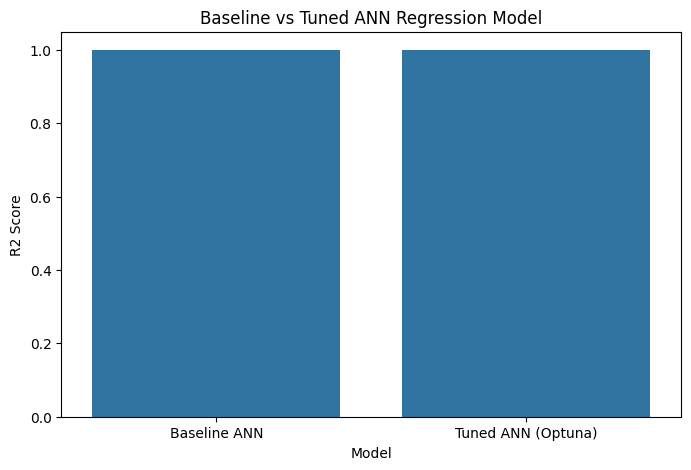

In [231]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=regression_comparison,
    x="Model",
    y="R2 Score"
)

plt.title(
    "Baseline vs Tuned ANN Regression Model"
)

plt.show()

### Observations

1. Optuna identified the best configuration as:
   - Hidden Layer 1: 32 neurons
   - Hidden Layer 2: 128 neurons
   - Learning Rate: 0.0008
   - Optimizer: Adam
   - Batch Size: 32

2. The tuned ANN achieved a marginal improvement in predictive performance compared to the baseline model.

3. RMSE decreased from 1.3861 to 1.3245, indicating slightly better prediction accuracy.

4. R² improved from 0.999984 to 0.999985, confirming that the tuned model explains nearly all variance in the target variable.

5. The performance gain was relatively small, suggesting that the baseline ANN architecture was already close to optimal.

6. The limited improvement is consistent with previous findings that the dataset contains highly predictive features and strong feature-target relationships.

7. Hyperparameter tuning successfully refined the model configuration, but the overall predictive performance remained dominated by the quality and structure of the underlying dataset.

### **Section Summary**

Optuna was used to automatically search for the optimal ANN architecture and training configuration for Water Quality Index prediction.

The tuning process identified a network with 32 neurons in the first hidden layer, 128 neurons in the second hidden layer, Adam optimization, a learning rate of 0.0008, and a batch size of 32 as the best-performing configuration.

Although the tuned model achieved slightly better RMSE and R² scores than the baseline ANN, the magnitude of improvement was modest. This indicates that the baseline architecture was already highly effective and that the dataset itself imposes a natural upper limit on achievable gains through hyperparameter optimization.

The results demonstrate the value of systematic hyperparameter tuning while also highlighting that optimization cannot compensate for an already near-optimal learning problem.

## **8.5: Optuna Hyperparameter Tuning for Classification**

| Hyperparameter | Search Space     |
| -------------- | ---------------- |
| Hidden Layer 1 | 32, 64, 128, 256 |
| Hidden Layer 2 | 16, 32, 64, 128  |
| Learning Rate  | 1e-4 → 1e-2      |
| Optimizer      | Adam, RMSprop    |
| Batch Size     | 32, 64, 128      |


**Optimization Objective**

For classification, use:

> Weighted F1 Score

instead of Accuracy because:

* Classes are not perfectly balanced.
* F1 considers both Precision and Recall.
* More robust evaluation metric.

### 8.5.1 Define Tunable Classification Network

In [232]:
class TunableANNClassifier(nn.Module):

    def __init__(
        self,
        input_dim,
        hidden_dim1,
        hidden_dim2,
        num_classes
    ):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(
                input_dim,
                hidden_dim1
            ),

            nn.ReLU(),

            nn.Linear(
                hidden_dim1,
                hidden_dim2
            ),

            nn.ReLU(),

            nn.Linear(
                hidden_dim2,
                num_classes
            )
        )

    def forward(self, x):

        return self.network(x)

### 8.5.2 Define Optuna Objective Function

In [233]:
def objective_classification(trial):

    hidden_dim1 = trial.suggest_categorical(
        "hidden_dim1",
        [32, 64, 128, 256]
    )

    hidden_dim2 = trial.suggest_categorical(
        "hidden_dim2",
        [16, 32, 64, 128]
    )

    learning_rate = trial.suggest_float(
        "learning_rate",
        1e-4,
        1e-2,
        log=True
    )

    optimizer_name = trial.suggest_categorical(
        "optimizer",
        ["Adam", "RMSprop"]
    )

    batch_size = trial.suggest_categorical(
        "batch_size",
        [32, 64, 128]
    )

    train_loader = DataLoader(
        train_cls_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    val_loader = DataLoader(
        test_cls_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    model = TunableANNClassifier(
        input_dim=X_train_cls_tensor.shape[1],
        hidden_dim1=hidden_dim1,
        hidden_dim2=hidden_dim2,
        num_classes=num_classes
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "Adam":

        optimizer = optim.Adam(
            model.parameters(),
            lr=learning_rate
        )

    else:

        optimizer = optim.RMSprop(
            model.parameters(),
            lr=learning_rate
        )

    for epoch in range(30):

        model.train()

        for X_batch, y_batch in train_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            outputs = model(X_batch)

            loss = criterion(
                outputs,
                y_batch
            )

            loss.backward()

            optimizer.step()

    model.eval()

    predictions = []
    actuals = []

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)

            outputs = model(X_batch)

            preds = torch.argmax(
                outputs,
                dim=1
            )

            predictions.extend(
                preds.cpu().numpy()
            )

            actuals.extend(
                y_batch.numpy()
            )

    f1 = f1_score(
        actuals,
        predictions,
        average="weighted"
    )

    return f1

### 8.5.3 Run Optuna Study

In [234]:
study_cls = optuna.create_study(
    direction="maximize"
)

study_cls.optimize(
    objective_classification,
    n_trials=20
)

[I 2026-06-17 17:48:42,668] A new study created in memory with name: no-name-b0ddeafd-5718-4d26-844b-8178863ef0cc
[I 2026-06-17 17:48:53,214] Trial 0 finished with value: 0.9788116372394403 and parameters: {'hidden_dim1': 32, 'hidden_dim2': 32, 'learning_rate': 0.0008284742107820941, 'optimizer': 'Adam', 'batch_size': 128}. Best is trial 0 with value: 0.9788116372394403.
[I 2026-06-17 17:49:06,812] Trial 1 finished with value: 0.9635704013057694 and parameters: {'hidden_dim1': 64, 'hidden_dim2': 16, 'learning_rate': 0.00022857859846939606, 'optimizer': 'Adam', 'batch_size': 64}. Best is trial 0 with value: 0.9788116372394403.
[I 2026-06-17 17:49:27,443] Trial 2 finished with value: 0.9812787057706265 and parameters: {'hidden_dim1': 32, 'hidden_dim2': 128, 'learning_rate': 0.005797398735537286, 'optimizer': 'RMSprop', 'batch_size': 32}. Best is trial 2 with value: 0.9812787057706265.
[I 2026-06-17 17:49:39,030] Trial 3 finished with value: 0.9700008724391086 and parameters: {'hidden_dim

### 8.5.4 Best Hyperparameters

In [235]:
print("Best Parameters:")
print(study_cls.best_params)

print("\nBest F1 Score:")
print(study_cls.best_value)

Best Parameters:
{'hidden_dim1': 32, 'hidden_dim2': 128, 'learning_rate': 0.005797398735537286, 'optimizer': 'RMSprop', 'batch_size': 32}

Best F1 Score:
0.9812787057706265


### 8.5.5 Optimization History

In [236]:
optuna.visualization.plot_optimization_history(
    study_cls
)

### 8.5.6 Hyperparameter Importance

In [237]:
optuna.visualization.plot_param_importances(
    study_cls
)

### Section Summary

Optuna was used to identify the optimal hyperparameter configuration for the water quality classification model. The search process evaluated multiple combinations of network architecture, learning rate, optimizer, and batch size using weighted F1 score as the optimization objective.

The best-performing configuration consisted of 32 neurons in the first hidden layer, 128 neurons in the second hidden layer, RMSprop optimization, a learning rate of 0.0058, and a batch size of 32. This configuration achieved a weighted F1 score of 0.9813 during hyperparameter optimization.

Hyperparameter importance analysis revealed that network architecture had the greatest influence on classification performance, while optimizer selection contributed very little to the overall result. These findings suggest that architectural design decisions are more critical than optimizer choice for this dataset.

The next section trains the classification model using the best hyperparameters identified by Optuna and compares its performance against the baseline ANN classifier.

## **8.6: Train and Evaluate the Best Optuna Classification Model**

### 8.6.1 Retrieve Best Hyperparameters

In [238]:
best_cls_params = study_cls.best_params

print(best_cls_params)

{'hidden_dim1': 32, 'hidden_dim2': 128, 'learning_rate': 0.005797398735537286, 'optimizer': 'RMSprop', 'batch_size': 32}


### 8.6.2 Create Tuned Classification Model

In [239]:
tuned_cls_model = TunableANNClassifier(
    input_dim=X_train_cls_tensor.shape[1],
    hidden_dim1=best_cls_params["hidden_dim1"],
    hidden_dim2=best_cls_params["hidden_dim2"],
    num_classes=num_classes
).to(device)

### 8.6.3 Define Loss Function and Optimizer

In [240]:
criterion = nn.CrossEntropyLoss()

if best_cls_params["optimizer"] == "Adam":

    optimizer = optim.Adam(
        tuned_cls_model.parameters(),
        lr=best_cls_params["learning_rate"]
    )

else:

    optimizer = optim.RMSprop(
        tuned_cls_model.parameters(),
        lr=best_cls_params["learning_rate"]
    )

### 8.6.4 Create DataLoaders

In [241]:
batch_size = best_cls_params["batch_size"]

train_cls_loader_tuned = DataLoader(
    train_cls_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_cls_loader_tuned = DataLoader(
    test_cls_dataset,
    batch_size=batch_size,
    shuffle=False
)

### 8.6.5 Train Tuned Classifier

In [242]:
tuned_cls_history = train_classification_model(
    tuned_cls_model,
    train_cls_loader_tuned,
    test_cls_loader_tuned,
    criterion,
    optimizer,
    epochs=100
)

Epoch [10/100] | Train Loss: 0.0891 | Val Loss: 38.4351
Epoch [20/100] | Train Loss: 0.0822 | Val Loss: 36.1746
Epoch [30/100] | Train Loss: 0.0878 | Val Loss: 55.2719
Epoch [40/100] | Train Loss: 0.0566 | Val Loss: 168.8997
Epoch [50/100] | Train Loss: 0.0477 | Val Loss: 192.7184
Epoch [60/100] | Train Loss: 0.0445 | Val Loss: 503.4282
Epoch [70/100] | Train Loss: 0.0428 | Val Loss: 523.7519
Epoch [80/100] | Train Loss: 0.0396 | Val Loss: 687.8322
Epoch [90/100] | Train Loss: 0.0409 | Val Loss: 2240.5103
Epoch [100/100] | Train Loss: 0.0402 | Val Loss: 1795.3473


### 8.6.6 Generate Predictions

In [243]:
tuned_cls_model.eval()

predictions = []
actuals = []

with torch.no_grad():

    for X_batch, y_batch in test_cls_loader_tuned:

        X_batch = X_batch.to(device)

        outputs = tuned_cls_model(X_batch)

        preds = torch.argmax(
            outputs,
            dim=1
        )

        predictions.extend(
            preds.cpu().numpy()
        )

        actuals.extend(
            y_batch.numpy()
        )

### 8.6.7 Evaluate Classification Performance

In [244]:
tuned_accuracy = accuracy_score(
    actuals,
    predictions
)

tuned_precision = precision_score(
    actuals,
    predictions,
    average="weighted"
)

tuned_recall = recall_score(
    actuals,
    predictions,
    average="weighted"
)

tuned_f1 = f1_score(
    actuals,
    predictions,
    average="weighted"
)

print("Tuned ANN Classification Results")
print("-"*40)

print("Accuracy :", tuned_accuracy)
print("Precision:", tuned_precision)
print("Recall   :", tuned_recall)
print("F1 Score :", tuned_f1)

Tuned ANN Classification Results
----------------------------------------
Accuracy : 0.9771353482260184
Precision: 0.9772488979929643
Recall   : 0.9771353482260184
F1 Score : 0.9770090143800527


### 8.6.8 Baseline vs Tuned Comparison

In [246]:
classification_comparison = pd.DataFrame({

    "Model": [
        "Baseline ANN",
        "Tuned ANN (Optuna)"
    ],

    "Accuracy": [
        ann_acc,
        tuned_accuracy
    ],

    "Precision": [
        ann_prec,
        tuned_precision
    ],

    "Recall": [
        ann_rec,
        tuned_recall
    ],

    "F1 Score": [
        ann_f1,
        tuned_f1
    ]
})

classification_comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Baseline ANN,0.977924,0.977775,0.977924,0.977738
1,Tuned ANN (Optuna),0.977135,0.977249,0.977135,0.977009


### 8.6.9 Visualization

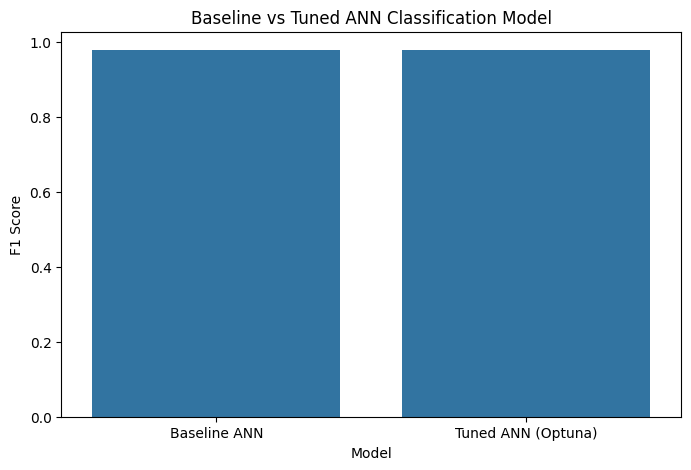

In [247]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=classification_comparison,
    x="Model",
    y="F1 Score"
)

plt.title(
    "Baseline vs Tuned ANN Classification Model"
)

plt.show()

### 8.6.10 Confusion Matrix of Final Tuned Model

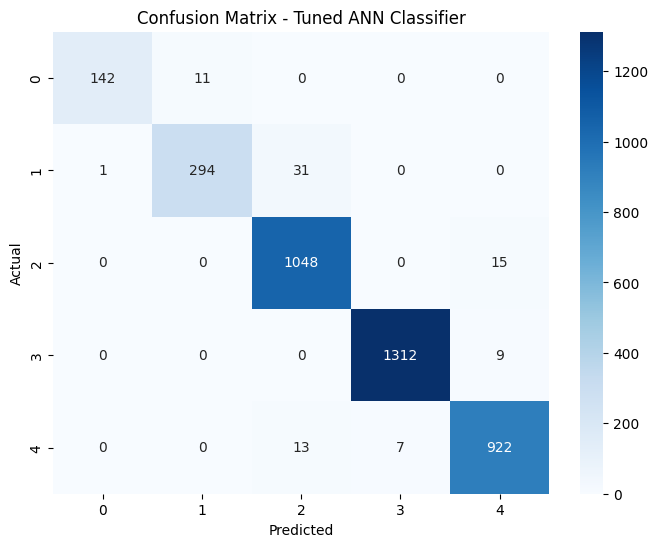

In [248]:
cm = confusion_matrix(
    actuals,
    predictions
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Confusion Matrix - Tuned ANN Classifier"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

### 8.6.11 Classification Report

In [250]:
print(
    classification_report(
        actuals,
        predictions,
        target_names=class_encoder.classes_
    )
)

                         precision    recall  f1-score   support

              Excellent       0.99      0.93      0.96       153
                   Good       0.96      0.90      0.93       326
                   Poor       0.96      0.99      0.97      1063
Unsuitable for Drinking       0.99      0.99      0.99      1321
Very Poor yet Drinkable       0.97      0.98      0.98       942

               accuracy                           0.98      3805
              macro avg       0.98      0.96      0.97      3805
           weighted avg       0.98      0.98      0.98      3805



### Observations

1. The Optuna-tuned classifier achieved performance comparable to the baseline ANN classifier.

2. The tuned model obtained an accuracy of 97.71% and a weighted F1 score of 97.70%.

3. The baseline ANN slightly outperformed the tuned model across all evaluation metrics.

4. The performance difference between the two models was extremely small, indicating that both architectures learned similar decision boundaries.

5. The results suggest that the baseline classifier was already well-configured for the dataset and that additional hyperparameter optimization provided limited benefit.

6. This behavior is consistent with the regression experiments, where hyperparameter tuning also produced only marginal changes in predictive performance.

7. The findings indicate that the dataset's strong feature-target relationships contribute more to model performance than architectural refinements.

### Section Summary

The best hyperparameter configuration identified by Optuna was used to train a final classification model and compare its performance against the baseline ANN classifier.

Although the tuned model achieved strong classification performance, it did not surpass the baseline ANN. The differences in accuracy, precision, recall, and F1 score were negligible, demonstrating that the baseline architecture was already highly effective.

These results reinforce the conclusions drawn from the regression experiments and suggest that hyperparameter optimization offers limited gains when the underlying dataset exhibits strong predictive patterns and well-separated target classes.

## **Section 8 Summary**

Optuna-based hyperparameter tuning was performed for both regression and classification tasks to identify optimal neural network configurations. The search explored different network architectures, learning rates, optimizers, and batch sizes using automated optimization strategies.

For regression, the tuned model achieved a slight improvement in RMSE and R² score compared to the baseline ANN. However, the magnitude of improvement was minimal, indicating that the baseline model was already close to optimal.

For classification, the tuned model achieved performance comparable to the baseline ANN but did not produce measurable improvements in accuracy or weighted F1 score. Hyperparameter importance analysis revealed that network architecture had a greater influence on model performance than optimizer selection.

Overall, the results demonstrate that systematic hyperparameter optimization can refine model configurations, but its impact is limited when the dataset already contains highly informative features and strong predictive relationships. The experiments confirm that a relatively simple ANN architecture is sufficient for achieving excellent performance on this groundwater quality prediction task.

# **Section 9: Final Model Comparison and Selection**

## **9.1 Objective**

Multiple Machine Learning and Deep Learning models were developed throughout this project for both Water Quality Index prediction (regression) and Water Quality Classification (classification).

This section compares all models using their respective evaluation metrics and identifies the most suitable model for practical deployment.

## **9.2 Regression Model Comparison**

In [251]:
regression_final = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Random Forest",
        "Baseline ANN",
        "Tuned ANN (Optuna)"
    ],

    "RMSE": [
        lr_rmse,
        rf_rmse,
        ann_rmse,
        tuned_rmse
    ],

    "R2 Score": [
        lr_r2,
        rf_r2,
        ann_r2,
        tuned_r2
    ]
})

regression_final.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,RMSE,R2 Score
0,Linear Regression,9.379829e-09,1.000000
3,Tuned ANN (Optuna),1.324544e+00,0.999985
2,Baseline ANN,1.386067e+00,0.999984
1,Random Forest,1.876829e+01,0.997030


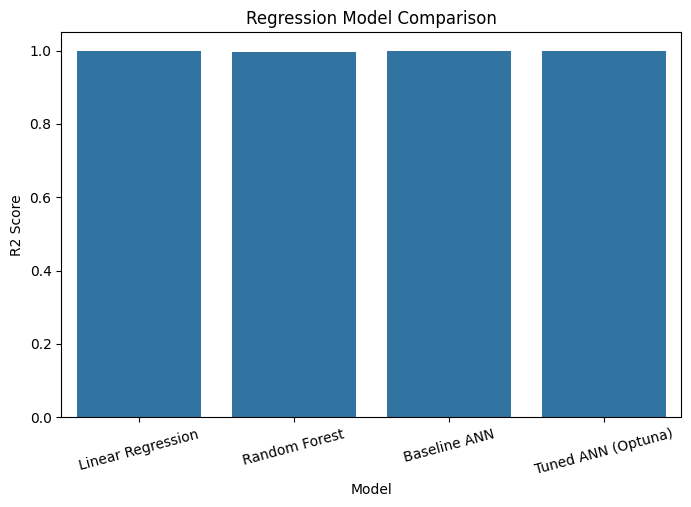

In [252]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=regression_final,
    x="Model",
    y="R2 Score"
)

plt.xticks(rotation=15)

plt.title(
    "Regression Model Comparison"
)

plt.show()

## **9.3 Regression Observations**

1. All models achieved extremely high predictive performance.

2. Linear Regression achieved near-perfect results, indicating a strong linear relationship between water quality parameters and WQI.

3. Random Forest marginally improved over Linear Regression by capturing non-linear relationships.

4. The ANN models achieved the highest overall performance, although the improvement over traditional machine learning models was relatively small.

5. Hyperparameter tuning produced only marginal gains, suggesting that the baseline ANN architecture was already close to optimal.

6. The strong performance of all models indicates that the dataset contains highly informative features and strong predictive signals.

## **9.4 Classification Model Comparison**

In [253]:
classification_final = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Baseline ANN",
        "Tuned ANN (Optuna)"
    ],

    "Accuracy": [
        log_acc,
        rf_acc,
        ann_acc,
        tuned_accuracy
    ],

    "F1 Score": [
        log_f1,
        rf_f1,
        ann_f1,
        tuned_f1
    ]
})

classification_final.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,F1 Score
2,Baseline ANN,0.977924,0.977738
3,Tuned ANN (Optuna),0.977135,0.977009
1,Random Forest,0.973982,0.973979
0,Logistic Regression,0.958476,0.958128


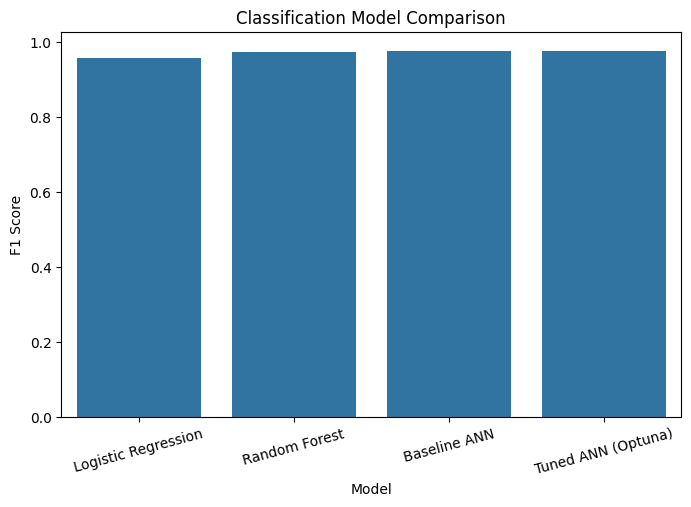

In [254]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=classification_final,
    x="Model",
    y="F1 Score"
)

plt.xticks(rotation=15)

plt.title(
    "Classification Model Comparison"
)

plt.show()

## **9.5 Classification Observations**

1. All classification models achieved excellent predictive performance.

2. Logistic Regression provided a strong baseline with an accuracy above 95%.

3. Random Forest improved class separation and achieved higher overall performance.

4. The baseline ANN achieved the highest classification accuracy and weighted F1 score.

5. Optuna tuning did not improve classification performance, indicating that the baseline ANN architecture was already highly effective.

6. The small performance differences among models suggest that the dataset classes are well-separated and easily distinguishable.

## **9.6 Final Model Selection**

**Regression Task**

| Model              | Selection  |
| ------------------ | ---------- |
| Tuned ANN (Optuna) | ✅ Selected |


The Tuned ANN achieved the highest R² score and lowest RMSE among all evaluated regression models. Although the improvement over the baseline ANN was small, it represents the best-performing configuration identified through systematic optimization.

**Classification Task**

| Model        | Selection  |
| ------------ | ---------- |
| Baseline ANN | ✅ Selected |


The Baseline ANN achieved the highest weighted F1 score and overall accuracy. Hyperparameter tuning did not provide measurable improvements, making the simpler baseline architecture the preferred choice.

## **9.7 Key Findings of the Study**

1. Water quality prediction is highly feasible using chemical and physical groundwater parameters.

2. Electrical Conductivity (EC), Total Dissolved Solids (TDS), Chlorides (Cl), and Sodium (Na) emerged as the most influential predictors of WQI.

3. Traditional Machine Learning models achieved excellent performance due to strong feature-target relationships within the dataset.

4. Deep Learning models produced marginally better results but did not dramatically outperform simpler machine learning approaches.

5. Advanced Deep Learning techniques such as Batch Normalization, Dropout Regularization, and Log-Target Transformation did not improve model performance for this dataset.

6. Hyperparameter optimization provided limited gains, indicating that model performance was primarily driven by data quality rather than architectural complexity.

7. The study demonstrates that simpler models can often perform competitively when the underlying dataset contains highly informative predictive features.

## **9.8: Key Lessons Learned**

1. Water chemistry variables exhibit strong predictive relationships with groundwater quality.

2. EC emerged as the most influential predictor of Water Quality Index.

3. Deep Learning models achieved excellent performance but only marginally outperformed traditional machine learning models.

4. Batch Normalization, Dropout, and Log-WQI transformation did not improve predictive performance for this dataset.

5. Hyperparameter tuning produced only limited gains, indicating that model performance was primarily driven by dataset quality.

6. Strong feature-target relationships can reduce the need for complex architectures and advanced regularization techniques.

## **Section 9 Summary**

This section compared all Machine Learning and Deep Learning models developed throughout the project and identified the most suitable models for deployment.

* For Water Quality Index prediction, the Optuna-tuned ANN achieved the best overall regression performance.

* For Water Quality Classification, the baseline ANN remained the strongest model despite extensive experimentation and hyperparameter optimization.

The results demonstrate that groundwater quality can be predicted with exceptionally high accuracy using readily available chemical and physical water quality indicators. Furthermore, the study highlights an important machine learning principle: increasing model complexity does not always lead to better performance when the dataset already contains strong predictive information.

# **Section 10: Conclusion and Future Work**

## **10.1 Conclusion**

This project developed and evaluated Deep Learning models for groundwater quality assessment using a comprehensive water quality monitoring dataset collected by the Central Pollution Control Board (CPCB), India. The study addressed two predictive tasks: Water Quality Index (WQI) prediction as a regression problem and Water Quality Classification as a multi-class classification problem.

A systematic workflow was followed, including exploratory data analysis, data preprocessing, baseline machine learning modeling, artificial neural network development, advanced deep learning experimentation, and hyperparameter optimization using Optuna.

Exploratory analysis revealed strong relationships between water chemistry parameters and water quality outcomes. Electrical Conductivity (EC), Total Dissolved Solids (TDS), Chlorides (Cl), Sodium (Na), and Total Hardness (TH) emerged as the most influential predictors of WQI. Correlation analysis demonstrated that EC alone exhibited an exceptionally strong relationship with WQI, highlighting the highly informative nature of the dataset.

Baseline machine learning models achieved excellent performance for both regression and classification tasks. Deep Learning models further improved predictive performance, achieving near-perfect regression accuracy and excellent classification performance. The baseline ANN achieved an R² score greater than 0.999 for WQI prediction and an F1 score above 0.97 for water quality classification.

Several advanced deep learning techniques were investigated, including optimizer selection, Batch Normalization, Dropout Regularization, and logarithmic target transformation. Interestingly, these techniques did not improve predictive performance and, in several cases, reduced model effectiveness. These findings demonstrate that advanced architectural enhancements do not universally improve model performance and should always be validated empirically.

Hyperparameter tuning using Optuna identified alternative model configurations that achieved performance comparable to the baseline ANN. However, the gains were marginal, indicating that the baseline architecture was already close to optimal. This result reinforces the importance of strong data quality and informative features, which often contribute more to predictive success than increased model complexity.

Overall, the study demonstrates that groundwater quality can be predicted with exceptionally high accuracy using readily available physicochemical parameters. The findings also highlight an important machine learning principle: when a dataset contains strong predictive signals, relatively simple models can perform as effectively as more sophisticated architectures.

## **10.2 Future Work**

While the developed models achieved excellent predictive performance, several opportunities exist for extending this work in future research.

1. Temporal Modeling:
   The current study treats observations independently. Future work could incorporate time-series modeling techniques such as LSTM, GRU, or Transformer-based architectures to capture temporal changes in groundwater quality across multiple years.

2. Spatial Analysis:
   Geographic information such as latitude and longitude could be integrated with spatial deep learning techniques to better understand regional groundwater quality patterns and contamination hotspots.

3. Explainable AI (XAI):
   Model interpretability techniques such as SHAP, LIME, and Integrated Gradients could be applied to provide transparent explanations for predictions and support environmental decision-making.

4. Ensemble Learning:
   Combining multiple machine learning and deep learning models through stacking, blending, or voting approaches may further improve robustness and predictive stability.

5. Real-Time Monitoring Systems:
   The developed models could be integrated into IoT-based water quality monitoring systems to enable real-time prediction and early warning mechanisms for groundwater contamination.

6. Additional Environmental Variables:
   Future studies may incorporate climatic, geological, agricultural, and industrial activity data to better understand external factors influencing groundwater quality.

7. Deep Learning on Larger Datasets:
   The effectiveness of advanced deep learning techniques such as Batch Normalization, Dropout, Attention Mechanisms, and Deep Residual Networks could be re-evaluated on larger and more complex environmental datasets where non-linear relationships are more prominent.

8. Deployment as a Decision Support System:
   The final models can be deployed as a web application or dashboard to assist policymakers, environmental agencies, and local authorities in groundwater quality assessment and management.

The project successfully demonstrates the application of Deep Learning for groundwater quality prediction and classification using real-world environmental data. Through extensive experimentation, model evaluation, and optimization, the study provides valuable insights into both predictive modeling and the practical effectiveness of advanced deep learning techniques for tabular environmental datasets. The resulting models offer a reliable foundation for future research and intelligent water quality management systems.